# Exploratory Data Analysis


In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Data Preparation and Feature Exploration
First, we'll import our CSV and read the data into a **pandas** DataFrame. 
Then, we'll explore the features we have available.

### Read and Pivot `dataset.csv`

In [137]:
df = pd.read_csv("../data/raw/dataset.csv")
df.head(5)

,entity_id,state,last_changed
0,sensor.acurite_atlas_a_178_atlas_humidity,unavailable,2026-08-26T01:16:33.992Z
1,sensor.acurite_atlas_a_178_atlas_humidity,unknown,2026-08-26T01:16:34.138Z
2,sensor.acurite_atlas_a_178_atlas_humidity,99.0,2026-08-26T01:16:39.242Z
3,sensor.acurite_atlas_a_178_atlas_humidity,unavailable,2026-08-27T18:19:06.402Z
4,sensor.acurite_atlas_a_178_atlas_humidity,unknown,2026-08-27T18:19:06.553Z


Because of the format of our raw CSV, we'll need to pivot the DataFrame, where:
- columns: CSV's `entity_id` column
- values: CSV's `state` column
- index: CSV's `last_changed` column

In [138]:
df = df.pivot(index='last_changed', columns='entity_id', values='state')
df.head(5)

entity_id,automation.ginger_low_humidity,binary_sensor.acurite_atlas_178_battery_low,binary_sensor.atlas_condensation_risk,binary_sensor.fineoffset_wh51_0f85e7_battery_low,binary_sensor.fineoffset_wh51_0f8613_battery_low,binary_sensor.fineoffset_wh51_0f861a_battery_low,binary_sensor.fineoffset_wh51_0fa7d7_battery_low,binary_sensor.fineoffset_wh51_0fa9d0_battery_low,binary_sensor.none_atlas_battery_ok,sensor.acurite_atlas_178_channel,...,sensor.fineoffset_wh51_0fa9d0_soil_moisture,sensor.moon_phase,sensor.sun_next_dawn,sensor.sun_next_dusk,sensor.sun_next_midnight,sensor.sun_next_noon,sensor.sun_next_rising,sensor.sun_next_setting,sensor.tfa_303151_16_humidity,sun.sun
last_changed,,,,,,,,,,,,,,,,,,,,,
2026-01-31T08:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-31T09:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-31T10:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-31T11:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-31T12:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


As you can see, our pivot was successful. We can see that our timestamp is the index, each Home Assistant sensor is a column, and our data populates the rows.

We have **112 columns**. The data exported from Home Assistant was that of an **Acurite Atlas A178 weather station**, a **Fineoffset WH51 Soil Moisture sensor**, and select hyperlocally-applicable environmental data from Home Assistant, such as sun and moon positions/phases.

*We will not be using 112 features; our data pipeline for this project demands unusually high amounts of data cleaning labor. The export from Home Assistant chose all virtual sensors that seemed to be broadly relevant. There was apparent sensor redundancy, meaning we'll need to discern columns and potentially merge data.*

### Data Diversity
Next, we can inspect our available columns. The raw data is shown in the next cell; however, a more ergonomic representation is shown below. Feel free to skip the raw representation.

In [139]:
set(df.columns)

{'automation.ginger_low_humidity',
 'binary_sensor.acurite_atlas_178_battery_low',
 'binary_sensor.atlas_condensation_risk',
 'binary_sensor.fineoffset_wh51_0f85e7_battery_low',
 'binary_sensor.fineoffset_wh51_0f8613_battery_low',
 'binary_sensor.fineoffset_wh51_0f861a_battery_low',
 'binary_sensor.fineoffset_wh51_0fa7d7_battery_low',
 'binary_sensor.fineoffset_wh51_0fa9d0_battery_low',
 'binary_sensor.none_atlas_battery_ok',
 'sensor.acurite_atlas_178_channel',
 'sensor.acurite_atlas_178_dew_point',
 'sensor.acurite_atlas_178_exception',
 'sensor.acurite_atlas_178_frequency',
 'sensor.acurite_atlas_178_humidity',
 'sensor.acurite_atlas_178_light_level',
 'sensor.acurite_atlas_178_message_type',
 'sensor.acurite_atlas_178_model',
 'sensor.acurite_atlas_178_noise_floor',
 'sensor.acurite_atlas_178_rain_total',
 'sensor.acurite_atlas_178_raw_msg',
 'sensor.acurite_atlas_178_sequence_num',
 'sensor.acurite_atlas_178_signal_rssi',
 'sensor.acurite_atlas_178_signal_snr',
 'sensor.acurite_at

As you can see, we have:
- `automation` status data, the status of a given Home Assistant automation object
- `binary_sensor` status data, which are calculated boolean statuses in Home Assistant, derived from other sensors
- `sensor` data, or data from devices and services integrated using Home Assistant integrations
- `sun` data, or data from the Home Assistant Sun object.

The Home Assistant entity representations aren't clean-cut. 
- there's data from the Sun's position under the `sun.` entity and `sensor.sun_` data
- `sensor.` is also used to represent the data from the physical devices (Fineoffset WH51 Soil Moisture sensor, Acurite Atlas A178 weather station)
- `sensor.acurite_atlas_178_` and `sensor.acurite_atlas_a_178_atlas_` both represent the Atlas weather station, indicating two different virtual devices that contain data from our weather station.

As a result, we have duplicate columns for each real-world sensor present on the Acurite weather station. Unfortunately, this requires iterative investigation of each column, as temporal reach, resolution, and device reporting status can vary between virtual representations. This is par for the course in ML - data-rich, complex environments often have messy data pipelines that require thorough investigation and manufacturer documentation reference. Between scientific equipment with manufacturer standards & protocols, a dynamic home automation platform that adds complexity to sensor representation, and a noisy, complex domain space being probed with RF signaling, there are many levels of complexity within this project.

Below, we have a condensed table representing the key entities. Instead of listing the duplicate of each virtual sensor, a single row represents the shared prefix of each duplicated Atlas sensor. Other sensors that have dual virtual representation (such as Fineoffset WH51 channel frequency 1 and 2) are condensed into a single row.

| Entity / pattern | Quick description |
|---|---|
| `automation.ginger_low_humidity` | Home Assistant automation indicating the ginger plant crossed the configured low-soil-moisture threshold. |
| `binary_sensor.*_battery_low` | Battery-status indicators for the Atlas and WH51 sensors. |
| `binary_sensor.none_atlas_battery_ok` | Alternate Atlas battery-health status entity. |
| `binary_sensor.atlas_condensation_risk` | Home Assistant-derived binary indicator of condensation risk. |
| `sensor.acurite_atlas_178_channel` | Radio channel metadata reported for the Atlas weather station. |
| `sensor.acurite_atlas_178_dew_point` | Atlas dew-point measurement. |
| `sensor.acurite_atlas_178_exception` | Atlas diagnostic/error information. |
| `sensor.acurite_atlas_178_frequency` | Received Atlas radio-frequency information. |
| `sensor.acurite_atlas_178_humidity` | Outdoor relative humidity measured by the Atlas. |
| `sensor.acurite_atlas_178_light_level` | Ambient light/illuminance measurement from the Atlas. |
| `sensor.acurite_atlas_178_message_type` | Radio-protocol message-type metadata. |
| `sensor.acurite_atlas_178_model` | Atlas device/model identifier. |
| `sensor.acurite_atlas_178_noise_floor` | RF background-noise measurement associated with Atlas reception. |
| `sensor.acurite_atlas_178_rain_total` | Accumulated rainfall reported by the Atlas. |
| `sensor.acurite_atlas_178_raw_msg` | Raw decoded Atlas radio-message data. |
| `sensor.acurite_atlas_178_sequence_num` | Radio-packet sequence metadata. |
| `sensor.acurite_atlas_178_signal_rssi` | Atlas received signal strength (RSSI). |
| `sensor.acurite_atlas_178_signal_snr` | Atlas signal-to-noise ratio (SNR). |
| `sensor.acurite_atlas_178_storm_distance` | Estimated distance to detected lightning/storm activity. |
| `sensor.acurite_atlas_178_strike_count` | Detected lightning-strike count. |
| `sensor.acurite_atlas_178_temperature` | Outdoor temperature measured by the Atlas. |
| `sensor.acurite_atlas_178_uv_index` | UV-index measurement. |
| `sensor.acurite_atlas_178_wind_direction` | Wind direction measured by the Atlas. |
| `sensor.acurite_atlas_178_wind_speed` | Wind speed measured by the Atlas. |
| `sensor.acurite_atlas_a_178_atlas_*` | Alternate/virtual Atlas entities containing humidity, illuminance, lightning, rain, RF diagnostics, temperature, UV, wind speed, and wind direction. |
| `sensor.acurite_atlas_dew_point` | Additional dew-point representation. |
| `sensor.acurite_atlas_dew_point_simple_formula` | Home Assistant-calculated dew point using a simple formula. |
| `sensor.atlas_wind_direction` | Alternate wind-direction entity. |
| `sensor.dashboard_moon_phase` | Dashboard-oriented moon-phase representation. |
| `sensor.moon_phase` | Moon-phase state. |
| `sensor.fineoffset_wh51_<id>_soil_moisture` | Soil-moisture percentage measured by a Fine Offset WH51 sensor. |
| `sensor.fineoffset_wh51_<id>_ad_raw` | Raw analog-to-digital soil-moisture reading underlying the WH51 measurement. |
| `sensor.fineoffset_wh51_<id>_battery_voltage` | WH51 battery-voltage reading. |
| `sensor.fineoffset_wh51_<id>_boost` | WH51 transmission-boost/state-change behavior. |
| `sensor.fineoffset_wh51_<id>_frequency` / `_frequency_2` | RF frequency characteristics associated with WH51 transmissions. |
| `sensor.fineoffset_wh51_<id>_integrity_check` | WH51 packet/data-integrity diagnostic. |
| `sensor.fineoffset_wh51_<id>_model` | WH51 device/model identifier. |
| `sensor.fineoffset_wh51_<id>_noise_floor` | RF background-noise measurement for WH51 reception. |
| `sensor.fineoffset_wh51_<id>_signal_rssi` | WH51 received signal strength. |
| `sensor.fineoffset_wh51_<id>_signal_snr` | WH51 signal-to-noise ratio. |
| `sensor.sun_next_dawn` | Timestamp of the next dawn. |
| `sensor.sun_next_dusk` | Timestamp of the next dusk. |
| `sensor.sun_next_midnight` | Timestamp of the next solar midnight. |
| `sensor.sun_next_noon` | Timestamp of the next solar noon. |
| `sensor.sun_next_rising` | Timestamp of the next sunrise. |
| `sensor.sun_next_setting` | Timestamp of the next sunset. |
| `sun.sun` | Current Sun state, such as above or below the horizon. |
| `sensor.tfa_303151_16_humidity` | **Unrelated third-party 433 MHz humidity sensor detected by the SDR; not part of the monitored system.** |

The scope of this initial iteration is to use environmental data to predict humidity. 
As a result, we will drop some columns that do not assist in achieving that goal.
Many of these are extremely valuable for failure mode handling, such as sensor CRC checks. 
We will note their importance and suggest potential applications in the Future Work section of the readme.


In [140]:
print(df.shape)


(279289, 112)


We have 5 humidity sensors. 
Each sensor has an integrity check column with the following notation: sensor.fineoffset_wh51_`<sensor_id>`_integrity_check.
We will drop each CRC integrity check column. While useful in the future, it is not necessary for our current project scope.
In fact, its presence may even be of detriment to our model's performance, as it may become noise to the process of humidity prediction.
If the project turns out to be successful, we will explore the use of these columns in future work.


In [141]:
print(df.loc[:, df.columns.str.endswith('_integrity_check')].columns)

# First, we can check the unique values and see what the data looks like:

for col in df.loc[:, df.columns.str.endswith('_integrity_check')].columns: 
    print("printing col unique: ")
    print(df[col].unique())

# Drop all columns that end with '_integrity_check'

df = df.drop(df.loc[:, df.columns.str.endswith('_integrity_check')].columns, axis=1)

# validate that the columns have been dropped

print("*****")
print(df.loc[:, df.columns.str.endswith('_integrity_check')].columns)

# Next, we will drop those ending with _battery_low.

print(df.loc[:, df.columns.str.endswith('_battery_low')].columns)

# First, we can check the unique values and see what the data looks like:

for col in df.loc[:, df.columns.str.endswith('_battery_low')].columns: 
    print("printing col unique: ")
    print(col)
    print(df[col].unique())

# Drop all columns that end with '_battery_low'

df = df.drop(df.loc[:, df.columns.str.endswith('_battery_low')].columns, axis=1)

# validate that the columns have been dropped

print("*****")
print(df.loc[:, df.columns.str.endswith('_battery_low')].columns)


Index(['sensor.fineoffset_wh51_0f85e7_integrity_check',
       'sensor.fineoffset_wh51_0f8613_integrity_check',
       'sensor.fineoffset_wh51_0f861a_integrity_check',
       'sensor.fineoffset_wh51_0fa7d7_integrity_check',
       'sensor.fineoffset_wh51_0fa9d0_integrity_check'],
      dtype='object', name='entity_id')
printing col unique: 
[nan 'unavailable' 'CRC']
printing col unique: 
[nan 'unavailable' 'CRC']
printing col unique: 
[nan 'unavailable' 'CRC']
printing col unique: 
[nan 'unavailable' 'CRC']
printing col unique: 
[nan 'CRC' 'unavailable']
*****
Index([], dtype='object', name='entity_id')
Index(['binary_sensor.acurite_atlas_178_battery_low',
       'binary_sensor.fineoffset_wh51_0f85e7_battery_low',
       'binary_sensor.fineoffset_wh51_0f8613_battery_low',
       'binary_sensor.fineoffset_wh51_0f861a_battery_low',
       'binary_sensor.fineoffset_wh51_0fa7d7_battery_low',
       'binary_sensor.fineoffset_wh51_0fa9d0_battery_low'],
      dtype='object', name='entity_id')

Interestingly, we can see that the Fineoffset WH51 sensors and the Acurite Atlas 178 have the same convention; 
binary_sensor.<sensor_name>_battery_low, with the values being `NaN`, `unavailable`, and `off`. 
This comes from the Application Layer, thanks to Home Assistant; 
the manufacturer's implementation is adapted through Home Assistant's contract for this type of sensor.
This is made possible by those who decoded the devices' manufacturer-set protocols for the rtl-433 command-line tool for Linux,
and those who implemented the Home Assistant integration for the `rtl-433` tool (they also allowed the RTL-SDR dongle to be used by Home Assistant).
It should be noted that `NaN` comes from the pivot we performed when a sensor had no value at another sensor's timestamp.
Other possible values are `on` and `unknown`; fortunately, we do not have any of those values in our dataset.
That means we have not experienced a low battery event in our dataset, which is good news for the sensors' health.
While we won't use low battery in this iteration of our model, it is still valuable for EDA, as it can contextualize unusual pockets of data.


In [142]:
print(df.shape)



(279289, 101)


Next, we are going to remove **all** columns from the 4 unrelated humidity sensors. 
This is for simplicity, direct evaluation, and to avoid any potential noise in the model's performance.
`0f8613` is the hexadecimal identifier of the Fineoffset WH51 sensor in our ginger plant.
Therefore, we can drop the rest. :)


In [143]:
print(df.loc[:, df.columns.str.contains('0f85e7')].columns)

# First, we can check the unique values and see what the data looks like:

for col in df.loc[:, df.columns.str.contains('0f85e7')].columns: 
    print("printing col unique: ")
    print(df[col].unique())

# Drop all columns containing 0f85e7

df = df.drop(df.loc[:, df.columns.str.contains('0f85e7')].columns, axis=1)

# validate that the columns have been dropped

print("*****")
print(df.loc[:, df.columns.str.contains('0f85e7')].columns)
# *****************************************************************
print(df.loc[:, df.columns.str.contains('0f861a')].columns)

# First, we can check the unique values and see what the data looks like:

for col in df.loc[:, df.columns.str.contains('0f861a')].columns: 
    print("printing col unique: ")
    print(df[col].unique())

# Drop all columns that contain 0f861a

df = df.drop(df.loc[:, df.columns.str.contains('0f861a')].columns, axis=1)

# validate that the columns have been dropped

print("*****")
print(df.loc[:, df.columns.str.contains('0f861a')].columns)
# *****************************************************************
print(df.loc[:, df.columns.str.contains('0fa7d7')].columns)

# First, we can check the unique values and see what the data looks like:

for col in df.loc[:, df.columns.str.contains('0fa7d7')].columns: 
    print("printing col unique: ")
    print(df[col].unique())

# Drop all columns containing '0fa7d7'

df = df.drop(df.loc[:, df.columns.str.contains('0fa7d7')].columns, axis=1)

# validate that the columns have been dropped

print("*****")
print(df.loc[:, df.columns.str.contains('0fa7d7')].columns)
# *****************************************************************
print(df.loc[:, df.columns.str.contains('0fa9d0')].columns)

# First, we can check the unique values and see what the data looks like:

for col in df.loc[:, df.columns.str.contains('0fa9d0')].columns: 
    print("printing col unique: ")
    print(df[col].unique())

# Drop all columns that contain '0fa9d0'

df = df.drop(df.loc[:, df.columns.str.contains('0fa9d0')].columns, axis=1)

# validate that the columns have been dropped

print("*****")
print(df.loc[:, df.columns.str.contains('0fa9d0')].columns)

print(df.shape)



Index(['sensor.fineoffset_wh51_0f85e7_ad_raw',
       'sensor.fineoffset_wh51_0f85e7_battery_voltage',
       'sensor.fineoffset_wh51_0f85e7_boost',
       'sensor.fineoffset_wh51_0f85e7_frequency',
       'sensor.fineoffset_wh51_0f85e7_frequency_2',
       'sensor.fineoffset_wh51_0f85e7_model',
       'sensor.fineoffset_wh51_0f85e7_noise_floor',
       'sensor.fineoffset_wh51_0f85e7_signal_rssi',
       'sensor.fineoffset_wh51_0f85e7_signal_snr',
       'sensor.fineoffset_wh51_0f85e7_soil_moisture'],
      dtype='object', name='entity_id')
printing col unique: 
[nan '281' '282' '283' '280' '279' '278' '277' '276' '275' '274' '273'
 '272' '271' '270' '269' 'unavailable' '268' '267' '266' '265' '264' '263'
 '262' '261' '289' '290' '291' '288' '287' '286' '285' '284' '260' '259'
 '258' '257' '256' '255' '254' '253' '252' '251' '250' '249' '248' '247'
 '246' '245' '244' '243' '242' '241' '240' '239' '238' '237' '236' '235'
 '234' '233' '232' '231' '230' '229' '228' '227' '226' '225' '224'

With that policy we are down to 61 columns from the original 112!

Next, we'll look at some of the Atlas weather station columns.


In [144]:
print(df.loc[~df['binary_sensor.none_atlas_battery_ok'].isna(), 'binary_sensor.none_atlas_battery_ok'])


last_changed
2026-08-26T01:16:33.982Z    unavailable
2026-08-26T01:16:34.138Z        unknown
2026-08-26T01:16:39.242Z             on
2026-08-27T18:19:06.407Z    unavailable
2026-08-27T18:19:06.553Z        unknown
2026-08-27T18:19:11.628Z             on
Name: binary_sensor.none_atlas_battery_ok, dtype: object


We have a binary sensor for the Atlas battery health. Because there are only 6 entries, it appears to be short-term data.
We have `unavailable`, `unknown`, and `on` as the values. 
Since this is `battery_on`, we can assume that `on` means the battery is healthy.
In the absence of `off`, we can assume that our data collection time frame did not experience an Atlas low battery event.
In accordance with our scope, we will drop this column.


In [145]:
df = df.drop('binary_sensor.none_atlas_battery_ok', axis=1)

# Next, we will look at the Atlas channel data.

print(df.loc[~df['sensor.acurite_atlas_178_channel'].isna(), 'sensor.acurite_atlas_178_channel'])


last_changed
2026-08-26T01:16:35.245Z    unavailable
2026-08-26T01:16:41.175Z              A
2026-08-27T18:19:08.107Z    unavailable
2026-08-27T18:19:12.961Z              A
Name: sensor.acurite_atlas_178_channel, dtype: object


This column shows short-range export-contemporaneous data as well.
The nature of the channel feature is not immediately necessary for scope.


In [146]:
df = df.drop('sensor.acurite_atlas_178_channel', axis=1)

# Next, we'll look at the Atlas exception column.

print(df.loc[~df['sensor.acurite_atlas_178_exception'].isna(), 'sensor.acurite_atlas_178_exception'].head(5))

# This is another diagnostic-level column that is not necessary for our scope. We will drop it; however, it is valuable for future work.

df = df.drop('sensor.acurite_atlas_178_exception', axis=1)



last_changed
2026-08-20T11:47:16.396Z    0.33
2026-08-20T11:47:46.394Z       0
2026-08-21T05:56:25.371Z    0.33
2026-08-21T05:56:55.369Z       0
2026-08-21T06:05:55.439Z    0.33
Name: sensor.acurite_atlas_178_exception, dtype: object


Next, we'll look at `condensation_risk`. 
This is a calculated sensor in Home Assistant that uses temperature and humidity to determine condensation risk at a given threshold.


In [147]:
print(df.loc[~df['binary_sensor.atlas_condensation_risk'].isna(), 'binary_sensor.atlas_condensation_risk'])


last_changed
2026-08-26T01:16:34.239Z        unknown
2026-08-26T01:16:43.381Z    unavailable
2026-08-27T18:19:06.623Z        unknown
2026-08-27T18:19:18.800Z    unavailable
Name: binary_sensor.atlas_condensation_risk, dtype: object


This would be genuinely useful as a Home Assistant-generated feature interaction column. 
Unfortunately, it appears to be another export-contemporaneous column, as it only has 4 entries. 
Similar to our other export-contemporaneous column, there is only data from approx. 08/26/26 01:10 AM to 08/27/26 06:20 PM. 
This suggests that we may have a state-related data persistence factor impacting some columns.
This could occur at different states in the HA lifecycle, such as during power events.
We will drop this column, but recognize that we may be able to recreate it as a feature interaction column during this project.


In [148]:
df = df.drop('binary_sensor.atlas_condensation_risk', axis=1)

# Next, we will explore the Atlas model column.

print(df.loc[~df['sensor.acurite_atlas_178_model'].isna(), 'sensor.acurite_atlas_178_model'])


last_changed
2026-08-26T01:16:35.243Z      unavailable
2026-08-26T01:16:41.174Z    Acurite-Atlas
2026-08-27T18:19:08.105Z      unavailable
2026-08-27T18:19:12.960Z    Acurite-Atlas
Name: sensor.acurite_atlas_178_model, dtype: object


We observe the same short-term export-contemporaneous time frame on this column.
We will drop the model as it is not useful in this prediction project, 
but would perhaps be useful for an experiment with multiple weather stations.


In [149]:
df = df.drop('sensor.acurite_atlas_178_model', axis=1)
print(df.shape)

# Next, we have a wind direction column with only one value that is unknown.

print(df.loc[~df['sensor.atlas_wind_direction'].isna(), 'sensor.atlas_wind_direction'])

# We will drop this column; we have other wind direction columns with long-term data.

df = df.drop('sensor.atlas_wind_direction', axis=1)
print(df.shape)



(279289, 56)
last_changed
2026-08-26T01:16:34.238Z    unknown
Name: sensor.atlas_wind_direction, dtype: object
(279289, 55)


We can simplify the process of finding short-term export-contemporaneous columns.
We'll create an empty dictionary, iterate over every column in our dataframe, 
find where the column in that iteration is not null, and use .shape[0] to get the row count.
With the column name iterator and row count, 
we can create a dictionary with each column name and its corresponding row count.


In [150]:
col_dict = {}
for col in df:
    temp_df = df.loc[~df[col].isna(), col]
    col_dict[col] = temp_df.shape[0]

# Sort by value. We will use the sorted() function and a lambda expression to sort the dictionary by values.

col_dict = dict(sorted(col_dict.items(), key=lambda item: item[1]))



With a number of low-hanging fruit columns addressed and a sorted dictionary of column: value counts, 
We have a sensible priority queue to tackle the rest of our columns.
We can convert this dictionary into a list of tuples for easy operations.


In [151]:
col_list = list(col_dict.items())

# Getting the zero-index of the list returns the sparsest column in our dataset!

print(col_list[0])

# And getting the zero-index of that list item -- a tuple -- returns the priority column name.

print(col_list[0][0])


('automation.ginger_low_humidity', 1)
automation.ginger_low_humidity


With this data structure, we have an ergonomic, structured method of retrieving the next column, and retrieval will always be the same.
We could loop over these, but sadly we don't know when we need to stop.
We have a mix of Home Assistant-created features, diagnostic features, environmental measurements, 
duplicated columns from data migrations/infrastructure evolution, and more.
Therefore, this project will require extensive EDA and preprocessing, founded in agroscience reality.
Par for the course.
We now have a clear methodology to finish EDA. 
We will prioritize columns with the fewest observations as they indicate features with the fewest state changes.
Some of these are:
- a static state or identifier (such as weather station model)
- event-driven states
- short-lived entities where we only possess export-contemporaneous data that cannot be reliably or responsibly imputed
- unavailable entities or devices
- calculated features
- and some may be genuinely useful, long-term data that simply does not frequently change state.
Therefore, this project requires us to engage in extensive EDA to properly evaluate, classify, and manage sparse features.
We will do so by prioritizing features by state change (ascending).

Next, we'll evaluate the next sparsest column -- the low-humidity automation.
This feature is an artifact of a Home Assistant automation. 
The automation detects when the Fineoffset WH51 crosses below 60% humidity.
For reference, the ideal humidity range for Ginger is 60%-70%.
This is generated during runtime.


In [152]:
print(df.loc[~df[col_list[0][0]].isna(), col_list[0][0]])


last_changed
2026-08-26T01:16:36.449Z    on
Name: automation.ginger_low_humidity, dtype: object


The automation came on at the beginning of the time range we noticed earlier.
This likely resulted from it coming on at boot, and not changing.
This would be caused by low rainfall and it not being watered. 
This was verified with the users.
Nevertheless, the picture is becoming more clear -- some runtime sensors are not persisting.
Fortunately, the Fineoffset WH51 humidity sensor value will allow us to retroactively identify when it was in range or out of range.
Nevertheless, we will log that this is an export-contemporaneous feature.
Since we have the humidity value, we will drop this column and recreate later if needed based on historical data from the sensor.
We will observe the shape. we have 55 columns.


In [153]:
print(df.shape)

# we'll assign the column to next_col. the list operation list.pop(index) will return the value and remove it from the list.

next_col = col_list.pop(0)


(279289, 55)


with the column's tuple assigned to next_col, we can get the tuple's zero-index, which is the column name. 
we can drop the column using that reference.


In [154]:
df = df.drop(next_col[0], axis=1)

# we'll verify that our new df.shape is n-1 for column count (54).

print(df.shape)

# and we see that our next column in the list-of-tuple's zero-index is the next sparsest column.

print(col_list[0])



(279289, 54)
('sensor.dashboard_moon_phase', 3)


We can further simplify it by popping the zero-index list item before using df.loc[] to find the non-null values for that column.
Above we saw that the next sparsest column is ('sensor.dashboard_moon_phase', 3).
pop() the list and assign:


In [155]:
print("starting moon phase")
next_col = col_list.pop(0)
print("next col:")
print(next_col)

# get the non-null values for that column

print("non null values")
print(df.loc[~df[next_col[0]].isna(), next_col[0]])


starting moon phase
next col:
('sensor.dashboard_moon_phase', 3)
non null values
last_changed
2026-08-19T04:30:00.064Z     First Quarter
2026-08-21T04:30:00.063Z    Waxing Gibbous
2026-08-28T04:30:00.282Z         Full Moon
Name: sensor.dashboard_moon_phase, dtype: object


and we see that this returns:

last_changed
2026-08-19T04:30:00.064Z     First Quarter
2026-08-21T04:30:00.063Z    Waxing Gibbous
2026-08-28T04:30:00.282Z         Full Moon
Name: sensor.dashboard_moon_phase, dtype: object

...which is sensor.dashboard_moon_phase, with a row count of 3. 
While this column is now the most sparse, it's not necessarily incohesive.
This shows about 10 days of moon phase changes!
This state change -- the phase of the moon -- by nature, changes less frequently. 
This information is provided by Home Assistant's built-in Moon integration.
Because the moon state is genuinely global and possible to determine retroactively, 
and because we have 10 days worth of data for it, we will choose to hold on to this data.
We don't guarantee that we'll use it, but it's not automatically disposable.
As a result, we won't call df.drop(). We'll simply move onto the next column in the list of tuples.

We will move on to the next one.


In [156]:
next_col = col_list.pop(0)
print("new next col[0]")
print(df.loc[~df[next_col[0]].isna(), next_col[0]])


new next col[0]
last_changed
2026-08-19T04:00:21.737Z     first_quarter
2026-08-21T04:00:26.628Z    waxing_gibbous
2026-08-28T04:00:07.149Z         full_moon
Name: sensor.moon_phase, dtype: object


The next column is actually a precursor to the Dashboard Moon Column above. 
Looking at the data, it is generated precisely 30 minutes earlier and has snakecase values instead of beautified english.
We will keep this version and delete the beautified one for operational convenience.


In [157]:
df = df.drop('sensor.dashboard_moon_phase', axis=1)

# We move on to the next one.

next_col = col_list.pop(0)
print("new next col[0]")
print(df.loc[~df[next_col[0]].isna(), next_col[0]])


new next col[0]
last_changed
2026-08-26T01:16:33.994Z    unavailable
2026-08-26T01:16:34.139Z        unknown
2026-08-27T18:19:06.405Z    unavailable
2026-08-27T18:19:06.553Z        unknown
Name: sensor.acurite_atlas_a_178_atlas_lightning_distance_km, dtype: object


This column -- lightning strike in kilometers -- has 4 export-contemporaneous observations, spanning about two days.
And printing the unique values, we can see that the only two observed states were `unavailable` and `unknown`.


In [158]:
print(df.loc[~df[next_col[0]].isna(), next_col[0]].unique())


['unavailable' 'unknown']


This may be an erroneous implementation of a mi<>km calculated conversion feature, or an implementation that is not available on the given equipment.
Nevertheless, we will drop this column as it provides no data.


In [159]:
df = df.drop(next_col[0], axis=1)

# We will move on to the next feature.

next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)

# In a move that gives us less confidence in our dataset, we find that a lightning strike distance in miles feature also has an observation count of 4!

print(df.loc[~df[next_col[0]].isna(), next_col[0]])

# It too only has data over the couple of export-contemporaneous days, and the unique values are also unavailable and unknown.

print(df.loc[~df[next_col[0]].isna(), next_col[0]].unique())

# We cannot make useful data of this column at this time; therefore, we will drop this column.

print(df.shape)
print("dropping " + next_col[0])
df = df.drop(next_col[0], axis=1)
print(df.shape)

# We will move on to the next feature.

next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])


new next col[0]
('sensor.acurite_atlas_a_178_atlas_lightning_distance_mi', 4)
last_changed
2026-08-26T01:16:33.994Z    unavailable
2026-08-26T01:16:34.139Z        unknown
2026-08-27T18:19:06.405Z    unavailable
2026-08-27T18:19:06.553Z        unknown
Name: sensor.acurite_atlas_a_178_atlas_lightning_distance_mi, dtype: object
['unavailable' 'unknown']
(279289, 52)
dropping sensor.acurite_atlas_a_178_atlas_lightning_distance_mi
(279289, 51)
new next col[0]
('sensor.acurite_atlas_a_178_atlas_noise', 4)
last_changed
2026-08-26T01:16:33.994Z    unavailable
2026-08-26T01:16:34.139Z        unknown
2026-08-27T18:19:06.406Z    unavailable
2026-08-27T18:19:06.553Z        unknown
Name: sensor.acurite_atlas_a_178_atlas_noise, dtype: object


Our next feature is an Acurite Atlas noise column.
Noise can be genuinely useful in machine learning.
Aside from simply identifying weather relationships,
direct sensor-provided noise data can help the model identify 
trends and relationships in data that can lead to interference. 
For example, increased storm proximity could lead to electrical interference in the air 
that changes how the model weighs the importance of certain features or sensors during storms.
This is one way that ML can augment agro-science data collection; 
by assisting in anomaly detection, compensation, drift detection, sensor calibration, 
and helping a given system gracefully recover in the event of an unexpected failure mode, especially when the failure mode is present in training data.
As a result, we will attempt to preserve noise-related data in this experiment where possible. If model performance struggles to meet our expectations, 
We will remove noisy features if the increased signal is not manageable by conventional ML engineering methods.
Unfortunately, this is yet again another column with short-term export-contemporaneous readings, and only `unknown` and `available` sensor states.


In [160]:
print(df.loc[~df[next_col[0]].isna(), next_col[0]].unique())

# As a result, **this** specific noise column will be dropped; we hope to encounter more as we perform EDA.

print(df.shape)
print("dropping " + next_col[0])
df = df.drop(next_col[0], axis=1)
print(df.shape)

# We will move on to the next feature.

next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])


['unavailable' 'unknown']
(279289, 51)
dropping sensor.acurite_atlas_a_178_atlas_noise
(279289, 50)
new next col[0]
('sensor.acurite_atlas_a_178_atlas_rssi', 4)
last_changed
2026-08-26T01:16:33.994Z    unavailable
2026-08-26T01:16:34.139Z        unknown
2026-08-27T18:19:06.405Z    unavailable
2026-08-27T18:19:06.553Z        unknown
Name: sensor.acurite_atlas_a_178_atlas_rssi, dtype: object


Our next feature is RSSI -- received signal strength indicator. 
Typically measured in decibel-milliwatts, it measures the power level received of a radio/wireless signal.
This is also useful in contextualizing signal evaluation. 
But again, this column shows short-term export-contemporaneous data with `unknown` and `unavailable` states only.


In [161]:
print(df.loc[~df[next_col[0]].isna(), next_col[0]].unique())

# As a result, **this** specific RSSI column will be dropped.

print(df.shape)
print("dropping " + next_col[0])
df = df.drop(next_col[0], axis=1)
print(df.shape)

# We will move on to the next feature.

next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])


['unavailable' 'unknown']
(279289, 50)
dropping sensor.acurite_atlas_a_178_atlas_rssi
(279289, 49)
new next col[0]
('sensor.acurite_atlas_a_178_atlas_snr', 4)
last_changed
2026-08-26T01:16:33.994Z    unavailable
2026-08-26T01:16:34.139Z        unknown
2026-08-27T18:19:06.405Z    unavailable
2026-08-27T18:19:06.553Z        unknown
Name: sensor.acurite_atlas_a_178_atlas_snr, dtype: object


Since we just observed signal (RSSI) and noise (noise), it should be of no surprise that we have now come across the SNR column -- representing the signal-to-noise ratio.
This again would be extremely useful as it allows the model to not just evaluate the relative values and empirical trends for each separately, 
but it could also observe the ratio of one to the other as a built-in, device-provided and calibrated feature interaction column.
Nevertheless, this too shows short-term, export-contemporaneous data spanning about two days with `unavailable` and `unknown` values only.


In [162]:
print(df.loc[~df[next_col[0]].isna(), next_col[0]].unique())

# As a result, **this** specific SNR column will be dropped.

print(df.shape)
print("dropping " + next_col[0])
df = df.drop(next_col[0], axis=1)
print(df.shape)

# We will move on to the next feature.

next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])


['unavailable' 'unknown']
(279289, 49)
dropping sensor.acurite_atlas_a_178_atlas_snr
(279289, 48)
new next col[0]
('sensor.acurite_atlas_a_178_atlas_humidity', 6)
last_changed
2026-08-26T01:16:33.992Z    unavailable
2026-08-26T01:16:34.138Z        unknown
2026-08-26T01:16:39.242Z           99.0
2026-08-27T18:19:06.402Z    unavailable
2026-08-27T18:19:06.553Z        unknown
2026-08-27T18:19:11.629Z           99.0
Name: sensor.acurite_atlas_a_178_atlas_humidity, dtype: object


We find that this is short-term, export-contemporaneous data, but it contains a couple of numeric readings.
Oddly enough, both are 99% relative humidity right after what appears to be a power cycle or initialization.
Both events log unavailable > unknown > 99.0 exactly, where unavailable and unknown occur within the same second, 
and the 99.0 reading occurs approximately 5 seconds later. This reads like a possible sentinel or initialization value under the hood of the Atlas.
Acurite Atlas documentation states that the valid range is between 1 and 99, with persistent occurrences of 1 or 99 being indicative of an error or failure.
We should evaluate whether this reading is present in other columns that may come from the same source. 
Home Assistant can have multiple virtual sensors for a single physical sensor, such as those stemming from lifecycle, visualization, calculation, or data pipeline purposes.


In [163]:
print(df.loc[:, df.columns.str.contains('humidity')].columns)


Index(['sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_a_178_atlas_humidity',
       'sensor.tfa_303151_16_humidity'],
      dtype='object', name='entity_id')


We find that there is in fact another Atlas humidity feature column.
First, we'll drop the unknown values. We will replace them with NaN


In [164]:
df['sensor.acurite_atlas_a_178_atlas_humidity'] = df['sensor.acurite_atlas_a_178_atlas_humidity'].replace(['unavailable', 'unknown'], np.nan)

# To verify the drop, we'll check our current humidity column again:

print(df.loc[~df[next_col[0]].isna(), next_col[0]])


last_changed
2026-08-26T01:16:39.242Z    99.0
2026-08-27T18:19:11.629Z    99.0
Name: sensor.acurite_atlas_a_178_atlas_humidity, dtype: object


We return only numeric values:
2026-08-26T01:16:39.242Z    99.0
2026-08-27T18:19:11.629Z    99.0
Next, we need to search our other humidity column for these readings and timestamp values.
But first, we need to reset our index as we will be referencing the timestamp index column.


In [165]:
df = df.reset_index()


Now, we can try to find exact entry in the other column: where humidity value is 99.0, and the timestamp equals the timestamps returned above.
To test it, we will verify our query against the original humidity column.


In [166]:
print(df.loc[(df['sensor.acurite_atlas_a_178_atlas_humidity'] == '99.0') & ((df['last_changed'] == '2026-08-26T01:16:39.242Z') | (df['last_changed'] == '2026-08-27T18:19:11.629Z'))])


entity_id              last_changed sensor.acurite_atlas_178_dew_point  \
201425     2026-08-26T01:16:39.242Z                                NaN   
245683     2026-08-27T18:19:11.629Z                                NaN   

entity_id sensor.acurite_atlas_178_frequency  \
201425                                   NaN   
245683                                   NaN   

entity_id sensor.acurite_atlas_178_humidity  \
201425                                  NaN   
245683                                  NaN   

entity_id sensor.acurite_atlas_178_light_level  \
201425                                     NaN   
245683                                     NaN   

entity_id sensor.acurite_atlas_178_message_type  \
201425                                      NaN   
245683                                      NaN   

entity_id sensor.acurite_atlas_178_noise_floor  \
201425                                     NaN   
245683                                     NaN   

entity_id sensor.acurite_atlas_178

We return [2 rows x 49 columns], which shows that the query finds the original rows.
Now, we'll simply change the sensor ID to the other humidity sensor column.


In [167]:
print(df.loc[(df['sensor.acurite_atlas_178_humidity'] == '99.0') & ((df['last_changed'] == '2026-08-26T01:16:39.242Z') | (df['last_changed'] == '2026-08-27T18:19:11.629Z'))])


Empty DataFrame
Columns: [last_changed, sensor.acurite_atlas_178_dew_point, sensor.acurite_atlas_178_frequency, sensor.acurite_atlas_178_humidity, sensor.acurite_atlas_178_light_level, sensor.acurite_atlas_178_message_type, sensor.acurite_atlas_178_noise_floor, sensor.acurite_atlas_178_rain_total, sensor.acurite_atlas_178_raw_msg, sensor.acurite_atlas_178_sequence_num, sensor.acurite_atlas_178_signal_rssi, sensor.acurite_atlas_178_signal_snr, sensor.acurite_atlas_178_storm_distance, sensor.acurite_atlas_178_strike_count, sensor.acurite_atlas_178_temperature, sensor.acurite_atlas_178_uv_index, sensor.acurite_atlas_178_wind_direction, sensor.acurite_atlas_178_wind_speed, sensor.acurite_atlas_a_178_atlas_humidity, sensor.acurite_atlas_a_178_atlas_illuminance_lux, sensor.acurite_atlas_a_178_atlas_lightning_strike_count, sensor.acurite_atlas_a_178_atlas_rain_total_in, sensor.acurite_atlas_a_178_atlas_rain_total_mm, sensor.acurite_atlas_a_178_atlas_temperature_degc, sensor.acurite_atlas_a_17

We see that the query does not find this exact value in the other set. That means that the exact timestamp and the exact 99.0 value is not present.
The question is: is it a real value? 
To find out, we can evaluate the neighboring data in the timeseries.
First, for each 99.0 humidity observation, we'll find data in the dataframe where the other humidity column is not null 
AND the timestamp is greater than or equal to the timestamp of the given observation.
This gives us the data that immediately chronologically succeeded the sensor readings.
We will use .head(5) to only observe the next 5 readings.


In [168]:
print(df.loc[(~df['sensor.acurite_atlas_178_humidity'].isna()) & (df['last_changed'] >= '2026-08-26T01:16:39.242Z'), ['last_changed', 'sensor.acurite_atlas_178_humidity']].head(5))
print(df.loc[(~df['sensor.acurite_atlas_178_humidity'].isna()) & (df['last_changed'] >= '2026-08-27T18:19:11.629Z'), ['last_changed', 'sensor.acurite_atlas_178_humidity']].head(5))


entity_id              last_changed sensor.acurite_atlas_178_humidity
201433     2026-08-26T01:16:40.504Z                                86
201447     2026-08-26T01:16:41.183Z                                87
201548     2026-08-26T01:21:26.783Z                                88
201664     2026-08-26T01:28:26.852Z                                89
201674     2026-08-26T01:28:56.861Z                                88
entity_id              last_changed sensor.acurite_atlas_178_humidity
245691     2026-08-27T18:19:12.897Z                                64
245710     2026-08-27T18:19:12.974Z                                63
245768     2026-08-27T18:20:28.811Z                                62
245783     2026-08-27T18:20:58.821Z                                61
245807     2026-08-27T18:21:58.827Z                                62


This returns:
entity_id              last_changed sensor.acurite_atlas_178_humidity
201431     2026-08-26T01:16:40.504Z                                86
201445     2026-08-26T01:16:41.183Z                                87
201546     2026-08-26T01:21:26.783Z                                88
201662     2026-08-26T01:28:26.852Z                                89
201672     2026-08-26T01:28:56.861Z                                88

entity_id              last_changed sensor.acurite_atlas_178_humidity
245687     2026-08-27T18:19:12.897Z                                64
245706     2026-08-27T18:19:12.974Z                                63
245764     2026-08-27T18:20:28.811Z                                62
245779     2026-08-27T18:20:58.821Z                                61
245803     2026-08-27T18:21:58.827Z                                62

While humidity in the high 80s may arise our suspicions, it is less believable that the humidity fell from 99.0 even to 64 in 1 second.
As a result, we believe that the pipeline of RTL-SDR > rtl_433 > Home Assistant somehow successfully isolated this sentinel/initializer/erroneous value.
While it could be explained by computational means -- such as threading synchronicity or a race condition -- 
we've determined with sufficient confidence that the two 99.0 values captured are likely not reflective of the environment in real life.
While it may seem somewhat trivial to go through this much effort for only two spikes, data cleaning allows the model to focus on real trends rather than noise isolation.
This can directly lead to increases in model performance. 
In fact, we could go a step further and check the values that **precede** the instantaneous points of interest in the time series.
By setting the seconds values in the query timestamps to zero, we can see the readings that were recorded prior to the moment in question.


In [169]:
print(df.loc[(~df['sensor.acurite_atlas_178_humidity'].isna()) & (df['last_changed'] >= '2026-08-26T01:16:00.002Z'), ['last_changed', 'sensor.acurite_atlas_178_humidity']].head(5))
print(df.loc[(~df['sensor.acurite_atlas_178_humidity'].isna()) & (df['last_changed'] >= '2026-08-27T18:19:00.009Z'), ['last_changed', 'sensor.acurite_atlas_178_humidity']].head(5))


entity_id              last_changed sensor.acurite_atlas_178_humidity
201368     2026-08-26T01:16:35.275Z                       unavailable
201433     2026-08-26T01:16:40.504Z                                86
201447     2026-08-26T01:16:41.183Z                                87
201548     2026-08-26T01:21:26.783Z                                88
201664     2026-08-26T01:28:26.852Z                                89
entity_id              last_changed sensor.acurite_atlas_178_humidity
245627     2026-08-27T18:19:08.131Z                       unavailable
245691     2026-08-27T18:19:12.897Z                                64
245710     2026-08-27T18:19:12.974Z                                63
245768     2026-08-27T18:20:28.811Z                                62
245783     2026-08-27T18:20:58.821Z                                61


entity_id              last_changed sensor.acurite_atlas_178_humidity
201366     2026-08-26T01:16:35.275Z                       unavailable
201431     2026-08-26T01:16:40.504Z                                86
201445     2026-08-26T01:16:41.183Z                                87
201546     2026-08-26T01:21:26.783Z                                88
201662     2026-08-26T01:28:26.852Z                                89
entity_id              last_changed sensor.acurite_atlas_178_humidity
245623     2026-08-27T18:19:08.131Z                       unavailable
245687     2026-08-27T18:19:12.897Z                                64
245706     2026-08-27T18:19:12.974Z                                63
245764     2026-08-27T18:20:28.811Z                                62
245779     2026-08-27T18:20:58.821Z                                61
We see that the prior reading was unavailable for both occurrences. 
This supports our thesis that we've removed spikes that correlate to sentinel values -- which we consider to be noise.
Not only does this clean our data, but it helps us understand the data pipeline of sensor > model with more insight.
As a result, we can confidently drop our 99.0 humidity readings.


In [170]:
print(df['sensor.acurite_atlas_a_178_atlas_humidity'])

# Next, we will verify that our 99.0 values are in this column.

print(df.loc[~df['sensor.acurite_atlas_a_178_atlas_humidity'].isna(), 'sensor.acurite_atlas_a_178_atlas_humidity'])

# we'll grab the shape to perform a before and after verification of the column removal.

print(df.shape)

# Next, we'll drop the column.

df = df.drop('sensor.acurite_atlas_a_178_atlas_humidity', axis=1)
print(df.shape)

# We will move on to the next feature.

next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
'''
201335    unavailable
201337        unknown
201424        20100.0
245592    unavailable
245680        20100.0
Name: sensor.acurite_atlas_a_178_atlas_illuminance_lux, dtype: object
'''


0         NaN
1         NaN
2         NaN
3         NaN
4         NaN
         ... 
279284    NaN
279285    NaN
279286    NaN
279287    NaN
279288    NaN
Name: sensor.acurite_atlas_a_178_atlas_humidity, Length: 279289, dtype: object
201425    99.0
245683    99.0
Name: sensor.acurite_atlas_a_178_atlas_humidity, dtype: object
(279289, 49)
(279289, 48)
new next col[0]
('sensor.acurite_atlas_a_178_atlas_illuminance_lux', 6)
201336    unavailable
201339        unknown
201426        20100.0
245595    unavailable
245600        unknown
245684        20100.0
Name: sensor.acurite_atlas_a_178_atlas_illuminance_lux, dtype: object


'\n201335    unavailable\n201337        unknown\n201424        20100.0\n245592    unavailable\n245680        20100.0\nName: sensor.acurite_atlas_a_178_atlas_illuminance_lux, dtype: object\n'

This feature is lux -- a unit representing lumen per square meter. It measures light density across an area.
One could be suspicious that the 20100.0 lux value is of the same nature as the relative humidity value of 99.0 -- a sentinel/initial value, and not a true data point.
While we cannot confirm this without deeper investigation, we will drop this column at this time to meet the deadline given for this project.
It has been noted in the README.md as an area for future work.


In [171]:
print(df.loc[~df[next_col[0]].isna(), next_col[0]].unique())

# As a result, **this** specific SNR column will be dropped.

print(df.shape)
print("dropping " + next_col[0])
df = df.drop(next_col[0], axis=1)
print(df.shape)

# We will move on to the next feature.

next_col = col_list.pop(0)
print("lightning")
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


['unavailable' 'unknown' '20100.0']
(279289, 48)
dropping sensor.acurite_atlas_a_178_atlas_illuminance_lux
(279289, 47)
lightning
new next col[0]
('sensor.acurite_atlas_a_178_atlas_lightning_strike_count', 6)
201336    unavailable
201339        unknown
201428             62
245596    unavailable
245600        unknown
245686             62
Name: sensor.acurite_atlas_a_178_atlas_lightning_strike_count, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_frequency',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_message_type',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_raw_msg',
       'sensor.acurite_atlas_178_sequence_num',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_signal_snr',
       'sensor.acurite_atlas_178_storm_distance',
    

This one is sensor.acurite_atlas_a_178_atlas_lightning_strike_count. It also has the unavailable > unknown > initial value pipeline, with 2 cycles of the 3-cycle phenomenon.
In the interest in scope and time, we will drop this column but make a note to come back and examine the validity of the two occurrences of 62 strikes.


In [172]:
print(df.shape)
print("dropping " + next_col[0])
df = df.drop(next_col[0], axis=1)
print(df.shape)

# We will move on to the next feature.

next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


(279289, 47)
dropping sensor.acurite_atlas_a_178_atlas_lightning_strike_count
(279289, 46)
new next col[0]
('sensor.acurite_atlas_a_178_atlas_rain_total_in', 6)
201336    unavailable
201338        unknown
201427           5.08
245594    unavailable
245600        unknown
245685           5.08
Name: sensor.acurite_atlas_a_178_atlas_rain_total_in, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_frequency',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_message_type',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_raw_msg',
       'sensor.acurite_atlas_178_sequence_num',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_signal_snr',
       'sensor.acurite_atlas_178_storm_distance',
       'sensor.acurite_atlas_178_strike_count',
       'senso

Similarly, this rainfall (inches) column has the same phenomenon; unavailable > unknown > initialization value. 
Interestingly, we can see that the row numbers (starting around approx. 210,335 and 245,595) for this one are near the same row numbers as the previous columns that showed the same phenomenon.
Because we have a timeseries dataset, we can infer that they occurred around the same chronological moments. 
This could have been due to the sensor initializing differently during the server's lifecycle, or a user interacting with device integrations directly.
We note that the rain in inches was logged as 5.08 in. during those given instances.
We will drop the columns for now and make notes to investigate the validity of the values.


In [173]:
print(df.shape)
print("dropping " + next_col[0])
df = df.drop(next_col[0], axis=1)
print(df.shape)

# We will move on to the next feature.

next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


(279289, 46)
dropping sensor.acurite_atlas_a_178_atlas_rain_total_in
(279289, 45)
new next col[0]
('sensor.acurite_atlas_a_178_atlas_rain_total_mm', 6)
201336           unavailable
201339               unknown
201427    129.03199999999998
245595           unavailable
245600               unknown
245685    129.03199999999998
Name: sensor.acurite_atlas_a_178_atlas_rain_total_mm, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_frequency',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_message_type',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_raw_msg',
       'sensor.acurite_atlas_178_sequence_num',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_signal_snr',
       'sensor.acurite_atlas_178_storm_distance',
       'sensor.acurite_atlas

Here, we have a similar occurrence; sensor.acurite_atlas_a_178_atlas_rain_total_mm and inches both appear to share row numbers in their unique not-null rows.
As the column names suggest, one is represented in inches, and the other in mm. When converted to inches, the total_mm values match the total_inches values.
The weather station returns values in only one unit of measurement (mm, per SI convention), 
and the inches column was generated within Home Assistant as a calculated feature using the standard formula.
It is useful when displaying the information to American users.
We will drop this one anyway as it also appears to be a virtual software sensor that does not contain our main data.


In [174]:
print(df.shape)
print("dropping " + next_col[0])
df = df.drop(next_col[0], axis=1)
print(df.shape)

# We will move on to the next feature.

next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)

# This sensor column also has incomplete data. We will make a reminder to come back and check the singular data points.

print(df.shape)
print("dropping " + next_col[0])
df = df.drop(next_col[0], axis=1)
print(df.shape)

# We will move on to the next feature.

next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


(279289, 45)
dropping sensor.acurite_atlas_a_178_atlas_rain_total_mm
(279289, 44)
new next col[0]
('sensor.acurite_atlas_a_178_atlas_temperature_degc', 6)
201334    unavailable
201338        unknown
201429           71.9
245593    unavailable
245600        unknown
245687           71.9
Name: sensor.acurite_atlas_a_178_atlas_temperature_degc, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_frequency',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_message_type',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_raw_msg',
       'sensor.acurite_atlas_178_sequence_num',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_signal_snr',
       'sensor.acurite_atlas_178_storm_distance',
       'sensor.acurite_atlas_178_strike_count',
       'sensor.a

Interestingly, this temperature (F) column has the same values as the temperature (C) column before. 
The weather station likely only returns a single value (C, based on scientific sensor convention) and is calculated in Home Assistant.
If the conversion has not occurred, it may be due to a threading race condition, virtual sensor lifecycle issue, or other phenomenon.
We will investigate these values later and drop the column in the interest of time.
If the columns with data have the same issue, we will certainly cross that bridge as it arrives.


In [175]:
print(df.shape)
print("dropping " + next_col[0])
df = df.drop(next_col[0], axis=1)
print(df.shape)

# We will move on to the next feature.

next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


(279289, 43)
dropping sensor.acurite_atlas_a_178_atlas_temperature_degf
(279289, 42)
new next col[0]
('sensor.acurite_atlas_a_178_atlas_uv_index', 6)
201336    unavailable
201339        unknown
201430            1.0
245595    unavailable
245600        unknown
245687            1.0
Name: sensor.acurite_atlas_a_178_atlas_uv_index, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_frequency',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_message_type',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_raw_msg',
       'sensor.acurite_atlas_178_sequence_num',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_signal_snr',
       'sensor.acurite_atlas_178_storm_distance',
       'sensor.acurite_atlas_178_strike_count',
       'sensor.acurite_atlas_

This is UV index, calculated from the lux value. The lux scale (see lux sensor) is divided into a segmented scale. 
According to Acurite:
Light intensity
Dark/Night – 0-500 lux
Low Light – 501 – 5,380 lux
Overcast/Shade – 5,381 – 21,520 lux
Daylight – 21,521 – 43,050 lux
Direct Sun – 43,051 lux or greater
UV Index
Low  0 – 2
Moderate 3-5
High 6-7
Very High 8-10
Extreme 11+
Interestingly, these initialize at 1.0 for both instances. We will investigate later and move on for now.


In [176]:
print(df.shape)
print("dropping " + next_col[0])
df = df.drop(next_col[0], axis=1)
print(df.shape)

# We will move on to the next feature.

next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


(279289, 42)
dropping sensor.acurite_atlas_a_178_atlas_uv_index
(279289, 41)
new next col[0]
('sensor.acurite_atlas_a_178_atlas_wind_avg_mph', 6)
201335    unavailable
201338        unknown
201430            0.0
245593    unavailable
245600        unknown
245688            0.0
Name: sensor.acurite_atlas_a_178_atlas_wind_avg_mph, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_frequency',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_message_type',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_raw_msg',
       'sensor.acurite_atlas_178_sequence_num',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_signal_snr',
       'sensor.acurite_atlas_178_storm_distance',
       'sensor.acurite_atlas_178_strike_count',
       'sensor.acurite_atlas_

This one is sensor.acurite_atlas_a_178_atlas_wind_avg_mph, with both values being 0.0. This could plausibly happen when there's no wind.
We will investigate later and move on.


In [177]:
print(df.shape)
print("dropping " + next_col[0])
df = df.drop(next_col[0], axis=1)
print(df.shape)

# We will move on to the next feature.

next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


(279289, 41)
dropping sensor.acurite_atlas_a_178_atlas_wind_avg_mph
(279289, 40)
new next col[0]
('sensor.acurite_atlas_a_178_atlas_wind_direction_deg', 6)
201335    unavailable
201338        unknown
201431           11.0
245593    unavailable
245600        unknown
245688           11.0
Name: sensor.acurite_atlas_a_178_atlas_wind_direction_deg, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_frequency',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_message_type',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_raw_msg',
       'sensor.acurite_atlas_178_sequence_num',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_signal_snr',
       'sensor.acurite_atlas_178_storm_distance',
       'sensor.acurite_atlas_178_strike_count',
       'senso

This one is sensor.acurite_atlas_a_178_atlas_wind_direction_deg. Both values are 11 degrees. 
We will make note to investigate later and move on.


In [178]:
print(df.shape)
print("dropping " + next_col[0])
df = df.drop(next_col[0], axis=1)
print(df.shape)

# We will move on to the next feature.

next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


(279289, 40)
dropping sensor.acurite_atlas_a_178_atlas_wind_direction_deg
(279289, 39)
new next col[0]
('sensor.sun_next_dusk', 10)
22321     2026-08-20T00:35:32+00:00
47172     2026-08-21T00:34:13+00:00
69998     2026-08-22T00:32:54+00:00
94969     2026-08-23T00:31:35+00:00
119969    2026-08-24T00:30:15+00:00
146229    2026-08-25T00:28:53+00:00
174336    2026-08-26T00:27:32+00:00
200586    2026-08-27T00:26:10+00:00
227471    2026-08-28T00:24:47+00:00
253155    2026-08-29T00:23:23+00:00
Name: sensor.sun_next_dusk, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_frequency',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_message_type',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_raw_msg',
       'sensor.acurite_atlas_178_sequence_num',
       'sensor.acurite_atlas_17

This is from the virtual Sun sensor in Home Assistant. It shows the time of the next dusk/sunset. As you can see, it updates the value once a day.
It updates around 00:30, with surprisingly high variability. It ranges from 00:23 to 00:35; not typical variation for a time-scheduled cron job.
It would be interesting to study what event triggers the update; I'd wager that it is API push from the source API.
We will keep this column as it is valuable information. Later, we will forward fill the data once our unnecessary columns are dropped (for easier management). 

We will move on to the next feature.


In [179]:
next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


new next col[0]
('sensor.sun_next_midnight', 10)
26637     2026-08-20T05:28:09+00:00
51091     2026-08-21T05:27:54+00:00
73906     2026-08-22T05:27:39+00:00
99517     2026-08-23T05:27:23+00:00
124488    2026-08-24T05:27:07+00:00
151617    2026-08-25T05:26:51+00:00
179491    2026-08-26T05:26:34+00:00
205571    2026-08-27T05:26:16+00:00
232308    2026-08-28T05:25:59+00:00
257837    2026-08-29T05:25:41+00:00
Name: sensor.sun_next_midnight, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_frequency',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_message_type',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_raw_msg',
       'sensor.acurite_atlas_178_sequence_num',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_signal_snr',
       'sensor.ac

Next, we have sun_next_midnight. This shows the time when the sun will be in its lowest position relative to the location.
This is very interesting. Like the previous sun column, it shows 10 days worth of data. 
While our data is very fine-grained, 10 days worth of data may not be sufficient for some columns. 
Complex relationships in the weather may not be modeled well with just 10 days worth of data.
If we had historical data predating this, we may be able to impute missing days with their API.

We will move on to the next feature.


In [180]:
next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


new next col[0]
('sensor.sun_next_dawn', 11)
6018      2026-08-19T10:20:37+00:00
31088     2026-08-20T10:21:26+00:00
54891     2026-08-21T10:22:15+00:00
78590     2026-08-22T10:23:05+00:00
103759    2026-08-23T10:23:54+00:00
128936    2026-08-24T10:24:42+00:00
156573    2026-08-25T10:25:31+00:00
184237    2026-08-26T10:26:19+00:00
210703    2026-08-27T10:27:08+00:00
236556    2026-08-28T10:27:56+00:00
262599    2026-08-29T10:28:44+00:00
Name: sensor.sun_next_dawn, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_frequency',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_message_type',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_raw_msg',
       'sensor.acurite_atlas_178_sequence_num',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_si

This feature is the next dawn, or the next moment of sunrise. It appears that these timestamps are in UTC, based on the sunrise time of approx. T10:30.
We may choose to convert these at a later time, but they are okay for now.

We will move on to the next feature.


In [181]:
next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


new next col[0]
('sensor.sun_next_noon', 11)
14076     2026-08-19T17:28:33+00:00
39105     2026-08-20T17:28:19+00:00
62366     2026-08-21T17:28:05+00:00
86473     2026-08-22T17:27:50+00:00
111825    2026-08-23T17:27:34+00:00
137034    2026-08-24T17:27:19+00:00
165192    2026-08-25T17:27:03+00:00
192570    2026-08-26T17:26:46+00:00
219105    2026-08-27T17:26:29+00:00
244483    2026-08-28T17:26:12+00:00
271214    2026-08-29T17:25:54+00:00
Name: sensor.sun_next_noon, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_frequency',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_message_type',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_raw_msg',
       'sensor.acurite_atlas_178_sequence_num',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_si

The next feature is sun_next_noon, or the next solar noon that occurs.

We will move on to the next feature.


In [182]:
next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


new next col[0]
('sensor.sun_next_rising', 11)
6438      2026-08-19T10:47:47+00:00
31504     2026-08-20T10:48:33+00:00
55268     2026-08-21T10:49:18+00:00
78993     2026-08-22T10:50:04+00:00
104181    2026-08-23T10:50:49+00:00
129307    2026-08-24T10:51:35+00:00
157027    2026-08-25T10:52:20+00:00
184670    2026-08-26T10:53:05+00:00
211162    2026-08-27T10:53:50+00:00
236972    2026-08-28T10:54:35+00:00
263045    2026-08-29T10:55:20+00:00
Name: sensor.sun_next_rising, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_frequency',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_message_type',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_raw_msg',
       'sensor.acurite_atlas_178_sequence_num',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_17

This shows the timestamp of the next upcoming sunrise.

We will move on to the next feature.


In [183]:
next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


new next col[0]
('sensor.sun_next_setting', 11)
21929     2026-08-20T00:08:26+00:00
46745     2026-08-21T00:07:11+00:00
69582     2026-08-22T00:05:56+00:00
94480     2026-08-23T00:04:40+00:00
119477    2026-08-24T00:03:23+00:00
145737    2026-08-25T00:02:06+00:00
173824    2026-08-26T00:00:48+00:00
200124    2026-08-26T23:59:29+00:00
227018    2026-08-27T23:58:09+00:00
252677    2026-08-28T23:56:49+00:00
279247    2026-08-29T23:55:28+00:00
Name: sensor.sun_next_setting, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_frequency',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_message_type',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_raw_msg',
       'sensor.acurite_atlas_178_sequence_num',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_

This feature shows the next setting of the sun, represented with a UTC timestamp.

We will move on to the next feature.


In [184]:
next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


new next col[0]
('sun.sun', 22)
6414      above_horizon
21959     below_horizon
31488     above_horizon
46775     below_horizon
55256     above_horizon
69622     below_horizon
78977     above_horizon
94518     below_horizon
104162    above_horizon
119519    below_horizon
129301    above_horizon
145772    below_horizon
157021    above_horizon
173867    below_horizon
184655    above_horizon
200157    below_horizon
211143    above_horizon
227056    below_horizon
236953    above_horizon
252712    below_horizon
263041    above_horizon
279288    below_horizon
Name: sun.sun, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_frequency',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_message_type',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_raw_msg',
       'sensor.acurite_a

This gives the current state of the sun's position, directly stating the position as above or below the horizon. 
While this can be seen as redundant, it may be useful in certain models as a direct state.
At any rate, it will certainly be useful to have an API-given state explicitly present when we impute/fill data. 
This will help us validate and act as a source of truth if any issues arise.

We will move on to the next feature.


In [185]:
next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


new next col[0]
('sensor.acurite_atlas_178_storm_distance', 23)
75662     1.65906108327368
75674     2.48548476894934
75692     1.65906108327368
75700                  0.0
76050     1.65906108327368
76066     2.48548476894934
76101     4.14454585222302
76115     4.97096953789867
76160     4.14454585222302
76177     2.48548476894934
76395       3.728227153424
76410     4.97096953789867
76435     3.10685596118667
76488     2.06916607015032
76496                  0.0
201357         unavailable
201442                 0.0
245616         unavailable
245702                 0.0
248829    1.24274238447467
248839    2.48548476894934
278209    1.24274238447467
278218                 0.0
Name: sensor.acurite_atlas_178_storm_distance, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_frequency',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_message_type',
   

The next feature is storm_distance. This would, as the name suggests, be the proximity of the storm to the weather station. 
We will keep this, but will need to do research for imputation. Validity windows, failure states, etc. will need to be considered.

We will move on to the next feature.


In [186]:
next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


new next col[0]
('sensor.fineoffset_wh51_0f8613_model', 24)
63626         unavailable
63738     Fineoffset-WH51
63931         unavailable
73153     Fineoffset-WH51
73277         unavailable
73381     Fineoffset-WH51
73511         unavailable
73580     Fineoffset-WH51
73708         unavailable
76035     Fineoffset-WH51
87132         unavailable
87151     Fineoffset-WH51
112187        unavailable
112390    Fineoffset-WH51
112726        unavailable
117295    Fineoffset-WH51
127221        unavailable
127236    Fineoffset-WH51
128161        unavailable
132689    Fineoffset-WH51
201391        unavailable
201456    Fineoffset-WH51
245650        unavailable
245722    Fineoffset-WH51
Name: sensor.fineoffset_wh51_0f8613_model, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_frequency',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_message_type',
       '

This represents the model identifier of the WH51 Soil Moisture Sensor. As you can see, it's a Fineoffset WH51.
The column name contains the hexadecimal ID of this specific sensor (0F8613). This identifier is how Home Assistant recognizes it from others.
it broadcasts sensor packets on the 433 MHz frequency spectrum, UDP broadcast-style with no encryption.
While this makes it easy for Home Assistant to pick up with an RTL-SDR dongle, malicious actors could theoretically use it to locate the sensor.
Broadcast, unencrypted data with no transmission control is naturally prone to MITM attacks or packet capture, and potentially even device impersonation.
Please keep this in mind when designing intelligent, automated systems that require reliability, especially for food supply.
Nevertheless, this specific column is not needed as we have the sensor information and it is a constant.


In [187]:
print(df.shape)
print("dropping " + next_col[0])
df = df.drop(next_col[0], axis=1)
print(df.shape)

# We will move on to the next feature.

next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


(279289, 39)
dropping sensor.fineoffset_wh51_0f8613_model
(279289, 38)
new next col[0]
('sensor.tfa_303151_16_humidity', 24)
3696               19
3697               19
17627              19
17969     unavailable
17986              19
18179     unavailable
21616              19
22469     unavailable
22676              19
22861     unavailable
40213              19
40424     unavailable
95638             208
95844     unavailable
96204             208
96351     unavailable
97479             208
97643     unavailable
97887             208
98050     unavailable
201473            208
201638    unavailable
245739            208
245979    unavailable
Name: sensor.tfa_303151_16_humidity, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_frequency',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_message_type',
       'sensor.acurite_atlas_178_noise_floor'

Sensor tfa_303151_16_humidity shows periodic humidity values with occasional unavailable signals. 
Fortunately, this is not one of my sensors! 
I exported the data from various perceived relevant sensor devices in Home Assistant. 
The Home Assistant integration automatically creates a new Home Assistant device for any nearby 433 MHz sensor that the RTL-SDR dongle detects.
This sensor is not mine; it likely belongs to a neighbor or store within close proximity. 
Transient sensors from vehicles, cameras, security systems, garage door openers, and much more are frequently seen emitting data.
We can drop this column since it is not of our ecosystem.


In [188]:
print(df.shape)
print("dropping " + next_col[0])
df = df.drop(next_col[0], axis=1)
print(df.shape)

# We will move on to the next feature.

next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


(279289, 38)
dropping sensor.tfa_303151_16_humidity
(279289, 37)
new next col[0]
('sensor.fineoffset_wh51_0f8613_battery_voltage', 26)
2509             1500
2511             1500
63627     unavailable
63739            1500
63932     unavailable
73154            1500
73278     unavailable
73382            1500
73511     unavailable
73581            1500
73708     unavailable
76036            1500
87132     unavailable
87152            1500
112188    unavailable
112391           1500
112726    unavailable
117296           1500
127222    unavailable
127236           1500
128161    unavailable
132689           1500
201392    unavailable
201457           1500
245651    unavailable
245723           1500
Name: sensor.fineoffset_wh51_0f8613_battery_voltage, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_frequency',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_

The next is battery voltage for the target soil humidity sensor. Here, we can see that values alternate between 1500 mV and unavailable. 
Because this is constant for this experiment, we will drop this column. At scale, battery value could help the model identify sensor precision degradation.
In this experiment, it is not essential to the scope and would represent a constant value anyway.


In [189]:
print(df.shape)
print("dropping " + next_col[0])
df = df.drop(next_col[0], axis=1)
print(df.shape)

# We will move on to the next feature.

next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


(279289, 37)
dropping sensor.fineoffset_wh51_0f8613_battery_voltage
(279289, 36)
new next col[0]
('sensor.fineoffset_wh51_0f8613_boost', 38)
63627     unavailable
63740               0
63934     unavailable
73155               0
73279     unavailable
73383               0
73512     unavailable
73582               0
73709     unavailable
76036               0
76167            6.67
76170               4
76191               1
76221               0
87132     unavailable
87152               0
112188    unavailable
112393              0
112726    unavailable
117298              0
127222    unavailable
127237              0
128161    unavailable
132690              0
201394    unavailable
201458              0
245653    unavailable
245724              0
275338           6.67
275344              4
275373              1
275410           5.33
275420              3
275430           0.67
275467              7
275474              5
275491              2
275498              0
Name: sensor.fineoffset

`wh51_<sensor_id>_boost` represents a temporary change in transmission frequency after the sensor has detected a soil moisture change. 
As a result, it can be pseudo-deterministic of moisture change. This can certainly help the model with sensor calibration and anomaly detection,
However, for this scope we will leave it out. In order to observe the effects of sensor calibration and anomaly detection, it would be wise to create a model that 
uses environmental data only. That way, a diagnostic-incorporated model can be compared against the non-diagnostic prediction model.
 If diagnostic data results in noise and lower performance, its presence would be of detriment to the first iteration of the prediction model.
Therefore, we will drop this column but make a note to experiment with diagnostic data at a later time.


In [190]:
print(df.shape)
print("dropping " + next_col[0])
df = df.drop(next_col[0], axis=1)
print(df.shape)

# We will move on to the next feature.

next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


(279289, 36)
dropping sensor.fineoffset_wh51_0f8613_boost
(279289, 35)
new next col[0]
('sensor.acurite_atlas_178_rain_total', 215)
2509             5.08
2511             5.08
2514                0
2515             0.02
2516             0.02
             ...     
77984            0.35
201355    unavailable
201441           0.35
245614    unavailable
245701           0.35
Name: sensor.acurite_atlas_178_rain_total, Length: 215, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_frequency',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_message_type',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_raw_msg',
       'sensor.acurite_atlas_178_sequence_num',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_signal_snr',
       'sensor.acurite_atlas

Here, we have a total rainfall counter that is returned from the weather station. This represents a rolling sum of rainfall, possibly over a specific period.
We do have some unavailable values. We have 135 unique values with a max of 5.08. This shows rich data that -- while we'll need to fill and imputate -- we can certainly use.


In [191]:
df["sensor.acurite_atlas_178_rain_total"].describe()

# We will move on to the next feature.

next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


new next col[0]
('sensor.acurite_atlas_178_strike_count', 243)
73934     363.67
73945        364
74110        365
74257     365.33
74266        366
           ...  
278848    328.33
278856       329
279059    329.33
279070       330
279168       331
Name: sensor.acurite_atlas_178_strike_count, Length: 243, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_frequency',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_message_type',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_raw_msg',
       'sensor.acurite_atlas_178_sequence_num',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_signal_snr',
       'sensor.acurite_atlas_178_storm_distance',
       'sensor.acurite_atlas_178_strike_count',
       'sensor.acurite_atlas_178_temperature',
     

Here, we have lightning strike count. This one is interesting as it is inherent to the nature of thunderstorms, which frequently produce large amounts of rainfall.
For example, some rainfall with no strikes in a 6-hour period could mean scattered showers or a drizzle. Meanwhile, a 6-hour period that produces record-breaking 
strikes would almost assuredly produce intense rainfall as well. Therefore, strikes may be an indicator of a specific type of rainfall pattern that the model could learn.
The problem is that we may not have this information available at inference time, because we can't know how many strikes would occur in a future 6-hour period. 
That doesn't mean that we can't use the data. Feature scaling could allow us to empirically scale strike trends,


In [192]:
# for example, where 0 strikes would be 0 and the max number of strikes in a given period would be 1. 


Sophisticated weather models could almost assuredly allow us to estimate the relative storm severity/strike density of an incoming storm system, 
thus allowing us to use our recorded strike data at inference time. At this time, we won't outright drop the strike counter. Once we see how many features we have and move to feature engineering, 
we will determine if we can engineer a feature that would closely align with what we have available at inference time. 
This will largely be dictated by what predictive information we have available through APIs and other resources.

We will move on to the next feature.


In [193]:
next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


new next col[0]
('sensor.acurite_atlas_178_frequency', 290)
24592     433.93
24602     433.94
24706     433.93
24718     433.94
24824     433.93
           ...  
259171    433.94
259328    433.93
259335    433.94
259612    433.93
259620    433.94
Name: sensor.acurite_atlas_178_frequency, Length: 290, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_frequency',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_message_type',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_raw_msg',
       'sensor.acurite_atlas_178_sequence_num',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_signal_snr',
       'sensor.acurite_atlas_178_storm_distance',
       'sensor.acurite_atlas_178_strike_count',
       'sensor.acurite_atlas_178_temperature',
       'sen

The next one we have is the weather station's frequency. This is diagnostic data and should pretty consistently stay around 433 MHz, as that's the frequency band it uses for transmission.
As you can see, it does modulate some between 433.93 and 433.94. This may be part of its protocol, voltage/amperage fluctuations from its power source, or even disturbances in the environment.
It is useful for diagnostic information, data validation, sensor calibration, and anomaly detection, but deemed out of scope for this project.


In [194]:
print(df.shape)
print("dropping " + next_col[0])
df = df.drop(next_col[0], axis=1)
print(df.shape)

# We will move on to the next feature.

next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


(279289, 35)
dropping sensor.acurite_atlas_178_frequency
(279289, 34)
new next col[0]
('sensor.fineoffset_wh51_0f8613_frequency_2', 880)
5348      433.88
5369      433.89
5866      433.88
5884      433.89
6389      433.88
           ...  
277747    433.89
277793    433.88
277817    433.89
278319    433.88
278337    433.89
Name: sensor.fineoffset_wh51_0f8613_frequency_2, Length: 880, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_message_type',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_raw_msg',
       'sensor.acurite_atlas_178_sequence_num',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_signal_snr',
       'sensor.acurite_atlas_178_storm_distance',
       'sensor.acurite_atlas_178_strike_count',
       'sensor.acur

Similarly, we now have the soil moisture sensor's frequency. Here, we observe the same fluctuation pattern that we observed in the Atlas' frequency data; 
The frequency oscillates up and down by 0.01 MHz on each sample. This is very interesting, and as we mentioned before, may be a feature of the protocol.
It would be interesting to explore whether this could be used for data validation if it is inherent to the protocol. It has been noted for future exploration.
For this project's scope, we will drop the column.


In [195]:
print(df.shape)
print("dropping " + next_col[0])
df = df.drop(next_col[0], axis=1)
print(df.shape)

# We will move on to the next feature.

next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


(279289, 34)
dropping sensor.fineoffset_wh51_0f8613_frequency_2
(279289, 33)
new next col[0]
('sensor.acurite_atlas_178_sequence_num', 907)
19549     1.12
19563        1
24703     0.88
24716        1
24920     0.88
          ... 
258913       1
259163    0.88
259169       1
275347    1.25
275366       1
Name: sensor.acurite_atlas_178_sequence_num, Length: 907, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_message_type',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_raw_msg',
       'sensor.acurite_atlas_178_sequence_num',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_signal_snr',
       'sensor.acurite_atlas_178_storm_distance',
       'sensor.acurite_atlas_178_strike_count',
       'sensor.acurite_atlas_178_temperatu

In this column, we see Acurite's sequence_num -- a transmission protocol-specific data point that has no environmental bearing.
As a result, we will drop this column.


In [196]:
print(df.shape)
print("dropping " + next_col[0])
df = df.drop(next_col[0], axis=1)
print(df.shape)

# We will move on to the next feature.

next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


(279289, 33)
dropping sensor.acurite_atlas_178_sequence_num
(279289, 32)
new next col[0]
('sensor.fineoffset_wh51_0f8613_soil_moisture', 1260)
2509                     62
2511                     62
2514      62.15002492972223
2515      62.03334097388889
2516                     62
                ...        
275635                   70
275734                   69
275962                   68
275985                   69
276004                   68
Name: sensor.fineoffset_wh51_0f8613_soil_moisture, Length: 1260, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_message_type',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_raw_msg',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_signal_snr',
       'sensor.acurite_atlas_178_st

Next, we have our **feature column**: the WH51 Soil Moisture value! As you can see, the visible data is around the low 60s. 
The target soil moisture for ginger is around 60-70%, so this is within the reasonable range. 
We have an automation set up in Home Assistant that sends a notification to devices when the value drops below 60% so the user can water the plant.
Our goal is to use predictive analytics augmented with ML to enhance this process.
We will keep this column for sure!

We will move on to the next feature.


In [197]:
next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


new next col[0]
('sensor.fineoffset_wh51_0f8613_frequency', 1298)
12536     433.94
12579     433.95
13832     433.94
13857     433.95
14144     433.96
           ...  
278771    433.94
278817    433.95
279187    433.94
279208    433.95
279250    433.94
Name: sensor.fineoffset_wh51_0f8613_frequency, Length: 1298, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_message_type',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_raw_msg',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_signal_snr',
       'sensor.acurite_atlas_178_storm_distance',
       'sensor.acurite_atlas_178_strike_count',
       'sensor.acurite_atlas_178_temperature',
       'sensor.acurite_atlas_178_uv_index',
       'sensor.acurite_atlas_178_wind_direction'

Here, we have another WH51 sensor frequency column. The WH51 sensor is extremely lightweight and simplistic: this sensor does not use dual-channel frequency transmission.
According to the documentation, one column represents readings that sit above the center frequency, and the other is for readings that sit below the center frequency.
This would provide value for sensor calibration. A future model could potentially use this information to identify anomalies and disturbances. 
We have noted it for further research. For now, we'll drop this column.


In [198]:
print(df.shape)
print("dropping " + next_col[0])
df = df.drop(next_col[0], axis=1)
print(df.shape)

# We will move on to the next feature.

next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


(279289, 32)
dropping sensor.fineoffset_wh51_0f8613_frequency
(279289, 31)
new next col[0]
('sensor.fineoffset_wh51_0f8613_ad_raw', 1402)
4218      311
4233      312
4289      311
4311      312
4360      311
         ... 
278385    314
278476    313
278497    314
278517    313
278541    314
Name: sensor.fineoffset_wh51_0f8613_ad_raw, Length: 1402, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_message_type',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_raw_msg',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_signal_snr',
       'sensor.acurite_atlas_178_storm_distance',
       'sensor.acurite_atlas_178_strike_count',
       'sensor.acurite_atlas_178_temperature',
       'sensor.acurite_atlas_178_uv_index',
       'sens

This is ad_raw from the WH51 sensor. This represents the raw analog-to-digital conversion reading from the soil-moisture sensor.
This value is then converted into a familiar soil moisture percentage, on a scale from 0-100%. 
Because this is a raw representation of our target variable, we will keep this. 
While scientific sensor data does involve precise calibration of analog signals, it may prove to have a higher resolution than the cleaned percentage value that the user sees.
Naturally, this implies that we may not use the soil moisture percentage column for our target variable -- we'd pick only one representation. 
Nevertheless, this gives us an important question to explore during the EDA process -- is ad_raw meaningfully more resolute than the soil moisture percentage column, or are they relatively synonymous?

We will move on to the next feature.


In [199]:
next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


new next col[0]
('sensor.acurite_atlas_dew_point', 2511)
0           23.2617306450875
1         21.727720898302778
2         20.479493420336112
3         19.110204182641667
4         17.889128853038887
                 ...        
2506       70.32899728795277
2507       70.98421202994444
2508                    71.6
2509                    71.6
201340               unknown
Name: sensor.acurite_atlas_dew_point, Length: 2511, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_message_type',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_raw_msg',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_signal_snr',
       'sensor.acurite_atlas_178_storm_distance',
       'sensor.acurite_atlas_178_strike_count',
       'sensor.acurite_at

Next, we have dew point. Dew point is absolutely relevant to our problem and is highly useful.
Dew point is the temperature to which air must be cooled for the relative humidity to become 100%.
In other words, when the temperature reaches the dew point, the air can no longer hold water in its gas form.
Once the temperature of the air drops below that temperature, water vapor begins turning into water, creating dew/fog/mist.
When the temperature drops below the dew point, our soil would begin receiving water by means other than rain or being watered.
This would provide critical information to our model as it could alter the pace of soil moisture evaporation.
We will keep this column. 

We will move on to the next feature.


In [200]:
next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


new next col[0]
('sensor.acurite_atlas_dew_point_simple_formula', 2511)
0         23.644900440605287
1          22.35438826886111
2         20.952328622666666
3         19.388829301555557
4         18.046453725444444
                 ...        
2506       70.34299403833333
2507       71.02254419380556
2508                    71.7
2509                    71.7
201341               unknown
Name: sensor.acurite_atlas_dew_point_simple_formula, Length: 2511, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_message_type',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_raw_msg',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_signal_snr',
       'sensor.acurite_atlas_178_storm_distance',
       'sensor.acurite_atlas_178_strike_cou

Next, we have another dew point formula. It seems that the values are slightly different than those from the previous dew point column.
With dew point, there are different methods of calculating the dew point temperature: the simple formula, and the magnus formula.
This appears to explicitly state that it is the simple formula calculation.
The previous dew point formula was likely returned by the weather station itself; the simple formula was likely a virtual sensor enhancement calculated in Home Assistant.

We will move on to the next feature.


In [201]:
next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


new next col[0]
('sensor.acurite_atlas_178_message_type', 6427)
4223      38.5
4237        38
4279      37.5
4293        38
4383      38.5
          ... 
279086      38
279142    37.5
279148      38
279264    38.5
279273      38
Name: sensor.acurite_atlas_178_message_type, Length: 6427, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_message_type',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_raw_msg',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_signal_snr',
       'sensor.acurite_atlas_178_storm_distance',
       'sensor.acurite_atlas_178_strike_count',
       'sensor.acurite_atlas_178_temperature',
       'sensor.acurite_atlas_178_uv_index',
       'sensor.acurite_atlas_178_wind_direction',
       'sensor.acurite_a

Next, we have more protocol metadata. This is message type from the Atlas, which specifies the cluster of sensors for which the weather station is returning values.
We can drop this as it is protocol-specific data and out of scope for this iteration.


In [202]:
print(df.shape)
print("dropping " + next_col[0])
df = df.drop(next_col[0], axis=1)
print(df.shape)

# We will move on to the next feature.

next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


(279289, 31)
dropping sensor.acurite_atlas_178_message_type
(279289, 30)
new next col[0]
('sensor.acurite_atlas_178_uv_index', 7732)
7182      2
7282      1
7290      2
7298      1
7315      2
         ..
278871    1
278875    2
278885    1
278898    2
279000    0
Name: sensor.acurite_atlas_178_uv_index, Length: 7732, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_raw_msg',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_signal_snr',
       'sensor.acurite_atlas_178_storm_distance',
       'sensor.acurite_atlas_178_strike_count',
       'sensor.acurite_atlas_178_temperature',
       'sensor.acurite_atlas_178_uv_index',
       'sensor.acurite_atlas_178_wind_direction',
       'sensor.acurite_atlas_178_wind_sp

The next one is UV index. It appears that we have another UV index column in this. 
This one certainly has data, so we'll compare the two UV index columns in EDA, then see what we need to do to ensure we obtain all available data.

We will move on to the next feature.


In [203]:
next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


new next col[0]
('sensor.acurite_atlas_178_humidity', 7735)
2509      94.01801720954722
2511      69.45206303277796
2512      81.71608962666666
2513      88.61121273083334
2514      95.81168494277779
                ...        
278888                   76
278904                   77
279025                   78
279186                   79
279234                   78
Name: sensor.acurite_atlas_178_humidity, Length: 7735, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_raw_msg',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_signal_snr',
       'sensor.acurite_atlas_178_storm_distance',
       'sensor.acurite_atlas_178_strike_count',
       'sensor.acurite_atlas_178_temperature',
       'sensor.acurite_atlas_17

The next column is our Atlas weather station's humidity column. This is extremely valuable as it tells us the outside humidity. Logically, this is a keep.

We will move on to the next feature.


In [204]:
next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


new next col[0]
('sensor.acurite_atlas_178_wind_speed', 9155)
2509        0.9636340835535099
2511        0.3928404734998188
2512        0.3307290040777778
2513       0.25687067143333336
2514      0.004167213194444444
                  ...         
278061                     0.5
278068                    0.33
278083                    0.67
278098                       1
278112                       0
Name: sensor.acurite_atlas_178_wind_speed, Length: 9155, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_raw_msg',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_signal_snr',
       'sensor.acurite_atlas_178_storm_distance',
       'sensor.acurite_atlas_178_strike_count',
       'sensor.acurite_atlas_178_temperat

This is wind speed. We will certainly keep this column. Higher wind speeds can dry surfaces as air rapidly moves across surfaces.
This, paired with UV intensity, temperature, humidity, and so on, will all determine the decay rate (evaporation) of soil moisture.
Just like running a fan across a wet floor can dry spilled liquids, active wind across a layer of soil can disturb soil moisture.

We will move on to the next feature.


In [205]:
next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


new next col[0]
('sensor.fineoffset_wh51_0f8613_signal_rssi', 9735)
4178      -4.91
4200      -4.93
4218      -4.88
4234      -4.97
4254      -4.78
          ...  
279164    -6.09
279188    -6.07
279228    -5.89
279251    -5.75
279270    -5.87
Name: sensor.fineoffset_wh51_0f8613_signal_rssi, Length: 9735, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_raw_msg',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_signal_snr',
       'sensor.acurite_atlas_178_storm_distance',
       'sensor.acurite_atlas_178_strike_count',
       'sensor.acurite_atlas_178_temperature',
       'sensor.acurite_atlas_178_uv_index',
       'sensor.acurite_atlas_178_wind_direction',
       'sensor.acurite_atlas_178_wind_speed', 'sensor

Next, we have RSSI for the WH51 (soil moisture) sensor -- received signal strength indicator.
While RSSI can be considered diagnostic data, it is also very much an aspect of the physical environment.
Electrical disturbances, physical barriers, sensor movement, and other events can influence reading and reliability.
This is actively useful for two reasons: first, extreme changes in RSSI may be useful in determining physical sensor movement in EDA.
Rapidly changing RSSI values could indicate the sensor being moved, which may help in EDA as we fill/impute data, and study it from an empirical perspective.
Next, RSSI can in fact help the model contextualize sensor readings, and so it may be useful as a diagnostic-environmental support value;
partially diagnostic in nature, but also very much an aspect of environmental reality in RF-based systems. 
Therefore, we will keep this column for our first iteration of model development.

We will move on to the next feature.


In [206]:
next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


new next col[0]
('sensor.fineoffset_wh51_0f8613_noise_floor', 11210)
4179      -20.59
4201      -20.65
4219      -21.07
4235      -20.75
4255      -20.13
           ...  
279189    -20.81
279210    -20.55
279229    -20.16
279252    -20.58
279271    -21.32
Name: sensor.fineoffset_wh51_0f8613_noise_floor, Length: 11210, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_raw_msg',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_signal_snr',
       'sensor.acurite_atlas_178_storm_distance',
       'sensor.acurite_atlas_178_strike_count',
       'sensor.acurite_atlas_178_temperature',
       'sensor.acurite_atlas_178_uv_index',
       'sensor.acurite_atlas_178_wind_direction',
       'sensor.acurite_atlas_178_wind_sp

Next, we have noise floor. This is a direct indicator of sensor noise, which makes RSSI itself much more valuable.
With a quantitative metric discerning noise from signal, we provide more information regarding the quality, reliability, and trustworthiness of a given signal.
This can help the model identify anomalies and calibrate in situations like electrical storms, especially given the fact that these sensors are DC-powered electronics 
that are exposed to the outside environment. We will keep noise floor for now as a candidate feature.

We will move on to the next feature.


In [207]:
next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


new next col[0]
('sensor.fineoffset_wh51_0f8613_signal_snr', 11234)
4179      15.68
4200      15.72
4219      16.19
4234      15.77
4254      15.36
          ...  
279188    14.74
279209    14.49
279228    14.26
279252    14.82
279270    15.45
Name: sensor.fineoffset_wh51_0f8613_signal_snr, Length: 11234, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_raw_msg',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_signal_snr',
       'sensor.acurite_atlas_178_storm_distance',
       'sensor.acurite_atlas_178_strike_count',
       'sensor.acurite_atlas_178_temperature',
       'sensor.acurite_atlas_178_uv_index',
       'sensor.acurite_atlas_178_wind_direction',
       'sensor.acurite_atlas_178_wind_speed', 'sensor

Next, we have signal-to-noise ratio for the WH51 sensor. 
This further supports the RSSI and noise floor features by providing a feature that directly represents the amount of qualified information derived from the readings.
This is useful, and gives us another column to use when engineering a quality/reliability feature. It may be that the SNR ratio inherently represents what the model needs from signal and noise.
This would need to be explored in EDA. Additionally, it this column will also help us if we identify odd signals, spikes, or anomalies in the dataset. It may allow us to rationally drop odd datapoints and further clean our data.

We will move on to the next feature.


In [208]:
next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


new next col[0]
('sensor.acurite_atlas_178_temperature', 17014)
2509      74.09458387357961
2511      84.29136487145935
2512      78.38033354184448
2513      75.00998157727777
2514      72.56463298749999
                ...        
279197                 78.1
279207                   78
279227                 78.1
279234                 77.9
279274                 77.8
Name: sensor.acurite_atlas_178_temperature, Length: 17014, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_raw_msg',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_signal_snr',
       'sensor.acurite_atlas_178_storm_distance',
       'sensor.acurite_atlas_178_strike_count',
       'sensor.acurite_atlas_178_temperature',
       'sensor.acurite_

Next, we have temperature from the Atlas weather station. It goes without saying that this is a valid feature to keep.
Temperature plays a critical role in environmental data. It is worth noting that temperature is a derivative of some of our features,
such as dew point, but temperature would not be the column that I'd drop.

We will move on to the next feature.


In [209]:
next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


new next col[0]
('sensor.acurite_atlas_178_light_level', 17657)
2509      34256.88347902266
2511      54935.41948169521
2512       9082.81394281405
2513         4342.566094575
2514      726.0522171972221
                ...        
279246                 1330
279249                 1300
279258                 1260
279269                 1220
279279                 1190
Name: sensor.acurite_atlas_178_light_level, Length: 17657, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_raw_msg',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_signal_snr',
       'sensor.acurite_atlas_178_storm_distance',
       'sensor.acurite_atlas_178_strike_count',
       'sensor.acurite_atlas_178_temperature',
       'sensor.acurite_

Next, we have light level from the Atlas. Light level generally is a product of the actual lux reading.
This appears to have a quantitative reading that is reasonable in lux units (0 to tens of thousands), 
so we will keep this column and compare it to the lux column we encountered earlier.

We will move on to the next feature.


In [210]:
next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


new next col[0]
('sensor.acurite_atlas_178_dew_point', 19486)
2509      72.29998725769919
2511      73.20266121077573
2512      72.27701964520857
2513      71.41023398797222
2514      71.30107448441667
                ...        
279196                 71.1
279206                   71
279226                 71.1
279233                 70.5
279272                 70.4
Name: sensor.acurite_atlas_178_dew_point, Length: 19486, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_raw_msg',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_signal_snr',
       'sensor.acurite_atlas_178_storm_distance',
       'sensor.acurite_atlas_178_strike_count',
       'sensor.acurite_atlas_178_temperature',
       'sensor.acurite_atla

Here, we have another dew point column. It appears to also be a simple dew point formula. 
We will keep this column and compare it to our other dew point columns.
We will need to see what is duplicated, what data may be missing, and how we can reconcile the discrepancies across each column.

We will move on to the next feature.


In [211]:
next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


new next col[0]
('sensor.acurite_atlas_178_raw_msg', 21447)
4181      c8b265008842e45a6047
4188      c8b265008841e45a6046
4203      c8b2650088c0e45a60c5
4213      c8b265008841e45a6046
4225      c8b2e7000000005a601b
                  ...         
279203    c8b26500099ccfd26085
279222    c8b26500091dcfd26006
279230    c8b26500091b4ed26083
279266    c8b2e7000000fad2608d
279275    c8b2e700000077d2600a
Name: sensor.acurite_atlas_178_raw_msg, Length: 21447, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_raw_msg',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_signal_snr',
       'sensor.acurite_atlas_178_storm_distance',
       'sensor.acurite_atlas_178_strike_count',
       'sensor.acurite_atlas_178_temperature'

Next, we have raw message from the Atlas weather station. This is exceptionally interesting as it would contain a condensed representation of data across multiple columns.
Nevertheless, we will drop it as it is not an encoding rabbit hole we should explore in this project at this time.


In [212]:
print(df.shape)
print("dropping " + next_col[0])
df = df.drop(next_col[0], axis=1)
print(df.shape)

# We will move on to the next feature.

next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


(279289, 30)
dropping sensor.acurite_atlas_178_raw_msg
(279289, 29)
new next col[0]
('sensor.acurite_atlas_178_wind_direction', 21720)
2509       225.71457372899403
2511       130.60975545293041
2512       335.90605877321514
2513      0.24296304002367627
2514       1.6868041275868364
                 ...         
279122                    155
279136                    156
279163                    155
279255                    156
279265                    157
Name: sensor.acurite_atlas_178_wind_direction, Length: 21720, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_signal_snr',
       'sensor.acurite_atlas_178_storm_distance',
       'sensor.acurite_atlas_178_strike_count',
       'sensor.ac

Here, we have a numeric representation of wind direction, where the value represents the degree (from 0 to 359 degrees) that the wind is blowing. 
0 is north, and the values increase clockwise. 359 is nearly north as well.
We will keep this as winds from different directions can bring in air with different qualities, and the systems creating the winds may be of different qualities and nature.
For example, Nor'Easter systems, Atlantic hurricanes, and El Nino systems all may impact the environment -- and therefore soil moisture -- differently.
This is where ML can help recognize complex weather patterns, which is useful in predictive analytics.

We will move on to the next feature.


In [213]:
next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


new next col[0]
('sensor.acurite_atlas_178_signal_rssi', 24914)
4182      -0.12
4204      -0.13
4213      -0.11
4221      -0.12
4226       -0.1
          ...  
279244    -0.41
279248    -0.48
279256    -0.43
279266     -0.4
279276    -0.44
Name: sensor.acurite_atlas_178_signal_rssi, Length: 24914, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_signal_snr',
       'sensor.acurite_atlas_178_storm_distance',
       'sensor.acurite_atlas_178_strike_count',
       'sensor.acurite_atlas_178_temperature',
       'sensor.acurite_atlas_178_uv_index',
       'sensor.acurite_atlas_178_wind_direction',
       'sensor.acurite_atlas_178_wind_speed', 'sensor.acurite_atlas_dew_point',
       'sensor.acurite_a

Next, we have the RSSI value for the Acurite Atlas. We will keep this for the same reasons we kept the RSSI for the WH51 -- while diagnostic, 
it does provide real environmental value that can help the model contextualize disturbances in the transmission of RF signals.
It can also be useful in cleaning data if extreme anomalies are detected.

We will move on to the next feature.


In [214]:
next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


new next col[0]
('sensor.acurite_atlas_178_noise_floor', 30304)
4183      -20.27
4190      -20.71
4197      -20.36
4205      -20.54
4214      -20.51
           ...  
279232    -20.76
279245    -20.89
279257    -20.73
279268    -20.69
279278    -20.74
Name: sensor.acurite_atlas_178_noise_floor, Length: 30304, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_signal_snr',
       'sensor.acurite_atlas_178_storm_distance',
       'sensor.acurite_atlas_178_strike_count',
       'sensor.acurite_atlas_178_temperature',
       'sensor.acurite_atlas_178_uv_index',
       'sensor.acurite_atlas_178_wind_direction',
       'sensor.acurite_atlas_178_wind_speed', 'sensor.acurite_atlas_dew_point',
       'senso

Next, we have the Acurite noise floor. For the same reason that we kept the WH51 noise floor, we will keep this one.
It is a sensor-provided value that discerns noise from signal, a useful aspect of data quality and signal integrity.

We will move on to the next feature.


In [215]:
next_col = col_list.pop(0)
print("new next col[0]")
print(next_col)
print(df.loc[~df[next_col[0]].isna(), next_col[0]])
print("xxxxx")
print(df.columns)


new next col[0]
('sensor.acurite_atlas_178_signal_snr', 30307)
4182      20.15
4189      20.59
4196      20.25
4204      20.41
4214      20.39
          ...  
279244    20.48
279248    20.41
279256     20.3
279267    20.29
279277    20.31
Name: sensor.acurite_atlas_178_signal_snr, Length: 30307, dtype: object
xxxxx
Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_signal_snr',
       'sensor.acurite_atlas_178_storm_distance',
       'sensor.acurite_atlas_178_strike_count',
       'sensor.acurite_atlas_178_temperature',
       'sensor.acurite_atlas_178_uv_index',
       'sensor.acurite_atlas_178_wind_direction',
       'sensor.acurite_atlas_178_wind_speed', 'sensor.acurite_atlas_dew_point',
       'sensor.acurite_atl

Next, we have the Atlas' signal-to-noise ratio. We will keep this as it is a representation of the amount of useful signal, vetted by manufacturer calibration standards.
Not only can this help the model understand when data may not be reliable, but it can help us understand it if we run into odd datapoints in EDA.


## Phase 2: Data Enrichment
Just like that, we have gone from 112 columns to 29 columns. 

We found that some columns were unrelated devices captured by the RF receiver, some were diagnostic sensors that carried no relevant value in model development, and some were duplicate virtual sensors from Home Assistant that carried unknown/unavailable/sentinel readings, potentially stemming from lifecycle/end-user/bug interactions. This is par for the course. 

Unfortunately, that's just what we've sifted out during our first pass. We still have to handle duplicate columns (such as dew index), polymorphic/deterministic entities (like soil moisture), and truly discern what we can use during inference.


In [216]:
print(df.columns)

Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_signal_snr',
       'sensor.acurite_atlas_178_storm_distance',
       'sensor.acurite_atlas_178_strike_count',
       'sensor.acurite_atlas_178_temperature',
       'sensor.acurite_atlas_178_uv_index',
       'sensor.acurite_atlas_178_wind_direction',
       'sensor.acurite_atlas_178_wind_speed', 'sensor.acurite_atlas_dew_point',
       'sensor.acurite_atlas_dew_point_simple_formula',
       'sensor.fineoffset_wh51_0f8613_ad_raw',
       'sensor.fineoffset_wh51_0f8613_noise_floor',
       'sensor.fineoffset_wh51_0f8613_signal_rssi',
       'sensor.fineoffset_wh51_0f8613_signal_snr',
       'sensor.fineoffset_wh51_0f8613_soil_moisture', 'sensor.moon_phase',
       'se

### Back Up Data
Before we continue, we'll back up our data:

In [217]:
df_phase1 = df.copy()
print(df_phase1.shape)
df_phase1.head()

(279289, 29)


entity_id,last_changed,sensor.acurite_atlas_178_dew_point,sensor.acurite_atlas_178_humidity,sensor.acurite_atlas_178_light_level,sensor.acurite_atlas_178_noise_floor,sensor.acurite_atlas_178_rain_total,sensor.acurite_atlas_178_signal_rssi,sensor.acurite_atlas_178_signal_snr,sensor.acurite_atlas_178_storm_distance,sensor.acurite_atlas_178_strike_count,...,sensor.fineoffset_wh51_0f8613_signal_snr,sensor.fineoffset_wh51_0f8613_soil_moisture,sensor.moon_phase,sensor.sun_next_dawn,sensor.sun_next_dusk,sensor.sun_next_midnight,sensor.sun_next_noon,sensor.sun_next_rising,sensor.sun_next_setting,sun.sun
0,2026-01-31T08:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-01-31T09:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-01-31T10:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-01-31T11:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-01-31T12:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


As you can see, we still have a lot of work to do. We have 29 columns that need to be condensed further, and many `NaN` values to handle.

### Column Condensation
First, we'll continue to condense our columns to see how much further we can refine from 29 columns.

In [218]:
df.columns

Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_noise_floor',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_signal_rssi',
       'sensor.acurite_atlas_178_signal_snr',
       'sensor.acurite_atlas_178_storm_distance',
       'sensor.acurite_atlas_178_strike_count',
       'sensor.acurite_atlas_178_temperature',
       'sensor.acurite_atlas_178_uv_index',
       'sensor.acurite_atlas_178_wind_direction',
       'sensor.acurite_atlas_178_wind_speed', 'sensor.acurite_atlas_dew_point',
       'sensor.acurite_atlas_dew_point_simple_formula',
       'sensor.fineoffset_wh51_0f8613_ad_raw',
       'sensor.fineoffset_wh51_0f8613_noise_floor',
       'sensor.fineoffset_wh51_0f8613_signal_rssi',
       'sensor.fineoffset_wh51_0f8613_signal_snr',
       'sensor.fineoffset_wh51_0f8613_soil_moisture', 'sensor.moon_phase',
       'se

To simplify the obvious changes, here's where we may want to target:

| Group | Columns | What to investigate |
|---|---|---|
| Dew point | 3 | Determine whether one can replace the other two |
| Atlas RF quality | RSSI, noise floor, SNR | SNR may make RSSI + noise redundant, or diagnostics may all go later |
| WH51 RF quality | RSSI, noise floor, SNR | SNR may make RSSI + noise redundant, or diagnostics may all go later |
| Soil moisture | `% moisture`, `ad_raw` | Determine which should be target / whether raw adds resolution |
| Sun | dawn, dusk, midnight, noon, rising, setting, `sun.sun` | Better way to represent sun position? |
| Storm | strike count, storm distance | Determine usefulness/inference availability |
| Light/weather | light level, UV index | Related but not necessarily redundant/investigate |

#### Dew Point
We have three different dew point columns. We shall investigate each one and determine the best way to represent dew point in our data.

As you can see below, we have 3 columns for dew point:
- `sensor.acurite_atlas_178_dew_point`
- `sensor.acurite_atlas_dew_point`
- `sensor.acurite_atlas_dew_point_simple_formula`

In [219]:
dew_cols = [
    "sensor.acurite_atlas_178_dew_point",
    "sensor.acurite_atlas_dew_point",
    "sensor.acurite_atlas_dew_point_simple_formula"
]

There are two formulas for dew point:
- Simple Formula
- Magnus-Tetens (Magnus) Formula

The Magnus Formula is considered to be more accurate (and common); however, it is more complex and requires the use of natural log (ln()).

The Simple Formula is easier and therefore works for a quick approximation, especially when the available technology does not permit natural logarithmic calculations. The downside is that when the relative humidity drops below 50%, the Simple Formula drops in accuracy.

So, which should we keep? Let's find out.

In [220]:
for col in dew_cols:
    print(
        col,
        "\n  non-null:", df[col].notna().sum(),
        "\n  unique:", df[col].nunique(),
        "\n  first:", df.loc[df[col].notna(), "last_changed"].min(),
        "\n  last:", df.loc[df[col].notna(), "last_changed"].max(),
        "\n"
    )

sensor.acurite_atlas_178_dew_point 
  non-null: 19486 
  unique: 1879 
  first: 2026-06-09T20:00:00.000Z 
  last: 2026-08-28T23:58:45.879Z 

sensor.acurite_atlas_dew_point 
  non-null: 2511 
  unique: 2482 
  first: 2026-01-31T08:00:00.000Z 
  last: 2026-08-26T01:16:34.237Z 

sensor.acurite_atlas_dew_point_simple_formula 
  non-null: 2511 
  unique: 2482 
  first: 2026-01-31T08:00:00.000Z 
  last: 2026-08-26T01:16:34.238Z 



It appears that `sensor.acurite_atlas_dew_point` and `sensor.acurite_atlas_dew_point_simple_formula` extend from 01/31/2026 to 08/26/2026. 

`sensor.acurite_atlas_178_dew_point` starts on 06/09/2026, **yielding nearly 4 months less data than the other two.**

To visualize this, we can graph it.

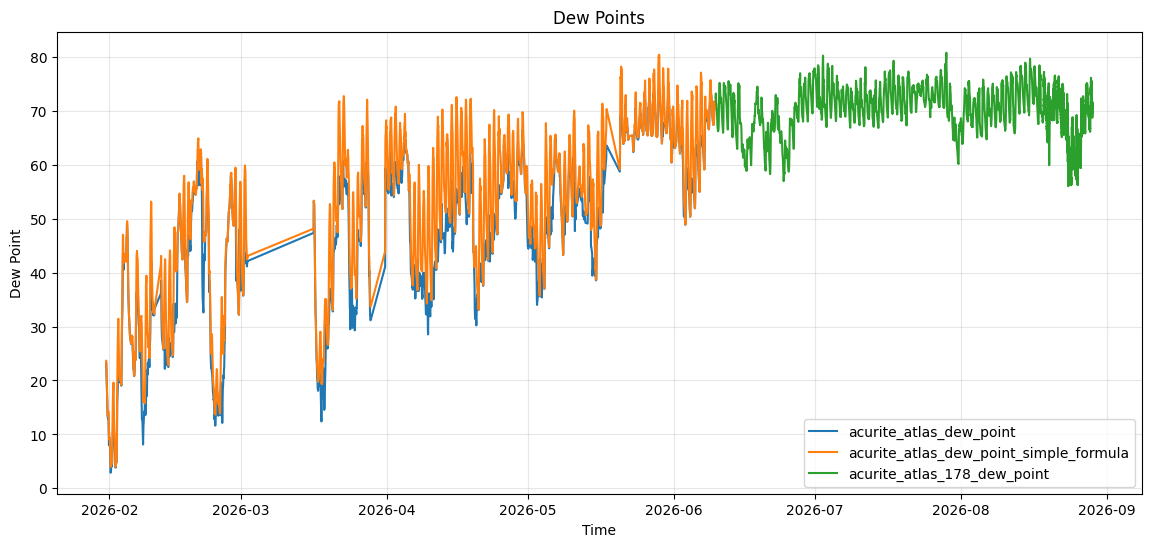

In [221]:
dew_calc_cols = [
    "sensor.acurite_atlas_dew_point",
    "sensor.acurite_atlas_dew_point_simple_formula",
    "sensor.acurite_atlas_178_dew_point"
]

plt.figure(figsize=(14, 6))

for col in dew_calc_cols:
    # make a copy of not null data in each col, 
    data = df.loc[
        df[col].notna(),
        ["last_changed", col]
    ].copy()
    # datetime conversion of last_changed
    data["last_changed"] = pd.to_datetime(
        data["last_changed"],
        errors="coerce",
        utc=True
    )
    # for col referenced in iterator, convert col to numeric
    data[col] = pd.to_numeric(data[col], errors="coerce")
    data = data.dropna(subset=["last_changed", col])
    # plot (timestamp, col) and strip sensor. prefix in the label
    plt.plot(
        data["last_changed"],
        data[col],
        label=col.replace("sensor.", "")
    )

plt.xlabel("Time")
plt.ylabel("Dew Point")
plt.title("Dew Points")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

We can see that `acurite_atlas_178_dew_point` takes over, but the other two seemingly vanish.

To further investigate, we can inspect the crossover in isolation:

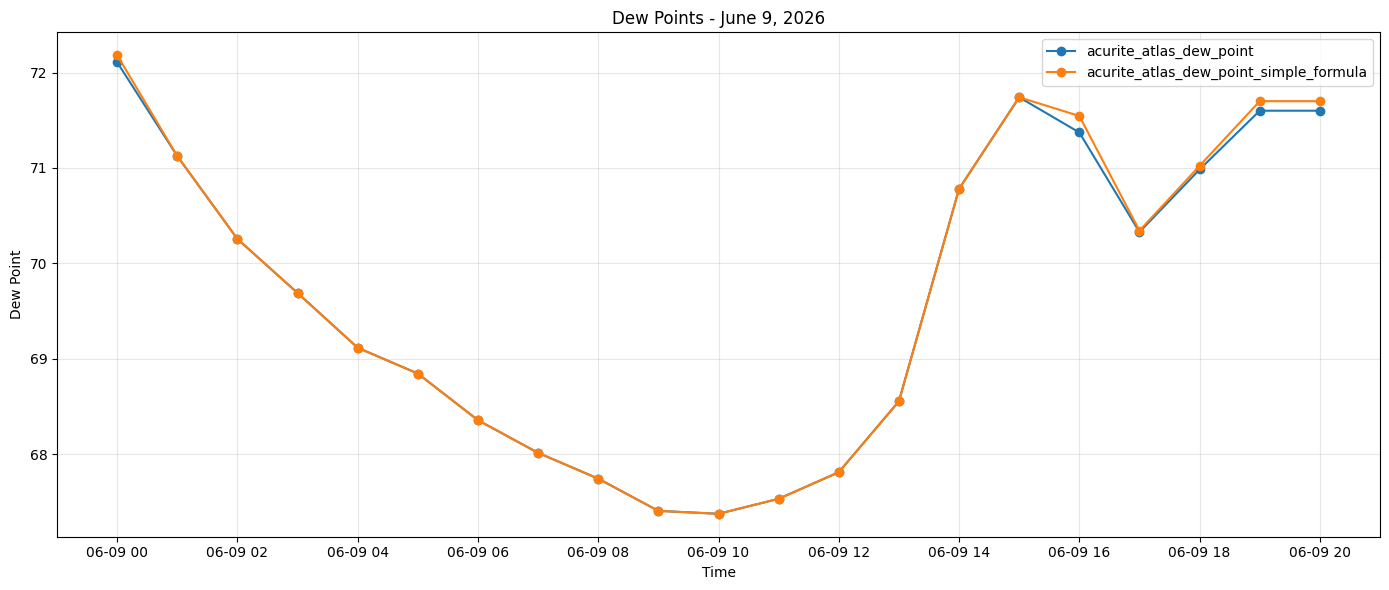

In [222]:
dew_calc_cols = [
    "sensor.acurite_atlas_dew_point",
    "sensor.acurite_atlas_dew_point_simple_formula"
]

plt.figure(figsize=(14, 6))

for col in dew_calc_cols:
    data = df.loc[
        df[col].notna(),
        ["last_changed", col]
    ].copy()

    data["last_changed"] = pd.to_datetime(
        data["last_changed"],
        errors="coerce",
        utc=True
    )
    data[col] = pd.to_numeric(data[col], errors="coerce")

    # Keep only June 9, 2026
    data = data[
        (data["last_changed"] >= "2026-06-09") &
        (data["last_changed"] < "2026-06-10")
    ]

    data = (
        data
        .dropna(subset=["last_changed", col])
        .sort_values("last_changed")
    )

    plt.plot(
        data["last_changed"],
        data[col],
        marker="o",
        label=col.replace("sensor.", "")
    )

plt.xlabel("Time")
plt.ylabel("Dew Point")
plt.title("Dew Points - June 9, 2026")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

As you can see, these two follow eachother closely. They appear to cease reporting on 06/09/26 at around 08:00 PM. This is likely due to some kind of software discontinuity, such as an update, migration, or other mechanism that caused the change in sensor representation.

To view this hand-off with more precision, we can view the record in a dataframe:

In [223]:
dew_cols = [
    "sensor.acurite_atlas_dew_point",
    "sensor.acurite_atlas_dew_point_simple_formula",
    "sensor.acurite_atlas_178_dew_point"
]

june9 = df.loc[
    pd.to_datetime(df["last_changed"]).dt.date ==
    pd.Timestamp("2026-06-09").date(),
    ["last_changed"] + dew_cols
].copy()

for col in dew_cols:
    june9[col] = pd.to_numeric(june9[col], errors="coerce")

june9.dropna(how="all", subset=dew_cols)

entity_id,last_changed,sensor.acurite_atlas_dew_point,sensor.acurite_atlas_dew_point_simple_formula,sensor.acurite_atlas_178_dew_point
2489,2026-06-09T00:00:00.000Z,72.107829,72.181021,NaN
2490,2026-06-09T01:00:00.000Z,71.124381,71.124381,NaN
2491,2026-06-09T02:00:00.000Z,70.255906,70.255906,NaN
2492,2026-06-09T03:00:00.000Z,69.689924,69.689924,NaN
2493,2026-06-09T04:00:00.000Z,69.115955,69.115955,NaN
2494,2026-06-09T05:00:00.000Z,68.845790,68.845790,NaN
2495,2026-06-09T06:00:00.000Z,68.356978,68.356978,NaN
2496,2026-06-09T07:00:00.000Z,68.014869,68.014869,NaN
2497,2026-06-09T08:00:00.000Z,67.744584,67.744584,NaN
2498,2026-06-09T09:00:00.000Z,67.407010,67.407010,NaN


It appears that the first two columns cease at an instant around 08:00 PM. For one row, all 3 columns report a value -- the problem is that they all report different values. Because the sample rate is 1 hour, there's ample opportunity for dew point to raise slightly in an hour from either one of the original values to the new value at the crossover point. So unfortunately, we can't determine which formula is used based on the instantaneous records solely.

But it does beg the question -- **why did this occur?** What data do we have going back to January, and what data do we have that starts in June?

In [224]:
atlas_cols = [
    col for col in df.columns
    if "acurite_atlas" in col.lower()
]

coverage = []

for col in atlas_cols:
    valid = df.loc[df[col].notna(), ["last_changed", col]].copy()
    valid["last_changed"] = pd.to_datetime(valid["last_changed"])

    coverage.append({
        "column": col,
        "count": len(valid),
        "unique": valid[col].nunique(),
        "first": valid["last_changed"].min(),
        "last": valid["last_changed"].max()
    })

atlas_coverage = (
    pd.DataFrame(coverage)
    .sort_values("first")
    .reset_index(drop=True)
)

atlas_coverage

,column,count,unique,first,last
0,sensor.acurite_atlas_dew_point,2511,2482,2026-01-31 08:00:00+00:00,2026-08-26 01:16:34.237000+00:00
1,sensor.acurite_atlas_dew_point_simple_formula,2511,2482,2026-01-31 08:00:00+00:00,2026-08-26 01:16:34.238000+00:00
2,sensor.acurite_atlas_178_dew_point,19486,1879,2026-06-09 20:00:00+00:00,2026-08-28 23:58:45.879000+00:00
3,sensor.acurite_atlas_178_humidity,7735,1084,2026-06-09 20:00:00+00:00,2026-08-28 23:56:15.870000+00:00
4,sensor.acurite_atlas_178_light_level,17657,5731,2026-06-09 20:00:00+00:00,2026-08-28 23:58:45.890000+00:00
5,sensor.acurite_atlas_178_rain_total,215,135,2026-06-09 20:00:00+00:00,2026-08-27 18:19:12.965000+00:00
6,sensor.acurite_atlas_178_temperature,17014,2048,2026-06-09 20:00:00+00:00,2026-08-28 23:58:45.884000+00:00
7,sensor.acurite_atlas_178_wind_direction,21720,2028,2026-06-09 20:00:00+00:00,2026-08-28 23:58:15.878000+00:00
8,sensor.acurite_atlas_178_wind_speed,9155,1040,2026-06-09 20:00:00+00:00,2026-08-28 22:53:45.302000+00:00
9,sensor.acurite_atlas_178_signal_rssi,24914,135,2026-08-18 08:12:19.399000+00:00,2026-08-28 23:58:45.887000+00:00


As you can see, the first two columns are the only ones that go back to 01/31/2026. Most importantly, **we can't produce any other Acurite data that goes back that far.** Even if we could successfully identify which formula matches our current dew point entity, **we wouldn't be able to produce complete records reaching back that far**. Imputation would be impossible. As a result, we will drop those two columns, leaving the mystery behind as a cold case.

In [225]:
columns_to_drop = [
    "sensor.acurite_atlas_dew_point",
    "sensor.acurite_atlas_dew_point_simple_formula",
]

df = df.drop(columns=columns_to_drop)

#### Atlas RF Quality
We sought to include Atlas RF quality signals (RSSI, SNR, Noise Floor) in our training. It is a unique space that sits between the physical world and the diagnostic world. But as we just saw while investigating dew point, we have some staggered data collection ranges, presumably due to Home Assistant migrations. Among those entities with staggered collection periods were RSSI, SNR, and Noise Floor.

As you can see below, RSSI, SNR, and Noise Floor (rows 9, 10, and 11) begin on 08-18-2026. It appears that the bulk of our data starts around 06-09-2026.

Since we can't reasonably impute over two months of signal quality data, we're forced to leave these columns behind as well. It's a shame, but it may be best for the project's scope. Without a reasonable alternative, we are left with no choice.

In [226]:
atlas_coverage

,column,count,unique,first,last
0,sensor.acurite_atlas_dew_point,2511,2482,2026-01-31 08:00:00+00:00,2026-08-26 01:16:34.237000+00:00
1,sensor.acurite_atlas_dew_point_simple_formula,2511,2482,2026-01-31 08:00:00+00:00,2026-08-26 01:16:34.238000+00:00
2,sensor.acurite_atlas_178_dew_point,19486,1879,2026-06-09 20:00:00+00:00,2026-08-28 23:58:45.879000+00:00
3,sensor.acurite_atlas_178_humidity,7735,1084,2026-06-09 20:00:00+00:00,2026-08-28 23:56:15.870000+00:00
4,sensor.acurite_atlas_178_light_level,17657,5731,2026-06-09 20:00:00+00:00,2026-08-28 23:58:45.890000+00:00
5,sensor.acurite_atlas_178_rain_total,215,135,2026-06-09 20:00:00+00:00,2026-08-27 18:19:12.965000+00:00
6,sensor.acurite_atlas_178_temperature,17014,2048,2026-06-09 20:00:00+00:00,2026-08-28 23:58:45.884000+00:00
7,sensor.acurite_atlas_178_wind_direction,21720,2028,2026-06-09 20:00:00+00:00,2026-08-28 23:58:15.878000+00:00
8,sensor.acurite_atlas_178_wind_speed,9155,1040,2026-06-09 20:00:00+00:00,2026-08-28 22:53:45.302000+00:00
9,sensor.acurite_atlas_178_signal_rssi,24914,135,2026-08-18 08:12:19.399000+00:00,2026-08-28 23:58:45.887000+00:00


In [227]:
columns_to_drop = [
    "sensor.acurite_atlas_178_signal_rssi",
    "sensor.acurite_atlas_178_signal_snr",
    "sensor.acurite_atlas_178_noise_floor"
]

df = df.drop(columns=columns_to_drop)

#### Lux/Light/UV
As with RF Quality and Dew Point, we have some lux/light/UV-related columns that have incomplete range. `sensor.acurite_atlas_178_uv_index` also begins on 08/18/2026, somehow losing over two months of telemetry for the sensor. We will explore this column -- along with `sensor.acurite_atlas_178_light_level` -- to see if we can reconstruct meaningful solar data.

In [228]:
atlas_coverage

,column,count,unique,first,last
0,sensor.acurite_atlas_dew_point,2511,2482,2026-01-31 08:00:00+00:00,2026-08-26 01:16:34.237000+00:00
1,sensor.acurite_atlas_dew_point_simple_formula,2511,2482,2026-01-31 08:00:00+00:00,2026-08-26 01:16:34.238000+00:00
2,sensor.acurite_atlas_178_dew_point,19486,1879,2026-06-09 20:00:00+00:00,2026-08-28 23:58:45.879000+00:00
3,sensor.acurite_atlas_178_humidity,7735,1084,2026-06-09 20:00:00+00:00,2026-08-28 23:56:15.870000+00:00
4,sensor.acurite_atlas_178_light_level,17657,5731,2026-06-09 20:00:00+00:00,2026-08-28 23:58:45.890000+00:00
5,sensor.acurite_atlas_178_rain_total,215,135,2026-06-09 20:00:00+00:00,2026-08-27 18:19:12.965000+00:00
6,sensor.acurite_atlas_178_temperature,17014,2048,2026-06-09 20:00:00+00:00,2026-08-28 23:58:45.884000+00:00
7,sensor.acurite_atlas_178_wind_direction,21720,2028,2026-06-09 20:00:00+00:00,2026-08-28 23:58:15.878000+00:00
8,sensor.acurite_atlas_178_wind_speed,9155,1040,2026-06-09 20:00:00+00:00,2026-08-28 22:53:45.302000+00:00
9,sensor.acurite_atlas_178_signal_rssi,24914,135,2026-08-18 08:12:19.399000+00:00,2026-08-28 23:58:45.887000+00:00


To explore this, we'll graph our two available solar columns. We'll convert `last_changed` to datetime, and the solar columns to numeric datatypes.

For this experiment, we'll use `.ffill()` to smooth the gaps -- it's purely for interpretation, and not a permanent assessment that this is a long-term interpolation strategy for every gap in the data.

Next, we'll scale the solar columns and plot the resulting smoothed-over data. For contrast, I've set the start date of the x-axis to be four days prior to the moment that `sensor.acurite_atlas_178_uv_index` begins reporting data.


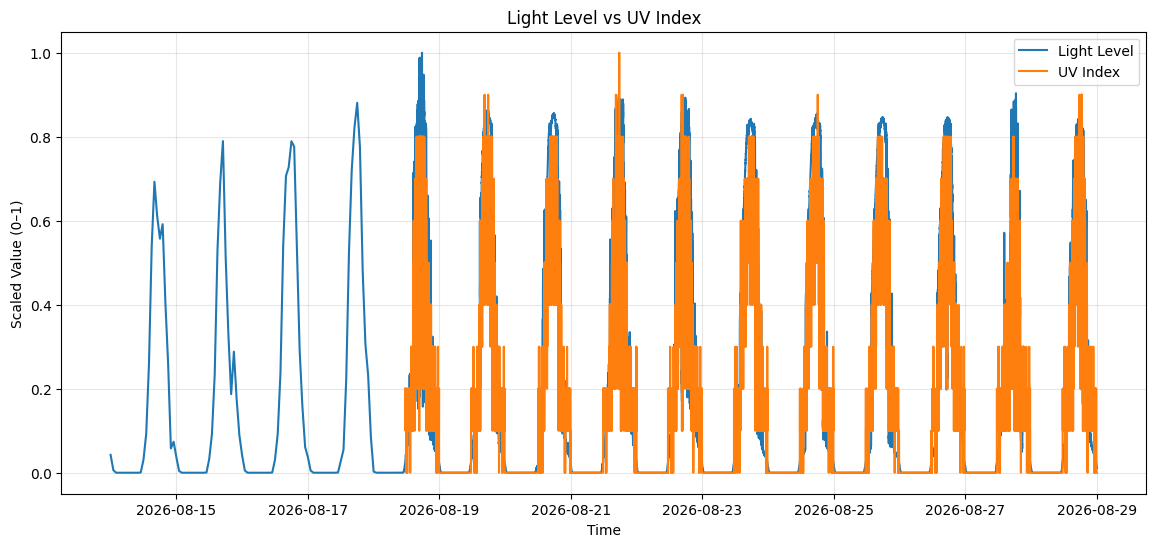

In [229]:
light_col = "sensor.acurite_atlas_178_light_level"
uv_col = "sensor.acurite_atlas_178_uv_index"

light_uv = df[["last_changed", light_col, uv_col]].copy()

light_uv["last_changed"] = pd.to_datetime(light_uv["last_changed"])
light_uv[light_col] = pd.to_numeric(light_uv[light_col], errors="coerce")
light_uv[uv_col] = pd.to_numeric(light_uv[uv_col], errors="coerce")

light_uv[[light_col, uv_col]] = light_uv[[light_col, uv_col]].ffill()

light_uv = light_uv[
    light_uv["last_changed"] >= "2026-08-14"
].copy()

for col in [light_col, uv_col]:
    light_uv[col + "_scaled"] = (
        (light_uv[col] - light_uv[col].min()) /
        (light_uv[col].max() - light_uv[col].min())
    )

plt.figure(figsize=(14, 6))

plt.plot(
    light_uv["last_changed"],
    light_uv[light_col + "_scaled"],
    label="Light Level"
)

plt.plot(
    light_uv["last_changed"],
    light_uv[uv_col + "_scaled"],
    label="UV Index"
)

plt.xlabel("Time")
plt.ylabel("Scaled Value (0–1)")
plt.title("Light Level vs UV Index")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

As you can see, UV index appears to behave as a discrete, quantized correlate of light level, resulting in a compressed, square wave-like embodiment of light level's more continuous curve. Fortunately, light level appears to have much greater instantaneous resolution than UV index. UV index appears to undershoot or overshoot light level's daily peak at times, and the boxy transcription over the smooth curve shows that some changes in light intensity result in rougher approximations, especially towards the evening.

In [230]:
columns_to_drop = [
    "sensor.acurite_atlas_178_uv_index"
]

df = df.drop(columns=columns_to_drop)

#### Storm
Similar to RF quality and UV index, it appears that we may have had a delayed reporting for the storm/strike columns. There is a small difference -- these two columns first reported on 08/21/2026, while the others first reported on 08/18/2026. Could there be a chance that we merely had a period of low storm activity? We will investigate them to determine whether we had delayed reporting, or good summer weather.

We'll follow the same playbook of converting our columns to their respective datatypes and plotting the data. We'll use a scatter plot to see the actual sample rate, since smoothing discrete counter mechanisms can make the data appear more granular than it is.

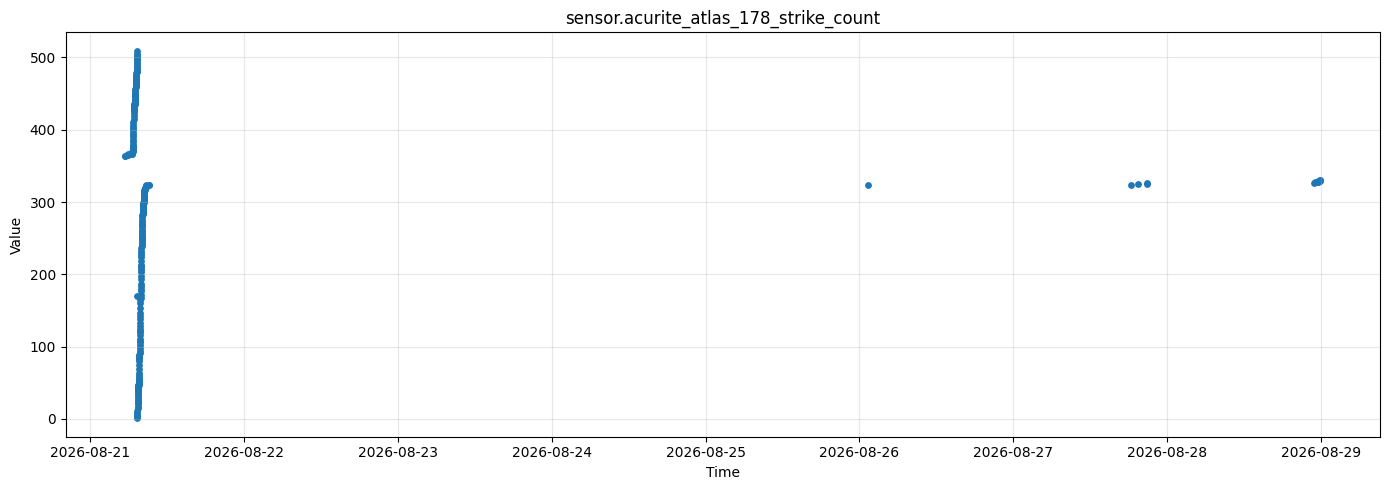

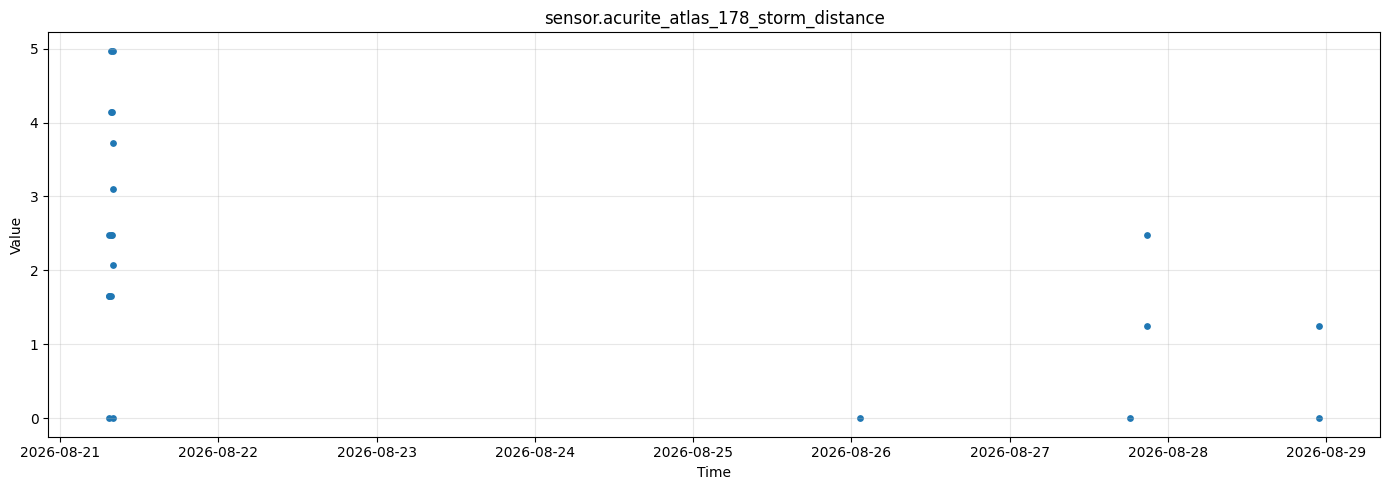

In [231]:
lightning_cols = [
    "sensor.acurite_atlas_178_strike_count",
    "sensor.acurite_atlas_178_storm_distance"
]

for col in lightning_cols:
    data = df.loc[df[col].notna(), ["last_changed", col]].copy()
    data["last_changed"] = pd.to_datetime(data["last_changed"])
    data[col] = pd.to_numeric(data[col], errors="coerce")

    plt.figure(figsize=(14, 5))

    plt.scatter(
        data["last_changed"],
        data[col],
        s=15
    )

    plt.title(col)
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

As you can see, we have a very odd phenomenon that occurs on 08/21, where the strike count rapidly increases, resets, and increases back to nearly its original position. This also causes the storm distance to fluctuate between 0 and 5 miles. After this brief event, we have no storm data until 08/26, a cluster of three points on the evening of 08/27, and two points on the evening of 08/28. 

It would be an environmental phenomenon for the count to go from approx. 375 to over 500 strikes, reset, and immediately increase to nearly 350 again within the same morning. That certainly deserves scrutiny, especially when it's the first data reported in a given period. It almost appears as if the counter reset, but the rapid re-ascention that halts below the original value raises suspicion. 

The data can be directly observed by isolating the moment in the dataset and observing the logs.

In [232]:
strike_col = "sensor.acurite_atlas_178_strike_count"

# copy timestamp and strike column from df
strike_aug21 = df.loc[
    df[strike_col].notna(),
    ["last_changed", strike_col]
].copy()

# convert the timestamp to datetime dtype
strike_aug21["last_changed"] = pd.to_datetime(
    strike_aug21["last_changed"]
)

# convert strike col to numeric w/ type coersion
strike_aug21[strike_col] = pd.to_numeric(
    strike_aug21[strike_col],
    errors="coerce"
)

# finally, filter the timestamp to the moment isolated. 
strike_aug21 = strike_aug21[
    (strike_aug21["last_changed"] >= "2026-08-21 07:18") &
    (strike_aug21["last_changed"] < "2026-08-22")
].copy()

# for space
strike_aug21.head(20)

entity_id,last_changed,sensor.acurite_atlas_178_strike_count
75591,2026-08-21 07:18:26.055000+00:00,500.00
75604,2026-08-21 07:18:56.060000+00:00,502.00
75610,2026-08-21 07:19:26.063000+00:00,504.67
75618,2026-08-21 07:19:56.064000+00:00,509.33
75624,2026-08-21 07:20:26.076000+00:00,170.33
75633,2026-08-21 07:20:56.076000+00:00,0.67
75640,2026-08-21 07:21:26.121000+00:00,3.50
75646,2026-08-21 07:21:56.083000+00:00,5.00
75655,2026-08-21 07:22:26.123000+00:00,7.67
75661,2026-08-21 07:22:56.088000+00:00,11.33


As you can see, we've isolated the moment that the strike counter peaked, reset, and began its re-ascent.

Interestingly, here's what we can see:
- The reset wasn't instantaneous. The strike counter transitioned from 509.33 > 170.33 > 0.67 > 3.50. Rather than moving directly from its peak to a near-zero reset value, an intermediate value occurred during the transition.
- The reported values aren't discrete integers. Values frequently end in .00, .33, .67, and .50, suggesting that the strike count is not returned as a literal count of lightning strikes. These fractional values may result from unintended/intended averaging, protocol standard that requires conversion, or another transformation somewhere in the data pipeline.
- The initial event has unusually high-density sampling, mixed with illogical increment/decrement trends. This could represent a sensor/hardware error, or even temporary malfunction/damage from a storm (if lightning truly triggered the event). 

This is not what we'd expect to see. Non-discrete transitions and fractional values are not represented in the manufacturer dashboard. This likely means that either the manufacturer dashboard performs a conversion/truncation, the hardware was possibly damaged/overwhelmed, or the data is being altered as it travels through the pipeline. The data originates from an AcuRite Atlas RF weather station, is then received using a USB RTL-SDR receiver, decoded by `rtl_433` using a reverse-engineered manufacturer protocol, and ultimately exposed through Home Assistant. As such, there are many points where unintended manipulation may occur.

At any rate, the strike-count feature -- being of discrete nature -- can not have its data interpreted literally as the data itself is fractional. If there is some kind of synchronized reset coordination that occurs between the weather station and the original dashboard, our side is not participating in the mandated protocol. Given the ambiguity around the data's temporal totality, its fractionality, and its cumulative behavior, we will drop both columns at this time. We cannot ensure the integrity of this data, and any attempt to impute values or assume completion would be taking undue liberty.

In [233]:
columns_to_drop = [
    "sensor.acurite_atlas_178_strike_count",
    "sensor.acurite_atlas_178_storm_distance"
]
df = df.drop(columns=columns_to_drop)

#### WH51 RF Quality
Next, we will investigate and determine the best, if any, representation of RF quality that we can use for the WH51 Fineoffset soil moisture sensor. 

To begin, we will assign our relevant WH51 RF signal columns to a list. We'll also include the actual soil moisture sensor to see if we identify any trends.
We'll `.copy()` our columns, along with our index column, to a new dataframe labeled `rf`.

In [234]:
rf_cols = [
    "sensor.fineoffset_wh51_0f8613_noise_floor",
    "sensor.fineoffset_wh51_0f8613_signal_rssi",
    "sensor.fineoffset_wh51_0f8613_signal_snr",
    "sensor.fineoffset_wh51_0f8613_soil_moisture"
]

rf = df[["last_changed"] + rf_cols].copy()


Next, we'll convert `last_changed` to the datetime datatype and iterate through each column, coercing their values as numeric.

We'll then scale our new dataframe inputs using the `min()` and `max()` functions on each column iteratively.

In [235]:

rf["last_changed"] = pd.to_datetime(
    rf["last_changed"],
    errors="coerce"
)

for col in rf_cols:
    rf[col] = pd.to_numeric(
        rf[col],
        errors="coerce"
    )

rf_scaled = rf.copy()

for col in rf_cols:
    rf_scaled[col] = (
        rf_scaled[col] - rf_scaled[col].min()
    ) / (
        rf_scaled[col].max() - rf_scaled[col].min()
    )


Next, we'll set our plot, drop our null values, adjust our x-axis to the applicable time frame, plot our data, and label our graph.

**Note: 08/18 is the applicable starting point based on the data available.**

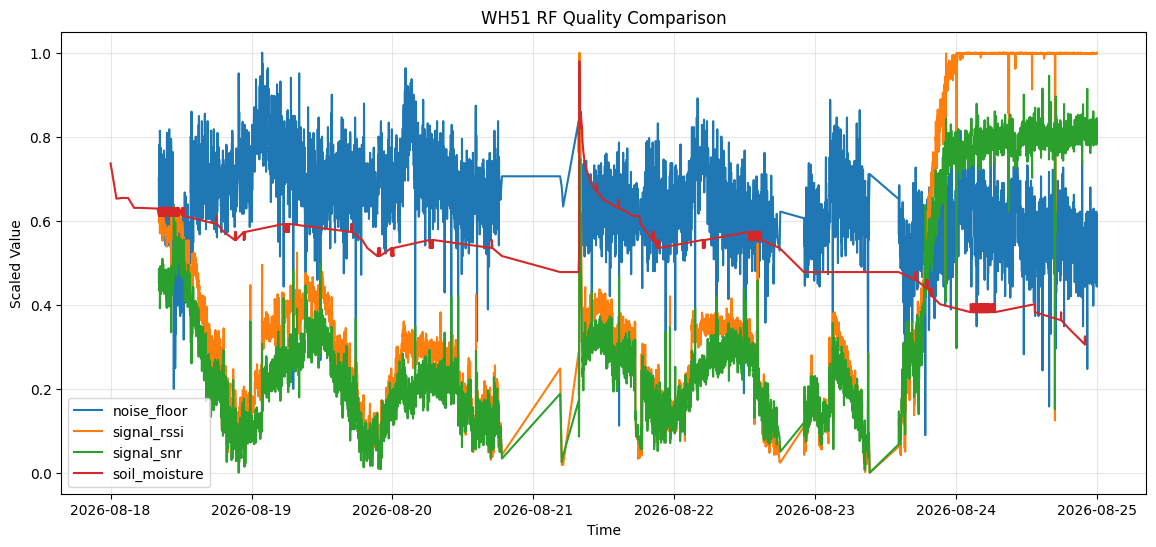

In [236]:
plt.figure(figsize=(14, 6))

for col in rf_cols:
    data = rf_scaled.dropna(subset=[col])
    data = data[
        (data["last_changed"] >= "2026-08-18") &
        (data["last_changed"] < "2026-08-25")
    ]

    plt.plot(
        data["last_changed"],
        data[col],
        label=col.replace("sensor.fineoffset_wh51_0f8613_", "")
    )

plt.xlabel("Time")
plt.ylabel("Scaled Value")
plt.title("WH51 RF Quality Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

As you can see, RF quality data does show an interesting trend. 

**As a reminder, we scaled our inputs for this graph. The y-axis placement of a feature at any given point is most appropriately compared to its own performance; not the relative placement of another feature.**

With that in mind, a few events stand out.

- **There were minor disruptions on turn of the day 08/21, late night 08/22, and mid-day 08/23.** This could be caused by power outages, Home Assistant freezes, driver crashes, antenna issues, logging/persistence issues, and more. 
- **Late evening 08/23, something major shifted that improved the signal quality.** The noise floor seemed to sit lower on average than it previously did, while the RSSI dramatically increased and held much more consistently. Not only did the variance/jitter greatly decrease, but it held steady at its maximum. This suggests that a major contributor of interference was removed, likely a physical obstacle or massive contributor of interference. Either way, this caused the SNR to greatly increase as a result of the improved positioning.

Because the noise floor tends to hover around 0.5 in this sample, and we have data showing RSSI on both extremes of the scale, we have the opportunity to observe the behavior of SNR in key situations. With the noise floor around the mid-range, SNR tends to align closely with signal on the lower end of the scale (0-0.5), yet hover between noise and signal when signal is on the high end of the spectrum (0.5-1.0). This suggests that SNR may be more sensitive to weak signal, as their trends stay tightly coupled on the low end of the scale. However, when signal is on the high end of the scale -- consistently holding steady at the max range -- SNR hovers around 0.8, being clearly restrained by the gravity of the noise floor. While the mathematical relationship of signal:noise seems simple, this graph allows us to view the real-world implications in metric behavior. The logarithmic behavior is precisely the kind of representation that we'd like when representing RF quality -- it weighs diminishing returns, is heavily influenced by weak signal, and is derived of both values.

Nevertheless, these values only go back to 08/18, leaving soil moisture sensor RF quality to be **another candidate that we must reject due to the limited time range available in the dataset**.

But before we drop those columns, we can investigate the minor signal disruptions/outages we mentioned above. This is critical as it may indicate outages/data gaps that -- in timeseries prediction -- could greatly hinder the model's ability to learn relationships over a contiguous period, with little that could be done in terms of imputation.

We observed three segments that had distinctly flat trends for a period of time. Our plot is forming a line between each point, so theoretical sponteneous stagnation could look identical to an outage. To eliminate spontaneous real-world stagnation in a noisy environment (e.g., a glitch in the universe simulation), it is best to use a scatter plot to observe where each real reported datapoint lies.

To rule out a Home Assistant/power/RF antenna/other layer outage, we will add an AcuRite weather station value as well. Because it also transmits on RF 433 MHz, it will help us determine whether everything stopped logging data, or just WH51 Fineoffset sensor-related data. I've also removed the noise floor column for better visibility.

In [237]:
rf_cols = [
    "sensor.fineoffset_wh51_0f8613_signal_rssi",
    "sensor.fineoffset_wh51_0f8613_signal_snr",
    "sensor.acurite_atlas_178_temperature",
    "sensor.fineoffset_wh51_0f8613_soil_moisture"
]

rf_scaled = df[["last_changed"] + rf_cols].copy()
rf_scaled["last_changed"] = pd.to_datetime(rf_scaled["last_changed"])

for col in rf_cols:
    rf_scaled[col] = pd.to_numeric(rf_scaled[col], errors="coerce")
    rf_scaled[col] = (
        (rf_scaled[col] - rf_scaled[col].min()) /
        (rf_scaled[col].max() - rf_scaled[col].min())
    )

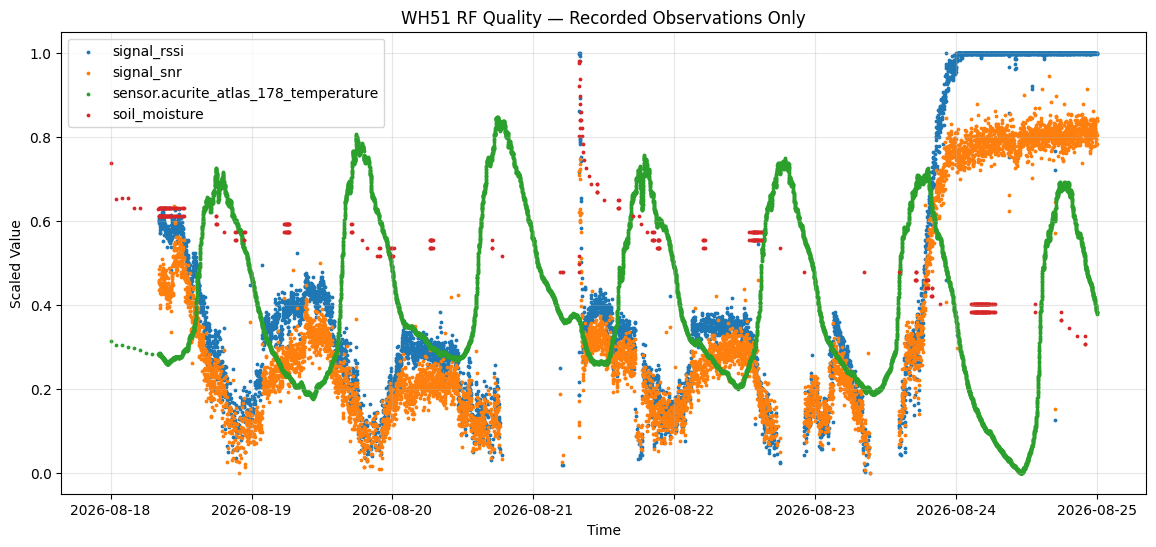

In [238]:
plt.figure(figsize=(14, 6))
rf_cols = [
    "sensor.fineoffset_wh51_0f8613_signal_rssi",
    "sensor.fineoffset_wh51_0f8613_signal_snr",
    "sensor.acurite_atlas_178_temperature",
    "sensor.fineoffset_wh51_0f8613_soil_moisture"
]
for col in rf_cols:
    data = rf_scaled.dropna(subset=[col])

    data = data[
        (data["last_changed"] >= "2026-08-18") &
        (data["last_changed"] < "2026-08-25")
    ]
    

    plt.scatter(
        data["last_changed"],
        data[col],
        s=3,
        label=col.replace("sensor.fineoffset_wh51_0f8613_", "")
    )

plt.xlabel("Time")
plt.ylabel("Scaled Value")
plt.title("WH51 RF Quality — Recorded Observations Only")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

As you can see, RSSI and SNR (blue and orange, respectively) outline the gaps well -- there's no question of some obstruction causing reporting dropouts. Interestingly, the AcuRite temperature sensor (green) continued to provide updated values during the outages in high-resolution. As a result, **the obstruction appears to be related to the WH51 soil moisture sensor communicating with the known-active RTL-SDR antenna + Home Assistant stack.** Regarding the WH51 soil moisture sensor obstruction, physical interference, hardware damage, operating conditions, or power disruptions could be to blame. But since we've already determined that we will not use WH51 RF quality features, trying to impute erratic RF data is not a concern. 

In fact, it appears that RF quality metrics report frequently. Soil moisture (red), on the other hand, appears to report less frequently at times. In fact, the largest break in reporting RF quality doesn't even appear to be the largest break in reporting soil moisture. Once RF reporting resumed, there was a large spike in soil moisture value. Then, soil moisture descended while updating the value more frequently. It may be the case that soil moisture reporting has an efficiency component, where long durations without a value change result in less frequent reporting.

In conclusion, soil moisture reporting itself tends to be intermittent, with spurts of high-resolution posting -- especially during periods of reported moisture change -- and periods of stagnation, though later data points seem to show little to no change in soil moisture. Therefore, during imputation, we must recognize that periodicity itself is not a meaningful indicator of soil moisture status, and that considerable periods of silence may mean that there is simply no change at all.

We have noted to investigate sensor resolution and dropout in future exploration.

In [239]:
columns_to_drop = [
    "sensor.fineoffset_wh51_0f8613_signal_rssi",
    "sensor.fineoffset_wh51_0f8613_signal_snr",
    "sensor.fineoffset_wh51_0f8613_noise_floor"
]

df = df.drop(columns=columns_to_drop)

#### Soil Moisture (Target Variable)
Next, we have our target variable -- soil moisture. We have `sensor.fineoffset_wh51_0f8613_ad_raw` and `sensor.fineoffset_wh51_0f8613_soil_moisture`, where one is the moisture value returned as a percent, and the other is the raw sensor value. We can compare our two columns and see which one is the best candidate for the target variable. We may consider aspects such as completeness of time range and data resolution. We may consider the construction of a combination of both columns if sensible.

First, we will copy our columns of interest and index, then convert them to their respective datatypes.

We will scale each feature as one is represented as a percent, and the other is represented in hundreds (unit unknown).

Finally, we'll drop the `NaN`-type values and plot the target candidates on a scatter plot.

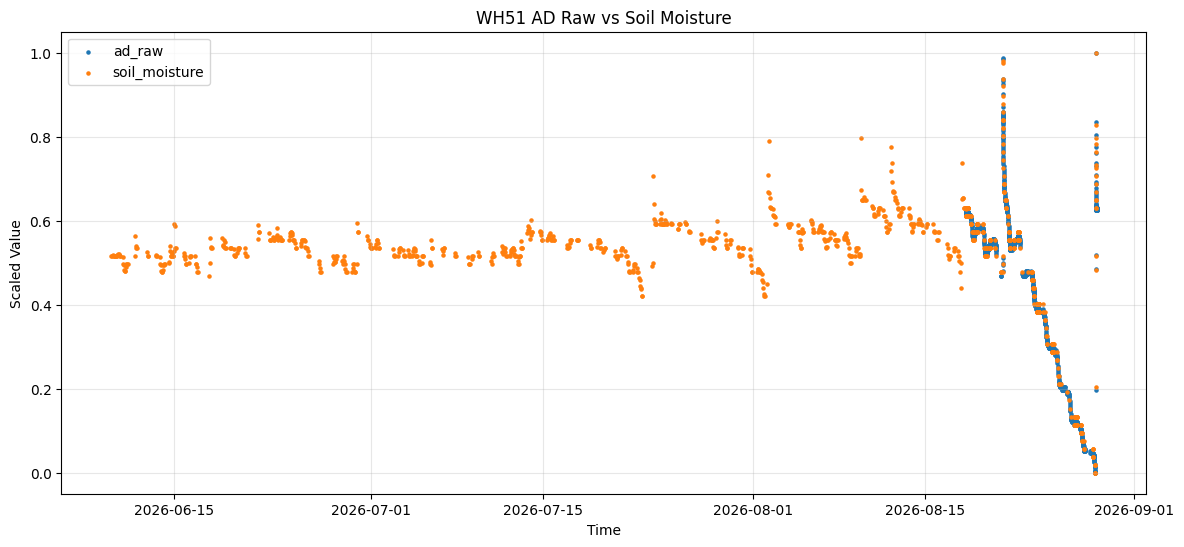

In [240]:
cols = [
    "sensor.fineoffset_wh51_0f8613_ad_raw",
    "sensor.fineoffset_wh51_0f8613_soil_moisture"
]

soil_compare = df[["last_changed"] + cols].copy()
soil_compare["last_changed"] = pd.to_datetime(soil_compare["last_changed"])

for col in cols:
    soil_compare[col] = pd.to_numeric(
        soil_compare[col],
        errors="coerce"
    )

scaled = soil_compare.copy()

for col in cols:
    scaled[col] = (
        scaled[col] - scaled[col].min()
    ) / (
        scaled[col].max() - scaled[col].min()
    )

plt.figure(figsize=(14, 6))

for col in cols:
    data = scaled.dropna(subset=[col])

    plt.scatter(
        data["last_changed"],
        data[col],
        s=5,
        label=col.replace("sensor.fineoffset_wh51_0f8613_", "")
    )

plt.xlabel("Time")
plt.ylabel("Scaled Value")
plt.title("WH51 AD Raw vs Soil Moisture")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

As you can see, we thankfully have data spanning back to 06/09 for the percentage representation of our target variable. If this weren't the case, this project would be under serious existential pressure. Fortunately, we do have resolute and contiguous target data. No major sampling gaps are visible, no unusual variance is present, and expected patterns of soil moisture are present -- relative equilibrium, decay, periodic spikes (rain, watering) with downward gravity, and no extreme, isolated data points.

There are two notable major points:
- **Watering events are present. We have rainfall data, but no data logged for manual watering.** The model can only learn from the data we train it with. If a major source of change is virtually undocumented, we cannot reasonably expect the model to predict what it cannot see. 
- **Aside from watering events, the soil moisture appears to hover around an equilibrium.** This is considerable as it may suggest that aside from external factors (watering, rainfall), the environment may have surprisingly little bearing on soil moisture. However, we must consider that the inputs are scaled as well. Scaling the values can make them appear more vertically dramatic than they are. If the undisturbed soil moisture appears to have a modest change while scaled, a natural scaling would make those changes appear even more modest.
- **Cyclical trends appear present in the data.** Throughout June and July, soil moisture stayed relatively stable. As mid-July arrived, a cycle of surges and purges became present, getting more intense each cycle. In fact, just before mid-August, it appeared that there was an additional cycle falling between the natural cycle, and possibly another one following it. Fortunately, the later weeks gave us behavioral data in more extreme ends of the soil moisture spectrum. Just before September, we can see the rhythmic decline in soil moisture, likely coinciding with day/night cycles. 
- **`ad_raw`'s natural, unrounded value is slightly off from the percent representation.** This is to be expected. At times, the raw value is slightly higher than the percentage. At times, it is slightly lower. We had considered merging datasets if it were sensible. But in this case, even if `ad_raw` offered higher data resolution, it would not be a wise decision to merge the columns. Scientific sensors are uniquely calibrated. Introducing new levels of resolution or precision in a portion of the dataset introduces temporal bias to the sensor, which complicates the dataset. The raw value may have been useful if we had the entirety of the time range. Unfortunately, we do not. As a result, we will drop the raw data and keep the percentage representation as our target.

In [241]:
columns_to_drop = [
    "sensor.fineoffset_wh51_0f8613_ad_raw"
]

df = df.drop(columns=columns_to_drop)

#### Sun/Moon
Finally, we have the Sun and Moon data from Home Assistant. These are global (moon phase) or hyperlocal (sunrise time) entities that provide information regarding the Sun and Moon and their positions in the sky.

First, we'll enumerate our list of columns and add them to a scatter plot.

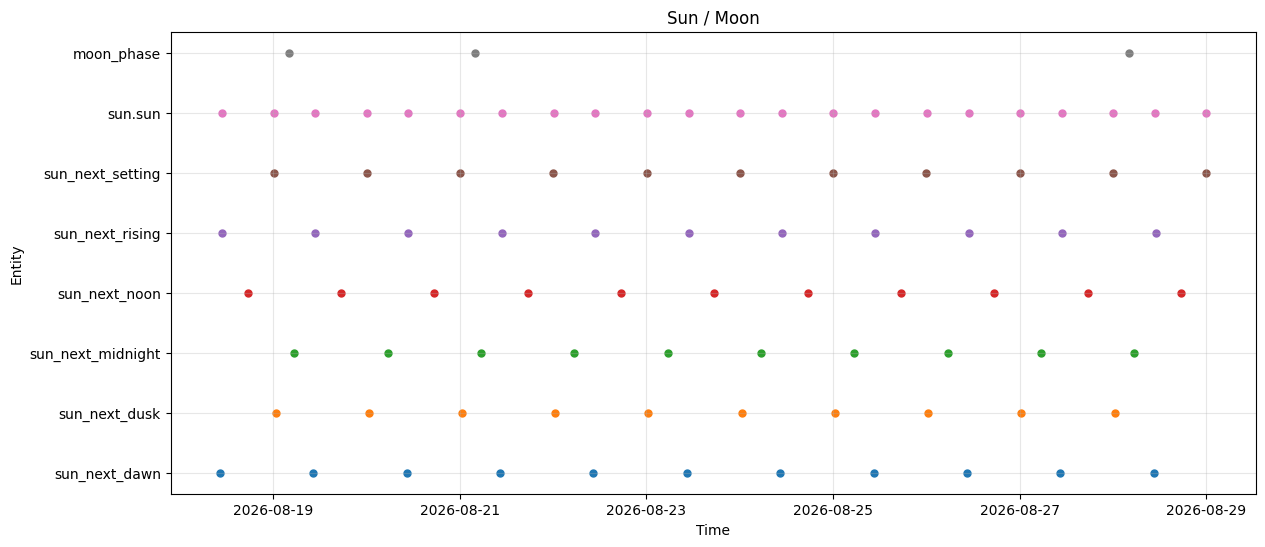

In [242]:
sun_cols = [
    "sensor.sun_next_dawn",
    "sensor.sun_next_dusk",
    "sensor.sun_next_midnight",
    "sensor.sun_next_noon",
    "sensor.sun_next_rising",
    "sensor.sun_next_setting",
    "sun.sun",
    "sensor.moon_phase"
]

plt.figure(figsize=(14, 6))

for i, col in enumerate(sun_cols):
    data = df.loc[df[col].notna(), ["last_changed"]].copy()
    data["last_changed"] = pd.to_datetime(data["last_changed"])

    plt.scatter(
        data["last_changed"],
        [i] * len(data),
        s=25,
        label=col.replace("sensor.", "")
    )

plt.yticks(
    range(len(sun_cols)),
    [col.replace("sensor.", "") for col in sun_cols]
)

plt.xlabel("Time")
plt.ylabel("Entity")
plt.title("Sun / Moon")
plt.grid(alpha=0.3)
plt.show()

The result is very geometrically pleasing. Interestingly, the Moon phase only included 3 phases in this export -- the first two being much closer together than the next two. Sadly, **this data covers exactly 10 days worth of data -- going as far forward as 08/29, two days in the future from our export time**. It appears that Home Assistant only persists a 10-day period worth of data for these entities, and it fetches the data a day or two ahead. This is a reasonable decision, and likely ensures timely scheduling for the users, and API load optimization for the servers. While we could attempt to pull historic data from other services in an attempt to construct the full time period, it is of best practice to reject the columns at this time and make a note for future development.

Our light level column provides us with a cyclical pattern of the sun. This provides extremely hyperlocal (within about 50 feet) weather information for the soil moisture sensor, which can actually offer more than simple sun position. Some days are overcast, while some are extremely sunny. UV index can fluctuate for many reasons, and our weather station captures high-resolution readings of it.

While the Moon phase was a heavily desired feature, we only have three Moon phases in this dataset. Perhaps a full dataset would have offered enough information for the model to learn relationships between the Moon phase and soil moisture (as it does affect the tide), but the data was not available during this capture. Fortunately, we've noted it for future development.

In [243]:
columns_to_drop = [
    "sensor.sun_next_dawn",
    "sensor.sun_next_dusk",
    "sensor.sun_next_midnight",
    "sensor.sun_next_noon",
    "sensor.sun_next_rising",
    "sensor.sun_next_setting",
    "sun.sun",
    "sensor.moon_phase"
]

df = df.drop(columns=columns_to_drop)

#### Final Target & Feature Selection
As a result, our dataset now looks like the following:

In [244]:
df.columns

Index(['last_changed', 'sensor.acurite_atlas_178_dew_point',
       'sensor.acurite_atlas_178_humidity',
       'sensor.acurite_atlas_178_light_level',
       'sensor.acurite_atlas_178_rain_total',
       'sensor.acurite_atlas_178_temperature',
       'sensor.acurite_atlas_178_wind_direction',
       'sensor.acurite_atlas_178_wind_speed',
       'sensor.fineoffset_wh51_0f8613_soil_moisture'],
      dtype='object', name='entity_id')

| Column | Friendly name | Description | Type |
|---|---|---|---|
| `last_changed` | Timestamp | When Home Assistant recorded a state change | Index (Timeseries) |
| `sensor.acurite_atlas_178_dew_point` | Dew point | Temperature at which airborne moisture condenses | Feature |
| `sensor.acurite_atlas_178_humidity` | Air humidity | Outdoor relative humidity | Feature |
| `sensor.acurite_atlas_178_light_level` | Light level | Measured ambient light intensity | Feature |
| `sensor.acurite_atlas_178_rain_total` | Rain total | Accumulated rainfall reported by the weather station | Feature |
| `sensor.acurite_atlas_178_temperature` | Air temperature | Outdoor temperature measured by the Atlas | Feature |
| `sensor.acurite_atlas_178_wind_direction` | Wind direction | Direction from which the wind is coming | Feature |
| `sensor.acurite_atlas_178_wind_speed` | Wind speed | Outdoor wind speed | Feature |
| `sensor.fineoffset_wh51_0f8613_soil_moisture` | Soil moisture | Ginger’s measured soil-moisture percentage | Target |

Interestingly, we've ended up with our weather station and soil moisture sensor data only. One reasonably could have expected Home Assistant's additional Sun and Moon data to be readily available. While it would have been easy to forward-fill, the lack of temporal completeness renders it a dealbreaker. RSSI, SNR, or noise floor would have also been useful; however, apparent software migrations made the data incomplete; nonetheless, brief exploration for future development was still achieved, resulting in inherently valuable foundational advancements. At the end of the day, collecting high-resolution data from multiple scientific sensors in a highly complex environment is a solid basis for experimentation.

We can observe the shape of our data as such:

In [245]:
df.shape

(279289, 9)

We have **8 features, 1 target, and 279,289 rows**. Next, we can begin cleaning, imputing, and forward-filling data so we can finally begin model development.

## Phase 3: Data Completion
Next, we will begin cleaning, imputing, and forward-filling our data.

#### Removing Empty Rows
Because Home Assistant receives and records emitted data asynchronously, each reading has its own timestamp. Many readings may have only one datapoint per timestamp. We can observe this by looking at our dataframe head:

In [246]:
df.head(10)

entity_id,last_changed,sensor.acurite_atlas_178_dew_point,sensor.acurite_atlas_178_humidity,sensor.acurite_atlas_178_light_level,sensor.acurite_atlas_178_rain_total,sensor.acurite_atlas_178_temperature,sensor.acurite_atlas_178_wind_direction,sensor.acurite_atlas_178_wind_speed,sensor.fineoffset_wh51_0f8613_soil_moisture
0,2026-01-31T08:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-01-31T09:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-01-31T10:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-01-31T11:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-01-31T12:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2026-01-31T13:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2026-01-31T14:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2026-01-31T15:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2026-01-31T16:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2026-01-31T17:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


But as you can see, we've deleted a lot of columns; many of our rows now have no data at all. We can fix this by using `dropna()` with the `how="all"` parameter, as well as the `subset=<columns>` parameter, which excludes the timestamp/index column. That is necessary as even totally "empty" rows would not be empty with the index timestamp. 

In [247]:
measurement_cols = df.columns.drop("last_changed")

df = df.dropna(
    how="all",
    subset=measurement_cols
).copy()

df.head(10)

entity_id,last_changed,sensor.acurite_atlas_178_dew_point,sensor.acurite_atlas_178_humidity,sensor.acurite_atlas_178_light_level,sensor.acurite_atlas_178_rain_total,sensor.acurite_atlas_178_temperature,sensor.acurite_atlas_178_wind_direction,sensor.acurite_atlas_178_wind_speed,sensor.fineoffset_wh51_0f8613_soil_moisture
2509,2026-06-09T20:00:00.000Z,72.29998725769919,94.01801720954722,34256.88347902266,5.08,74.09458387357961,225.71457372899403,0.9636340835535099,62
2511,2026-06-09T22:00:00.000Z,73.20266121077573,69.45206303277796,54935.41948169521,5.08,84.29136487145935,130.60975545293041,0.3928404734998188,62
2512,2026-06-09T23:00:00.000Z,72.27701964520857,81.71608962666666,9082.81394281405,NaN,78.38033354184448,335.90605877321514,0.3307290040777778,NaN
2513,2026-06-10T00:00:00.000Z,71.41023398797222,88.61121273083334,4342.566094575,NaN,75.00998157727777,0.24296304002367627,0.25687067143333336,NaN
2514,2026-06-10T01:00:00.000Z,71.30107448441667,95.81168494277779,726.0522171972221,0,72.56463298749999,1.6868041275868364,0.004167213194444444,62.15002492972223
2515,2026-06-10T02:00:00.000Z,70.72490876038889,99.502410985,1.2254881194444445,0.02,70.87418895747221,302.72172168540067,0,62.03334097388889
2516,2026-06-10T03:00:00.000Z,70.1338618208889,100,0,0.02,70.13386097658332,39.426493670293574,0,62
2517,2026-06-10T04:00:00.000Z,69.44073262597222,100,0,NaN,69.44073657108333,350.4192413277466,0.1431319383777778,62
2518,2026-06-10T05:00:00.000Z,68.30258125291667,NaN,NaN,NaN,68.30258275863889,177.61629816092082,0.3153013230777778,NaN
2519,2026-06-10T06:00:00.000Z,67.24442847152777,NaN,NaN,NaN,67.24442734994444,35.250126096197874,0.005501101741666667,62.05834372722222


#### Setting Data Resolution
Our next step it so set our data resolution/sample rate. As we observed earlier, some sensors reported with extremely high resolution, and some reported more conservatively. It should be noted that lower frequency **state change** does not necessarily imply lower resolution. In fact, some sensors and pipelines may only report new values when there is a change, and some software may only note the state change if the value is different than the current. Nevertheless, there should still be a sensible expiration date on these values, as an outage/down sensor could show the same symptoms.

Our first step should be identifying the features with the lowest resolution, as we may not be able to maintain the precision of other features if imputation is not appropriate. In extreme cases, a sensor reporting a highly dynamic variable, such as wind direction, could only show data once an hour. If that were the case, the full benefits of nanosecond-level resolution in other sensors wouldn't be reaped as we couldn't impute data for the limiting reactant.

Therefore, we will observe the resolution of our features to determine our dataset-wide sample rate.

##### Daily Sample Rate
To begin, we can see how much data we have for each day. We've seen multiple events where we've had dropouts and delayed capture dates (like raw soil sensor value), and some where we've had short-window persistence (like Sun/Moon phase, which appeared to only retain ten days worth of data, including two days in the future). 

We can do this simply by assigning a sorted (by time) version of our dataframe to `t`, then resampling it, and assigning it to an integer series with each day's size, using `time` as the index.

In [248]:
t = pd.to_datetime(df["last_changed"]).sort_values()

counts = (
    pd.DataFrame({"time": t})
    .set_index("time")
    .resample("1D")
    .size()
)

print(counts.to_string())


time
2026-06-09 00:00:00+00:00       3
2026-06-10 00:00:00+00:00      24
2026-06-11 00:00:00+00:00      24
2026-06-12 00:00:00+00:00      24
2026-06-13 00:00:00+00:00      24
2026-06-14 00:00:00+00:00      24
2026-06-15 00:00:00+00:00      24
2026-06-16 00:00:00+00:00      24
2026-06-17 00:00:00+00:00      24
2026-06-18 00:00:00+00:00      24
2026-06-19 00:00:00+00:00      24
2026-06-20 00:00:00+00:00      24
2026-06-21 00:00:00+00:00      24
2026-06-22 00:00:00+00:00      24
2026-06-23 00:00:00+00:00      24
2026-06-24 00:00:00+00:00      24
2026-06-25 00:00:00+00:00      24
2026-06-26 00:00:00+00:00      24
2026-06-27 00:00:00+00:00      24
2026-06-28 00:00:00+00:00      24
2026-06-29 00:00:00+00:00      24
2026-06-30 00:00:00+00:00      24
2026-07-01 00:00:00+00:00      24
2026-07-02 00:00:00+00:00      24
2026-07-03 00:00:00+00:00      24
2026-07-04 00:00:00+00:00      24
2026-07-05 00:00:00+00:00      24
2026-07-06 00:00:00+00:00      24
2026-07-07 00:00:00+00:00      24
2026-07-0

As you can see, we have only **three records on 06/09, and 6,734 on 08/28.** While one day isn't a major concern (as it could be explained by a near-midnight collection period), we have many consistent days where the sample size is 24 -- potentially indicating only hourly capture of data. This should be investigated. Weather is heavily impacted by temporal trends, and this is a timeseries prediction experiment. Sampling bias in later data gives the model unusually high exposure to late August weather trends, leaving June with less coverage. Furthermore, we need to identify whether we have sufficiently contiguous data or not for each feature, as large gaps could leave features vulnerable in their previously secured candidacy status.

To do this, we'll simply plot our `counts` series seen above onto a graph.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


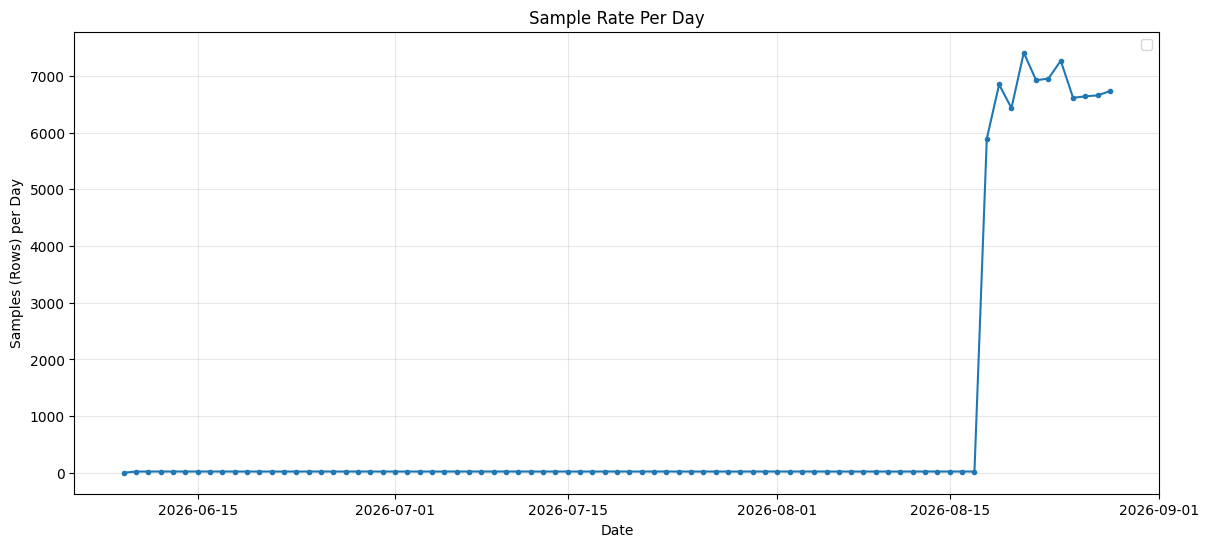

In [249]:
plt.figure(figsize=(14, 6))

plt.plot(
    counts.index,
    counts.values,
    marker="o",
    markersize=3
)

plt.xlabel("Date")
plt.ylabel("Samples (Rows) per Day")
plt.title("Sample Rate Per Day")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

As you can see, most of our days actually have a sample rate of around 24 samples per day. Later days had around 7,000 samples per day -- but with much more volatility. 

It climbed to 6,000 per day. Having a migration, update, or other type of infrastructural/architectural change mid-day could leave the initial sample improperly representing the true sample rate. However, on the next day, sample rate nearly reached 7,000 per day. It then dropped by about 500 samples per day to about 6,500, climed to about 7,500, dropped back to around 7,000, went back up to nearly 7,500, and finally dropped to a little over 6,500, where it stabilized and gradually increased. This shows that the system changes certainly made load less predictable than it initially was. And because our model will predict weather forecast data by discrete hourly units (e.g., 3 hours from now, 6 hours from now, etc.), one may assert that the increased complexity may not yield meaningful increases in performance, especially if it imposes an undue burden on data preparation that results in uncertain manupulation. But at the end of the day, *some* aspect of the pipeline was making the decision to select certain values. If Home Assistant captured data at the top of the hour, it chose a nominal, arbitrary method of sampling data that may not adequately reflect the environment. 

Consider an hour with wind speeds reaching 30 mph, but instantaneously experiencing a break at the top of the hour. The instantaneous reading does not reflect the impact that the wind had on the environment for that hour; meanwhile, an hour with readings that reach millisecond-precision for windspeeds could offer empirical representation opportunity that better reflects the environment. At the end of the day, additional data will help us make a more informed decision on how the period should be statistically represented. 

Unfortunately, having the opportunity to intelligently impute data for the late half of August is itself a bias, as the opportunity was not available from June to mid-August. As such, column-by-column inspection will be required so that we can ensure the trendline for each feature remains consistent throughout the collection period.

Before we continue, we will convert our columns to their respective datatypes as we'll need to perform certain operations with the data.

In [250]:
# UTC time stamp format, per our data
df["last_changed"] = pd.to_datetime(
    df["last_changed"],
    errors="coerce",
    utc=True
)

# numeric columns become numeric
numeric_cols = df.columns.drop("last_changed")

df[numeric_cols] = df[numeric_cols].apply(
    pd.to_numeric,
    errors="coerce"
)

##### Individual Feature Sample Rate: `graph_feature()`
For brevity in an increasingly labor-intensive project, we will make a function to make graphing more ergonomic as we inspect data. 

The function takes:

- `df`: a dataframe
- `col`: a column, that of which we will graph
- `scatter`: an optional boolean. If true, the function will plot a scatter plot; otherwise, graph a line graph.

We will also print some statistics regarding the data for reference. We will see the minimum, maximum, mean, median, missing count, and total observation count.

Viewing the scatter plot will allow us to visualize the data granularity, while the line graph will allow us to see the general shape of the trend. This will help us recognize whether increases in granularity/resolution lead to meaningful differences in trendline behavior, a possible indicator of temporal surveillance sampling bias.



In [251]:
def graph_feature(df, col, scatter=None):
    data = df[["last_changed", col]].copy()

    data["last_changed"] = pd.to_datetime(
        data["last_changed"],
        errors="coerce"
    )

    data[col] = pd.to_numeric(
        data[col],
        errors="coerce"
    )
    
    observed = data.dropna(subset=[col])

    print(f"Feature: {col}")
    print(f"Observations: {len(observed)}")
    print(f"Missing: {data[col].isna().sum()}")
    print(f"Min: {observed[col].min()}")
    print(f"Max: {observed[col].max()}")
    print(f"Mean: {observed[col].mean():.2f}")
    print(f"Median: {observed[col].median():.2f}")

    if (not scatter): 
        plt.figure(figsize=(14, 5))
        plt.plot(
            observed["last_changed"],
            observed[col],
            linewidth=1
        )
    else:
        plt.scatter(
            observed["last_changed"],
            observed[col],
            s=8,
            alpha=0.6
    )
    

    plt.xlabel("Time")
    plt.ylabel(col.replace("sensor.", ""))
    plt.title(col.replace("sensor.", ""))
    plt.grid(alpha=0.3)
    plt.show()

##### Individual Feature Sampling Rate: Temperature
Next, we will investigate temperature's trendline, sampling rate, and ensure sampling adjustments are executed appropriately.

Feature: sensor.acurite_atlas_178_temperature
Observations: 17012
Missing: 59030
Min: 56.2
Max: 101.01866096155555
Mean: 75.07
Median: 73.50


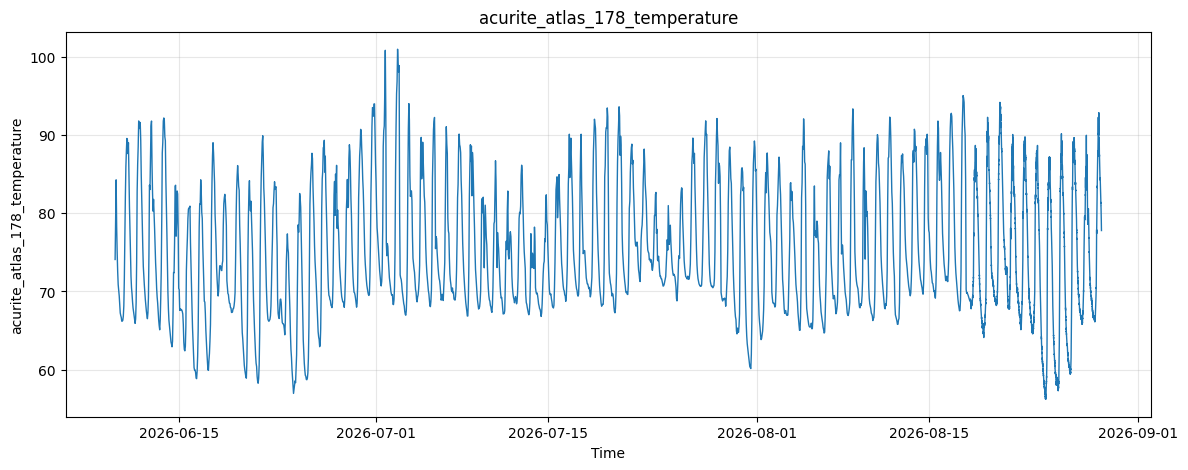

In [252]:
graph_feature(
    df,
    "sensor.acurite_atlas_178_temperature", scatter=False
)

As you can see, the trendline for temperature is quite cyclical as one would expect. We can see the daily periodicity, the transition of higher lows as we move from June into July (coinciding with record peaks as the transition occurs), and even a return to cooler nights as we approach the end of August. Fortunately, we see no major discontinuities in temperature reporting.

Above the graph, we can view the stats we printed with f-strings:
- **17,012 samples total**. This is considerable, but we know we'll have to downsample the sample-rich side of the timeseries. Nevertheless, **it should certainly clear our minimum requirement of 500 rows, which is fortunate because until this point, we weren't aware of the need to downsample.** In fact, with about 80 days of data, a fully imputed dataset should have around 1,920 rows, assuming 24 hours for each day. We know that we don't have 24 hours for each day, but we don't predict to lose 75% of the dataset for any reason.
- **59,030 missing samples**. That shows that in between each point we have, there are 59,030 adjacent moments where data was collected, but we had no sensor data for. Nevertheless, imputation should allow us to turn a cluster of adjacent snapshots into blended approximations that represent each individual moment (hour) in the best way possible.
- **minimum temperature of 56.2**. This appears to happen in the later samples as the weather gets cooler. 
- **maximum temperature of 101.02** No doubt as we entered the July heat.
- **average temperature of 75.07** with a **median temperature of 73.50**. Our average and median closely approximate eachother, though with slightly more bias towards lower temperatures as a result of our cooler June and late August nights. 

It is interesting to see that the later spikes in low temps are less pointed than the early ones. Instead of arrowhead-like points, many dips are more jagged in appearance, likely a result of the increased sample rate. We will address this.

Next, we can view its sampling rate.

Feature: sensor.acurite_atlas_178_temperature
Observations: 17012
Missing: 59030
Min: 56.2
Max: 101.01866096155555
Mean: 75.07
Median: 73.50


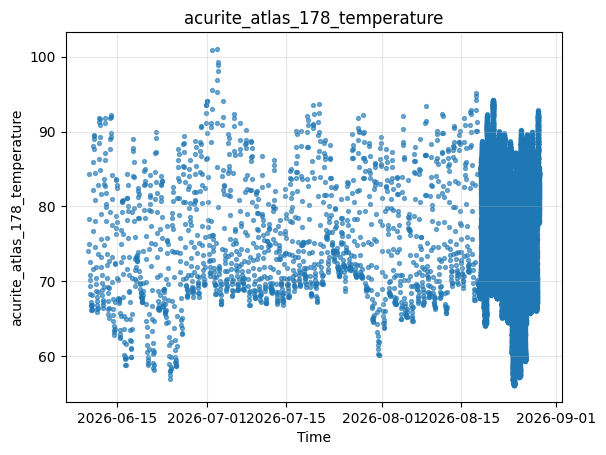

In [253]:
graph_feature(
    df,
    "sensor.acurite_atlas_178_temperature", scatter=True
)

Here, we can see the clear difference in sample rate. The later days are much more resolute in data, where the earlier days are intermittent. It also becomes clearer why we might have more modalities in evening dips in the later days as opposed to the earlier records.

So how should we fix this? As previously mentioned, my goal philosophically would be to minimize bias as a result of increased sampling. We've identified a segment of the observation population that was disproportionately abandoned in terms of survey. And while the earlier method -- which appeared to be surveying at the top of the hour -- wasn't ideal, it's still the way the system operated. Intelligent imputation on the later days would introduce less deterministic behavior, essentially creating a form of sensor drift by infrastructure enhancements. Therefore, since we can't increase the sample rate of the earlier data, but we can closely simulate the behavior of on-the-hour reporting in the later days, one could argue that imputation should be done by maintaining the behavior of the initial design, even if imperfect.

We can verify the top-of-the-hour reporting mechanism by finding the not null values for the timestamp and temperature column, finding those with dates less than (before) the date of sample rate increase, then print the minute and second value counts using `strftime` to format the datetime data.

In [254]:
temp_col = "sensor.acurite_atlas_178_temperature"

temp = df.loc[
    df[temp_col].notna(),
    ["last_changed", temp_col]
].copy()

temp["last_changed"] = pd.to_datetime(temp["last_changed"])

historical = temp[
    temp["last_changed"] < "2026-08-18"
]

print(
    historical["last_changed"]
    .dt.strftime("%M:%S")
    .value_counts()
    .head(20)
)


last_changed
00:00    1659
Name: count, dtype: int64


As you can see above, it appears that all 1,659 rows end in `00:00`, indicating top-of-the-hour reporting. With this in mind, we can downsample the rest of our data in the same way.

First, we take our `last_changed` timestamp index. we get the starting point using the `min()` function, and take the mathematical floor of the hour. 
We'll also generate an endpoint by taking the maximum of the time frame index using the `max()` function, and get its floor of the hour. This ensures that we don't attribute data to a future hour that we don't have data for.

We'll use the `date_range()` function of `pandas` to assign the date range to an index with a frequency of 1 hour, specify the UTC format, and assign that to `hourly_index`. 

In [255]:

temp = temp.sort_values("last_changed")

hourly_index = pd.date_range(
    start=temp["last_changed"].min().floor("h"),
    end=temp["last_changed"].max().floor("h"),
    freq="1h",
    tz="UTC"
)



Next, with our sorted dataframe, we will drop duplicates, set the index to be the time stamp, and use the temperature column (`temp_col`) to be the series value.

Next, we'll reindex the Series to find the nearest timestamp within a tolerance of 5 minutes. This maintains the original sampling method spiritually -- approximating the original temporal sampling rate method as opposed to finding empirical indicators. The downside is that if we have data missing within that 10 minute period of the hour, we lose the entire hour. Nevertheless, we will assess the impact of that when the moment arrives.

After reindex, we will plot our data using `graph_feature()` and observe the difference on a scatterplot again.

Feature: sensor.acurite_atlas_178_temperature
Observations: 1923
Missing: 1
Min: 56.2
Max: 101.01866096155555
Mean: 75.04
Median: 73.03


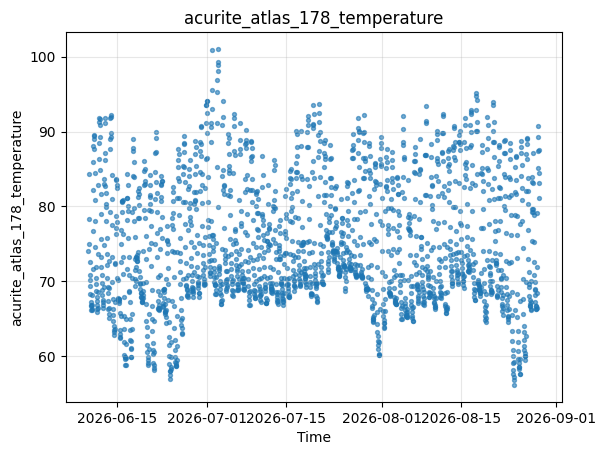

In [256]:
temp_series = (
    temp
    .drop_duplicates(subset="last_changed")
    .set_index("last_changed")[temp_col]
)

temp_hourly = temp_series.reindex(
    hourly_index,
    method="nearest",
    tolerance=pd.Timedelta("5min")
)

temp_hourly.index.name = "last_changed"

graph_feature(
    temp_hourly.reset_index(name=temp_col),
    temp_col,
    scatter=True
)

As you can see, we are now down to:
- **1923 observations**. This is fascinating. While this data preparation has been a massive undertaking, we have worked down nearly 400,000 datapoints to just under 2,000 with only 1 missing datapoint. With our bias-averse sampling approach, we've ensured responsible sampling conduct, with only 0.05% of the data dataset missing data. Unfortunately, as we mentioned earlier, a single datapoint is still an hour's worth of data. It would throw off the rhythmic pattern of the environment, so we still need to impute it. Nevertheless, imputing a single datapoint is much more preferable when compared to changing the calculation method across weeks worth of data. This imputation is statistically insignificant by conventional standards.
- **1 missing datapoint**. As we mentioned, a single `NaN` is present. We will deal with this shortly. 
- **The same empirical min, max, mean, and median as before.** We've verified that we have maintained the empirical distribution of our data using our method of downsampling, which is fantastic news.

We can now add `temp_hourly` to a new dataframe. We'll use this dataframe going forward so we can keep our previous `df` dataframe intact in case we need to reference it.

In [257]:
df_hourly = temp_hourly.to_frame(name=temp_col)

df_hourly.head(5)

,sensor.acurite_atlas_178_temperature
last_changed,
2026-06-09 20:00:00+00:00,74.094584
2026-06-09 21:00:00+00:00,NaN
2026-06-09 22:00:00+00:00,84.291365
2026-06-09 23:00:00+00:00,78.380334
2026-06-10 00:00:00+00:00,75.009982


##### Individual Feature Sampling Rate: Other Features
While we deep-dove into temperature, we can (hopefully) avoid similar rabbit holes moving forward. We have data from two sources -- the AcuRite weather station, and the WH51 soil moisture sensor. Since we've established that we have an hourly sample rate, we can downsample other columns by the same logic.

Before we continue, we'll make a reusable function to downsample our columns. It takes a dataframe, a column to downsample, and the default tolerance value is 5 minutes, as we used for temperature. Using the same logic we used earlier, we now have a portable method to quickly and concisely quantize our data.

In [258]:
def downsample_hourly(df, col, tolerance="5min"):
    data = (
        df[["last_changed", col]]
        .dropna(subset=[col])
        .sort_values("last_changed")
        .drop_duplicates(subset="last_changed")
        .set_index("last_changed")[col]
    )

    hourly_index = pd.date_range(
        start=df["last_changed"].min().floor("h"),
        end=df["last_changed"].max().floor("h"),
        freq="1h",
        tz="UTC"
    )

    return data.reindex(
        hourly_index,
        method="nearest",
        tolerance=pd.Timedelta(tolerance)
    )

Next, we can iterate through our columns in `df`, fitting them to our quantized timeseries index, and applying the reindex results from `downsample_hourly()` to the column.

In [259]:
model_cols = [col for col in df.columns if col != "last_changed"]

df_hourly = pd.DataFrame(index=pd.date_range(
    start=df["last_changed"].min().floor("h"),
    end=df["last_changed"].max().floor("h"),
    freq="1h",
    tz="UTC"
))

for col in model_cols:
    df_hourly[col] = downsample_hourly(df, col)

df_hourly.index.name = "last_changed"

Now, we have a standardized sample rate with each feature quantized and approximated using our standard methodology, which was an educated inference of the methodology used by the system in the earlier months. With this, we should have greatly reduced the sampling bias that occurred as a result of the infrastuctural changes in the system. Our datset no longer has severely biased concentration around late August, the sampling cadence is consistent, and the datapoints that we believe most accurately represent the next observation are chosen. As a result, our dataset has likely tremendously changed in shape.

In [260]:
df_hourly.shape

(1924, 8)

As you can see, our dataset is now down to **8 columns, an hourly timeseries index, and 1924 rows.** That is tremendously refined from the 112 columns and 400,000-something rows that we started out with.

In [261]:
df_hourly.head(6)

,sensor.acurite_atlas_178_dew_point,sensor.acurite_atlas_178_humidity,sensor.acurite_atlas_178_light_level,sensor.acurite_atlas_178_rain_total,sensor.acurite_atlas_178_temperature,sensor.acurite_atlas_178_wind_direction,sensor.acurite_atlas_178_wind_speed,sensor.fineoffset_wh51_0f8613_soil_moisture
last_changed,,,,,,,,
2026-06-09 20:00:00+00:00,72.299987,94.018017,34256.883479,5.08,74.094584,225.714574,0.963634,62.000000
2026-06-09 21:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-09 22:00:00+00:00,73.202661,69.452063,54935.419482,5.08,84.291365,130.609755,0.392840,62.000000
2026-06-09 23:00:00+00:00,72.277020,81.716090,9082.813943,NaN,78.380334,335.906059,0.330729,NaN
2026-06-10 00:00:00+00:00,71.410234,88.611213,4342.566095,NaN,75.009982,0.242963,0.256871,NaN
2026-06-10 01:00:00+00:00,71.301074,95.811685,726.052217,0.00,72.564633,1.686804,0.004167,62.150025


Next, we can look at the null counts for each column after our downsampling.

In [262]:
df_hourly.isna().sum().sort_values(ascending=False)

sensor.acurite_atlas_178_rain_total            1740
sensor.fineoffset_wh51_0f8613_soil_moisture    1192
sensor.acurite_atlas_178_humidity               623
sensor.acurite_atlas_178_wind_speed             590
sensor.acurite_atlas_178_light_level            541
sensor.acurite_atlas_178_wind_direction           4
sensor.acurite_atlas_178_dew_point                1
sensor.acurite_atlas_178_temperature              1
dtype: int64

As you can see, some observations can be made.

- **Temperature, dew point, and wind direcation are beautifully addressed by downsampling.** These sensors appear to report more frequently, resulting in little to no `NaN` values after 5-minute tolerance downsampling to the hour. They nearly always had a value available within 5 minutes of either side of the hour marker.

- **Humidity, wind speed, and light level have more gaps.** This shows that they were likely more sporadic in reporting. Resolution may be relatively weak compared to the previous columns. Interestingly, with dew point and temperature being reported more frequently, relative humidity could actually be derived from this relationship. While that's not scientific humidity sensor-level of quality, it is certainly valuable. The model could likely interpret the relationship with temperature and dew point readily available. Direct air humidity readings from a sensor will still provide valuable certainty, though less frequently.

- **Soil moisture -- our target variable -- and rain total are missing considerably more data.** This shows that our target variable doesn't necessarily have the highest resolution. Rain total also seems to update less frequently; however, being of cumulative nature, frequent updates and instantaneous values aren't necessarily a requirement. Rain falls unevely, and effects in the environment from the rain take time to show. 

Nevertheless, while it may appear concerning, intermittent reporting isn't necessarily bad. We still have frequent data spanning the entire timeseries range for each sensor. If a sensor reports every two hours, that's still valuable information and relatively resolute. We can forward fill data to smooth the trend lines where appropriate, and handle other columns appropriately.

To visualize this, we'll create a condensed grid of scatter plots to visualize each reading. This will show the resolution and reporting rate of each sensor. The visual representation conveys a tangible trendline that allows us to see that even low-resolution sensors have a coherent posture, and rough approximation is reasonable given the shape of the data.

Most importantly, you'll see that we have removed blatant sample bias that occurred in the dataset earlier, and reporting is now more equitable across time.

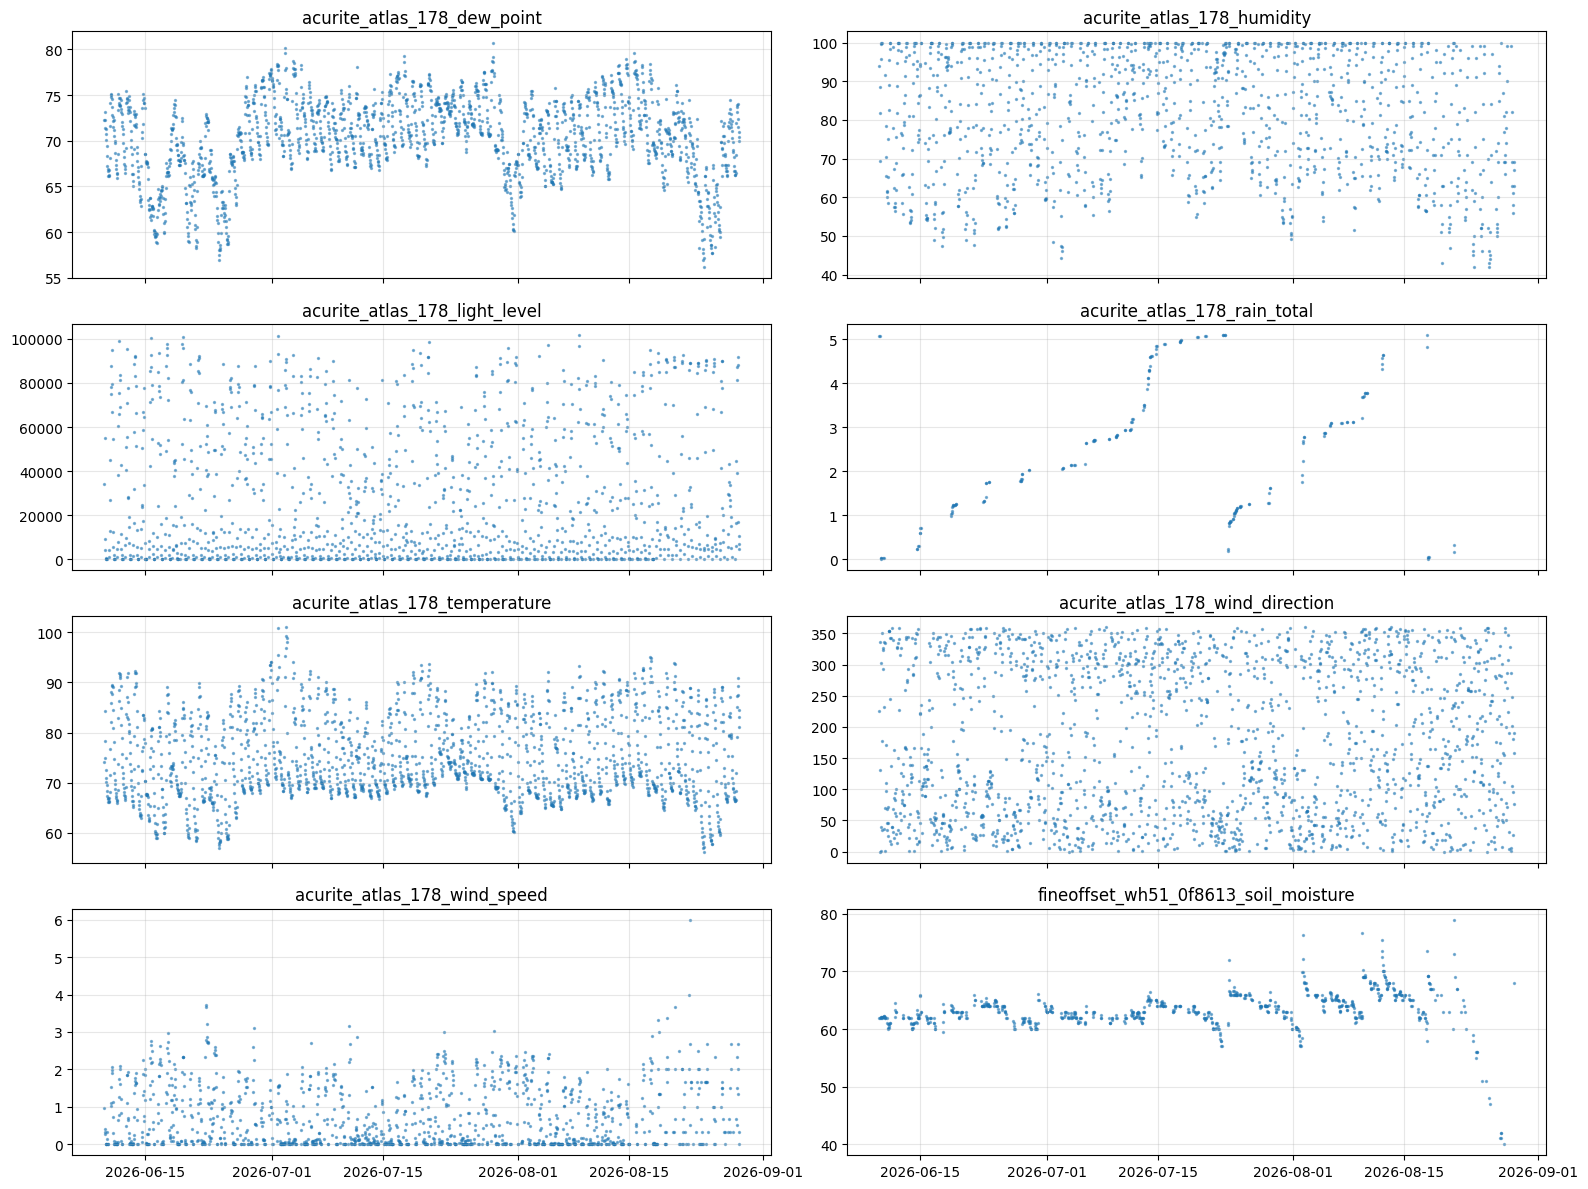

In [263]:
cols = df_hourly.columns

fig, axes = plt.subplots(
    nrows=(len(cols) + 1) // 2,
    ncols=2,
    figsize=(16, 12),
    sharex=True
)

axes = axes.flatten()

for ax, col in zip(axes, cols):
    ax.scatter(
        df_hourly.index,
        df_hourly[col],
        s=2,
        alpha=0.5
    )
    
    ax.set_title(col.replace("sensor.", ""))
    ax.grid(alpha=0.3)

for ax in axes[len(cols):]:
    ax.remove()

plt.tight_layout()
plt.show()

At this point, we can see that:
- **The silhouette of each trendline is noticeable.** We have complete timeframes of scientifically measured data, sampling bias has been neutralized, and there's no obvious cause for concern among features or our target.
- **We can also see that rain total events appear to closely align with soil moisture changes.** As rain total increases dramatically, soil moisture begins to have higher spikes. While **we don't have manual watering measured or recorded**, this is reassuring as some variable interactions are visually present in the data. We also see some interactions potentially with air humidity and soil moisture, but temperature appears to have the largest alignment of events. Early June disruptions in teperature align with jitter in humidity. While there's no clear linear indicator, it is apparent that **disturbances in each variable seem to coincide with one another.** Regions of consistently low temperatures appear to coincide with regions of potentially elevated soil moisture. Early June seems to hold more frequent lows, while soil moisture stayed relatively stable. Late August had more concentration of low points -- more closely condensed datapoints -- which appeared to coincide with more erratic changes in soil moisture. This is likely caused by the higher concentration of high temperatures in late August, showing a contrast of high frequency in the low temps, yet frequent presence around the 90 degrees F range, likely contributing to the erratic behavior of soil moisture. Late August also appeared to hold more presence in the 80,000 to 100,000 lux range, likely contributing to the rapid destabilization of the soil. This shows how even seemingly less noticeable changes in weather can dramatically destabilize ecological environments.

Next, we will save our `df_hourly` dataframe in the same manner that we archived our `df` dataframe. This is just in case we need to reference it at a later time.

In [264]:
df_hourly_raw = df_hourly.copy()

Finally, we'll forward fill our data to smooth the gaps. While it may not be ideal, it maintains the sampling rate of the equipment, ensuring state changes occur over time evenly. This is critical in avoiding sampling bias in timeseries experiments. 

In [265]:
df_hourly = df_hourly.ffill()

For validation, we'll observe how it impacted our data using scatter plots again.

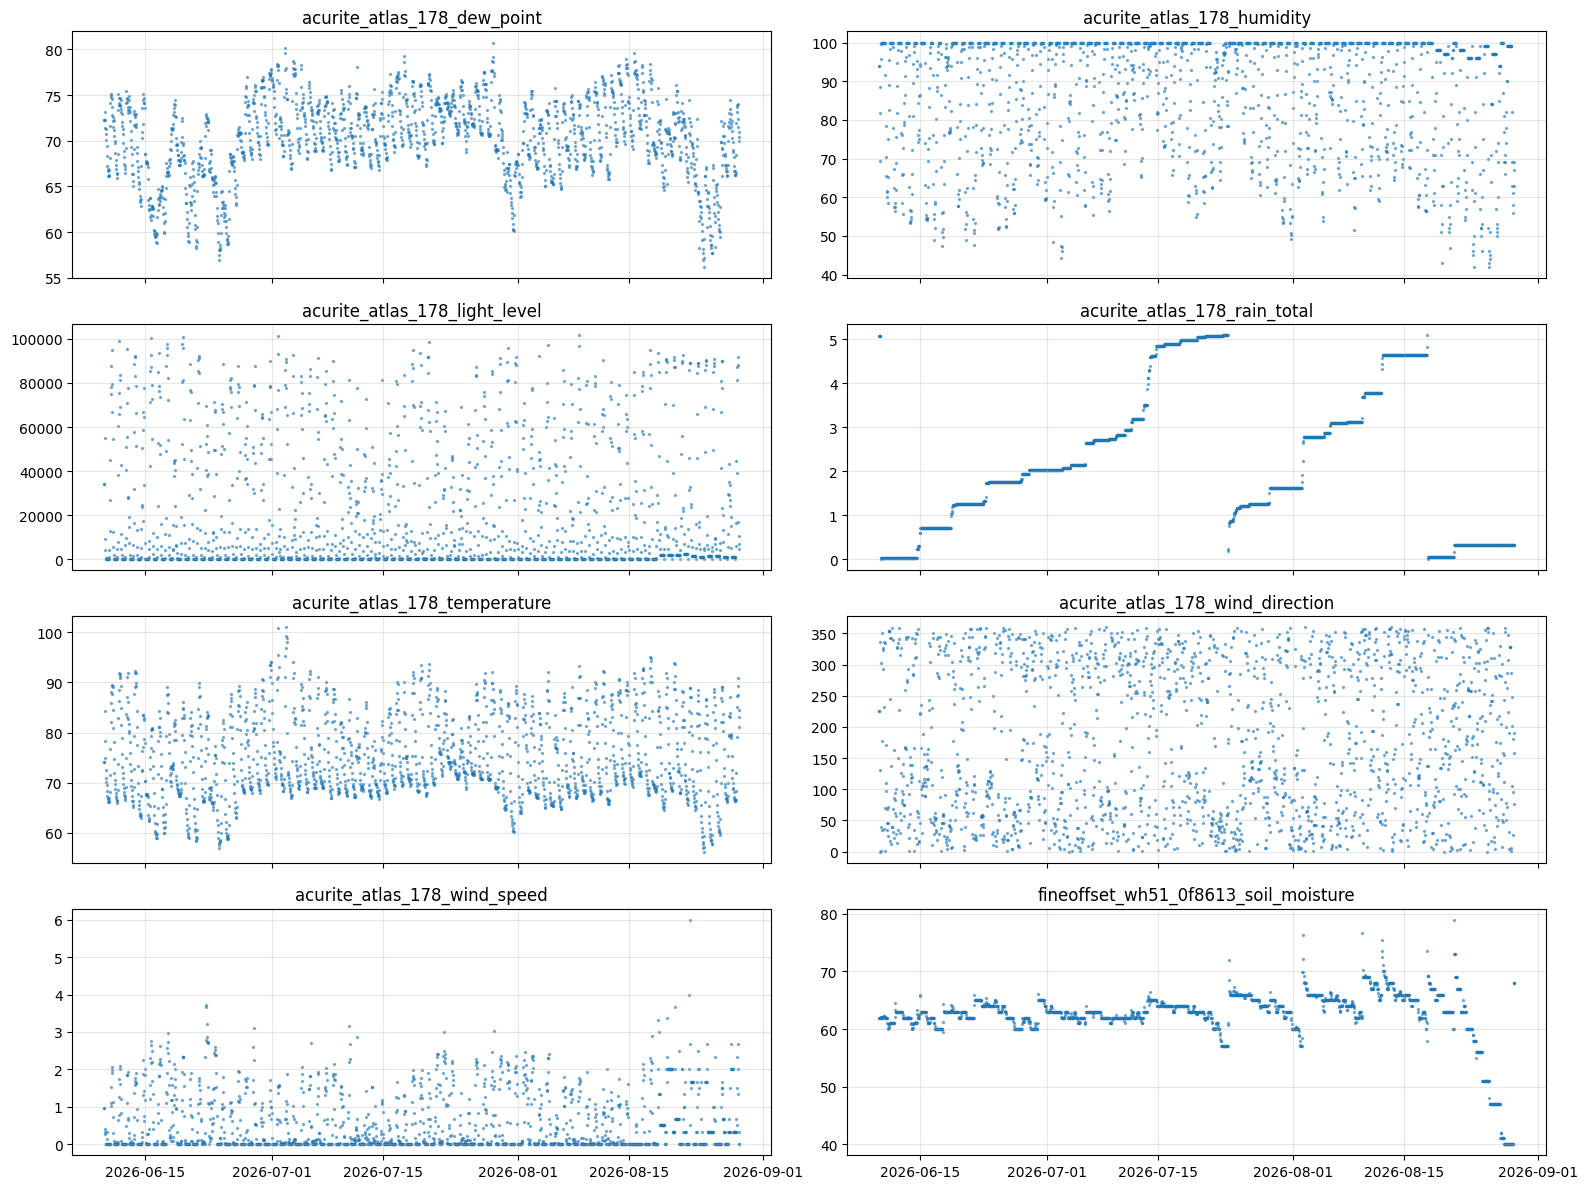

In [266]:
cols = df_hourly.columns

fig, axes = plt.subplots(
    nrows=(len(cols) + 1) // 2,
    ncols=2,
    figsize=(16, 12),
    sharex=True
)

axes = axes.flatten()

for ax, col in zip(axes, cols):
    ax.scatter(
        df_hourly.index,
        df_hourly[col],
        s=2,
        alpha=0.5
    )
    
    ax.set_title(col.replace("sensor.", ""))
    ax.grid(alpha=0.3)

for ax in axes[len(cols):]:
    ax.remove()

plt.tight_layout()
plt.show()

This shows what we'd expect, and ultimately what we'd want. 

**Observe soil moisture, our target.** We can see that the general trendline that the sensor created is maintained. It may visually appear more like a quantized square wave -- a natural effect seen in cyclical sampling. The data implies that until the state is changed by the sensor, we are to generally assume that the last value is the current value. That's an assumption that must be made with RF/broadcast/non-TCP data pipelines. Noise can happen, interference can happen, there's no protocol for ensuring the message is received, and sample rate limits certainty.

Nevertheless, we've refined our data responsibly and, as we've said, can only be as certain as the sample rate of our equipment. Forward filling some data after careful restructuring to eliminate bias remains a defensible decision, as we are not implying certainty past that given to us by our equipment. Ultimately, a prediction model should be attuned to the nature of the sensors, and therefore we forward-fill to preserve their level of certainty and tendencies.

And just to verify:

In [267]:
df_hourly.isna().sum()

sensor.acurite_atlas_178_dew_point             0
sensor.acurite_atlas_178_humidity              0
sensor.acurite_atlas_178_light_level           0
sensor.acurite_atlas_178_rain_total            0
sensor.acurite_atlas_178_temperature           0
sensor.acurite_atlas_178_wind_direction        0
sensor.acurite_atlas_178_wind_speed            0
sensor.fineoffset_wh51_0f8613_soil_moisture    0
dtype: int64

We now have no `NaN` or `NaT` values in our dataset.

## Phase 4: Decisions With Contiguous Data
Now that we've cleaned, imputed, forward-filled, quantized, downsampled, and shaped our data, we can begin making decisions with candidate features and how to structure them for model ingestion. We no longer have uncertainty regarding the data quality, integrity, or completion. With that in mind, we can invest effort into formatting data in a way that the model can understand and use effectively.

### Converting Cumulative Rain Total to Hourly Rain Total
In the spirit of our timeseries problem, we will convert our cumulative rainfall total -- a counter that resets at some device/manufacturer-specific increment -- to an hourly rainfall column. Not only will this better represent the immediate environment at the point of inference, but it also makes it easier to use with our LLM. Instead of calculating the current total and adding an estimated amount of rainfall to it, we can simply say something like, "If it rains 2 inches in the next 3 hours...". This makes it more ergonomic, more adaptable to real-world API outputs, and more sensical in the representation of periodic timeseries environmental data. 

First, we'll take a look at our actual problem (using our `graph_feature()` function we made earlier). 

As you can see, The rain total column appears to reset every time the value hits 5.1 (as you can see in the max printed below). As a result, the data needs to be processed to better represent the actual value, as a rolling value would not represent rainfall as an environmental state, especially as we've forward-filled it.

Feature: sensor.acurite_atlas_178_rain_total
Observations: 1924
Missing: 0
Min: 0.0
Max: 5.1
Mean: 2.25
Median: 2.02


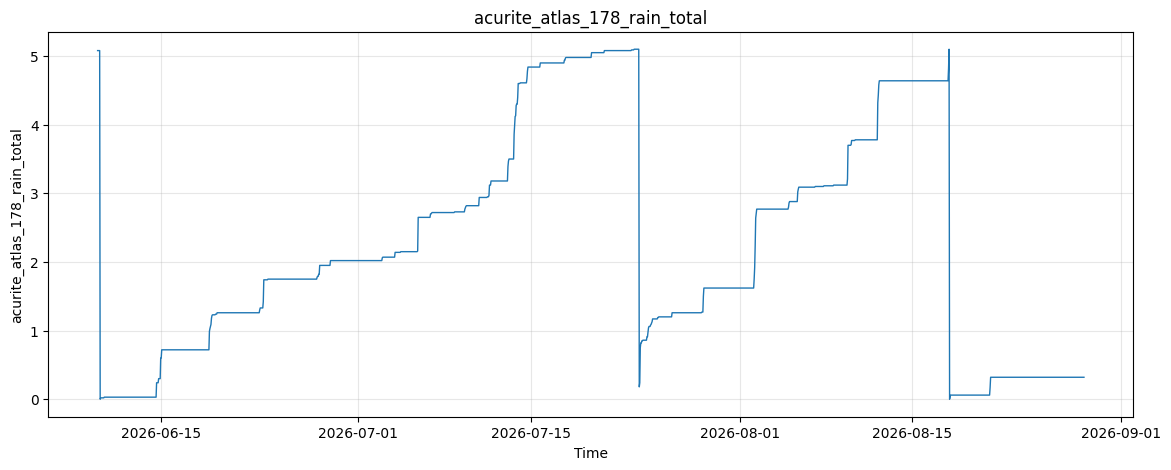

In [268]:
graph_feature(
    df_hourly.reset_index(),
    'sensor.acurite_atlas_178_rain_total'
)

To solve this problem, we simply need to obtain the change in rainfall for each hour. The rainfall change will be:
- *the rainfall for this hour* - *the rainfall of the previous hour* = **hourly rainfall**

If the value is the same between two hours, the value is 0. If the value slightly increases between two hours, that's how much it rained during that hour.

This does result in a single `NaN` value; the first, zero-index rainfall value, which had no previous value to subtract from it. In this case, we will use `fillna()` to fill the `NaN` value with 0, as we have no functional basis for proving that it rained that hour, and how much it could have rained over the given undocumented period.

We will graph the new feature to show what our cumulative rainfall counter looks like as a quantitative temporal rainfall sensor.

Feature: rain_hourly
Observations: 1924
Missing: 0
Min: 0.0
Max: 0.5400000000000005
Mean: 0.01
Median: 0.00


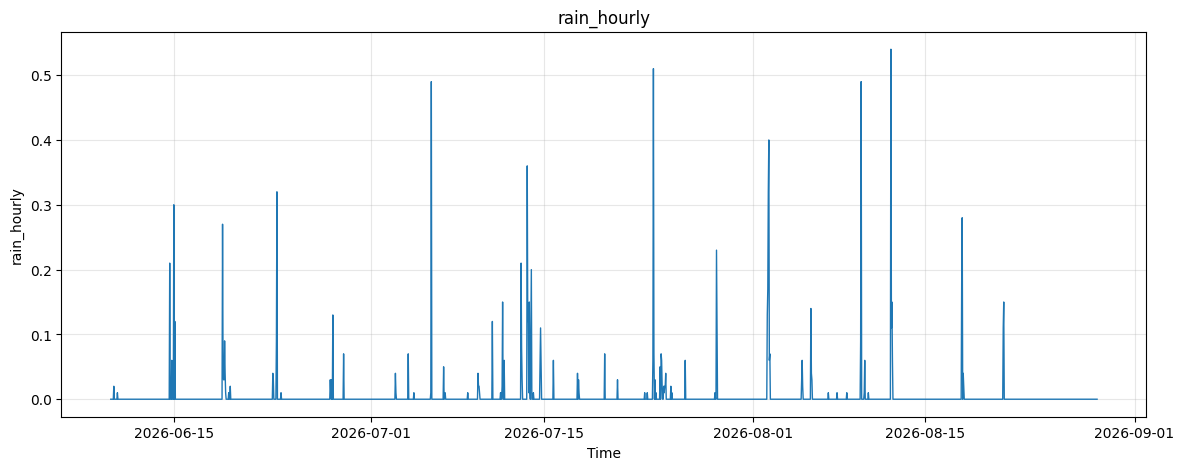

In [269]:
rain_col = "sensor.acurite_atlas_178_rain_total"

df_hourly["rain_hourly"] = df_hourly[rain_col].diff()

df_hourly.loc[df_hourly["rain_hourly"] < 0, "rain_hourly"] = 0

df_hourly["rain_hourly"] = df_hourly["rain_hourly"].fillna(0)
df_hourly["rain_hourly"].describe()
df_hourly["rain_hourly"].nlargest(10)
graph_feature(
    df_hourly.reset_index(),
    "rain_hourly"
)

As you can see, this pretty simply solved the issue. Just subtracting the previous value from the current value converted a long-horizon counter into a high-resolution quantitative delta sensor.

### Converting Wind Degrees to Radians, Feature Engineering Cosine, Sine
Next, we'll tackle converting wind degrees to radians. As you know, wind direction is measured in degrees, which ranges from 0-359 degrees. 359 and 0 degrees are nearly identical in position, yet the model would recognize this as two very different values, when in reality that slight nudge to the wrong side of a precise boundary is not as severe as the degrees representation may appear.

So the question becomes, what would describe it best? Radians is often used to represent orbital or angular motion. And from radians, we can get **sine** and **cosine** using their respective `NumPy` functions. Sine and Cosine will give us the Y-axis and X-axis value corresponding to the radian (and therefore wind degree) at that point in time, giving us rich data representing the displacement of air in both a horizontal and vertical dimension. at any given point in time.

In [270]:
wind_col = "sensor.acurite_atlas_178_wind_direction"

radians = np.deg2rad(df_hourly[wind_col])

df_hourly["wind_dir_sin"] = np.sin(radians)
df_hourly["wind_dir_cos"] = np.cos(radians)

df_hourly.drop(columns=[wind_col], inplace=True)

Now that we have Sine and Cosine engineered, we can observe how they look graphed. 

Because their values are between -1 and 1, we will limit the y-axis to that range.

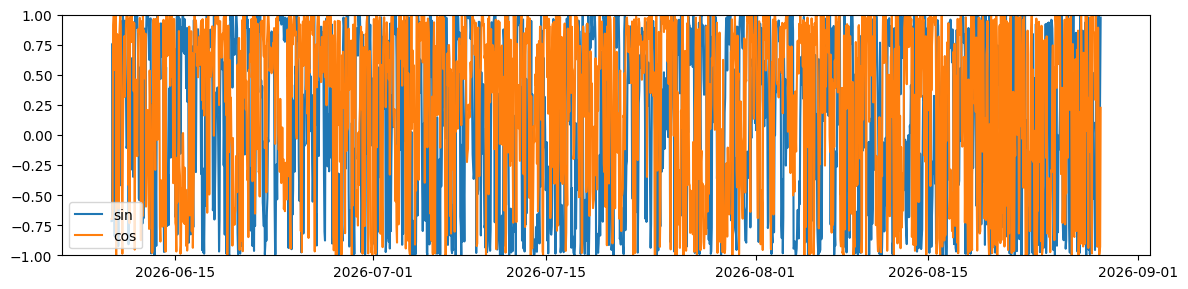

In [277]:
plt.figure(figsize=(12, 3))
plt.plot(df_hourly.index, df_hourly["wind_dir_sin"], label="sin")
plt.plot(df_hourly.index, df_hourly["wind_dir_cos"], label="cos")
plt.ylim(-1.0, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

As a result, we now have engineered -- from a nominal, arbitrary degree value -- the X and Y-axis displacement of the air. 

We'll verify that we have no null values and continue. 

In [273]:
df_hourly.isna().sum()

sensor.acurite_atlas_178_dew_point             0
sensor.acurite_atlas_178_humidity              0
sensor.acurite_atlas_178_light_level           0
sensor.acurite_atlas_178_rain_total            0
sensor.acurite_atlas_178_temperature           0
sensor.acurite_atlas_178_wind_speed            0
sensor.fineoffset_wh51_0f8613_soil_moisture    0
rain_hourly                                    0
wind_dir_sin                                   0
wind_dir_cos                                   0
dtype: int64

### Forecasting the Target Variable
In a timeseries experiment, prediction is shaped by the **prediction horizon** -- simply put, the distance of time from the **prediction origin** (the moment of inference) in which a target variable will be predicted. For this project, a **short-horizon prediction** might be 1 to 3 hours in the future. But as we've seen, the soil moisture sensor itself didn't always provide an update/state change hourly. 

To assess our **prediction horizon**, we can look at our data and see what might be reasonable. Too short of a horizon and no major feat has been accomplished, and too long of a horizon and the current feature data has relatively little causal impact to the predicted value (y-hat).

Feature: sensor.fineoffset_wh51_0f8613_soil_moisture
Observations: 264
Missing: 0
Min: 57.0
Max: 71.96655473968056
Mean: 63.12
Median: 64.00


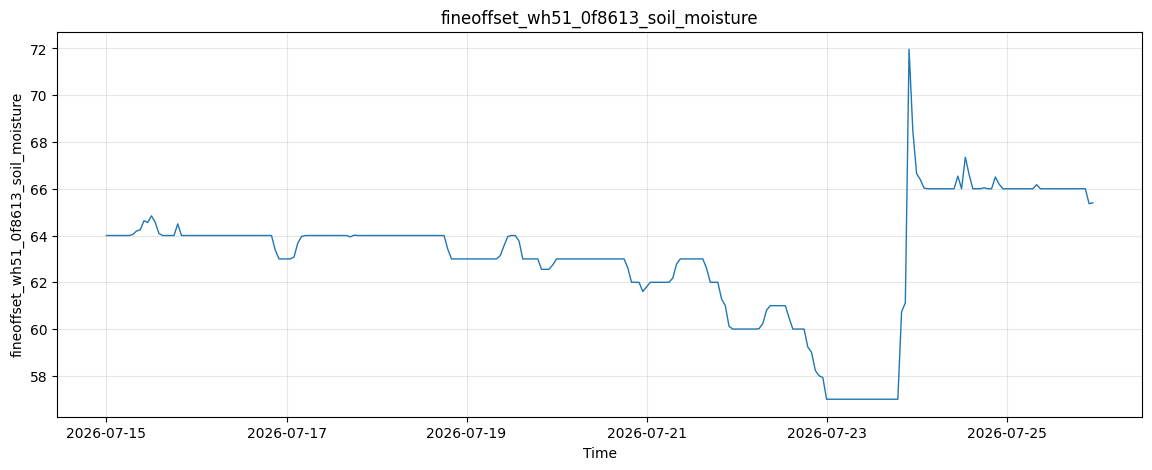

In [297]:
zoom = df_hourly.loc["2026-07-15":"2026-07-25"]

graph_feature(
    zoom.reset_index(),
    "sensor.fineoffset_wh51_0f8613_soil_moisture"
)

As you can see, we have 10 days worth of data. Each vertical grid line represents two days. 

- **07-15 to 07-17** We can see that the value stays relatively unchanged for the first 4 days, despite minor disruptions and fluctuations. This is where our atmospheric data will be of use -- what may cause these fluctuations, and can they foreshadow soil moisture inclinations in the coming days?
- **07-17 to 07-19** Similarly, the soil moisture has a prominent floor around 64% soil moisture. Minor disruptions and fluctuations occur, yet this marks 4 days of consistent behavior.
- **07-19 to 07-21** What appeared to be another fluctuation that mirrored the previous dip turned out to be a new floor for the trendline. Despite briefly returning to its 64% value, the moisture level dropped back down to 63%. The width of the dip may have been an indicator that a return to 64% was unsustainable. 63% is largely held, with a minor dip leading into further decline at the end of the period.
- **07-21 to 07-23** Like a stock chart ripping downwards, brief spikes of rallying result in further descent as moisture tumbles. 
- **07-23 to 07-25** A watering event occurs that ultimately buys soil moisture another round of life support. Positive spikes indicate environmental support, yet the marker moves forward and trends with downward motion again.

Clearly we've made some assumptions in this, but the activity of the trendline is real. We can see that two-day periods can hold steady, and we've also seen that they can have tremendous upheaval, resulting in new floor positioning as equilibrium is achieved. But what's clear after analyzing these two-day segments is that a 1, 3, 6, 9, or even 12-hour prediction horizon may not truly test the model's understanding. Outside of the obvious watering event, the most intense natural decline that resulted in a new floor appeared to happen over a period of 24 hours (two occurring between 07-21 and 07-23).

As such, a 24-hour prediction horizon seems like a rational starting point. While it may at times achieve success simply by estimating no change, it is apparent that 24-hour prediction can be tested as natural forces influence the soil moisture. Additionally, 24-hour prediction stands to be a sensical feature from a product perspective. It gives ample time for a user to act or a model to continue observing data. It comfortably enables pre-emptive measures to prevent soil dehydration without attempting to "predict the future" beyond what would make sense.

Next, we'll create the target variable of `target_soil_moisture_24h` by shifting the data by 24 hours. 

> We will also make a new `df_model` for model development, archiving our place in case we need to reference data.

In [300]:
soil_col = "sensor.fineoffset_wh51_0f8613_soil_moisture"
df_model = df_hourly.copy()

df_model["target_soil_moisture_24h"] = (
    df_model[soil_col].shift(-24)
)

As you might expect, this results in 24 rows of our hourly sample rate timeseries data to become `NaN` values. As a result, we can drop these for model use.

In [302]:
df_model = df_model.dropna(
    subset=["target_soil_moisture_24h"]
)

We can preview our data by viewing the head of our new `df_model` DataFrame:

In [303]:
df_model[
    [soil_col, "target_soil_moisture_24h"]
].head()

,sensor.fineoffset_wh51_0f8613_soil_moisture,target_soil_moisture_24h
last_changed,,
2026-06-09 20:00:00+00:00,62.0,61.835305
2026-06-09 21:00:00+00:00,62.0,61.016679
2026-06-09 22:00:00+00:00,62.0,60.891574
2026-06-09 23:00:00+00:00,62.0,60.202383
2026-06-10 00:00:00+00:00,62.0,60.072445


This offers reasonable reassurance. Theoretically, a 1-2% difference in soil moisture can be due to rain, high UV intensity, humidity, winds, or other environmental data in the previous days. If we've given the model enough quality data, it may learn these relationships, perform well in inference, and even allow us to observe environmental impact on soil health. If performance is adequate, it would be interesting to run ablation tests or view feature importances to verify major contributing factors to soil health. 

As a result, our `df_model` DataFrame should gain a target column and lose exactly 24 rows.

In [304]:
print(df_hourly.shape)
print(df_model.shape)

(1924, 10)
(1900, 11)
